In [5]:
%pip install -r ../requirements.txt

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached error_grids-0.1.0-py3-none-any.whl.metadata (486 bytes)
  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections


## Data processing:

In [13]:
"""
Blood Glucose Forecasting Data Processing
Trains on OhioT1DM, tests on BrisT1D with shared features only
No data leakage: scalers fitted only on training data
Fixed: Smoother only applied to CGM data
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import sys
import subprocess
import os

from PyKalmanSmoothingGlucose.smoother.smooth_SMBG_data import smooth_smbg_data

# ============================================================================
# CONFIGURATION
# ============================================================================

# Paths
TRAIN_PATH = "../data/OhioT1DM.csv"
TEST_PATH = "../data/BrisT1D.csv"

# Parameters
N_OUT = 6  # 30-min horizon (6 × 5min)
N_IN = N_OUT * 2  # 60-min history (12 × 5min)
RESAMPLE_RULE = '5T'  # 5-minute intervals
RANDOM_STATE = 42

# SHARED FEATURES ONLY (intersection of both datasets)
# Base features: present in both datasets
SHARED_FEATURES = ['carbs', 'bolus', 'heartrate', 'steps']

# Computed features: derivatives (can be computed from both datasets)
COMPUTED_FEATURES = ['CGM_derivative']

# All features for model input
MODEL_FEATURES = SHARED_FEATURES + COMPUTED_FEATURES

print(f"Base shared features: {SHARED_FEATURES}")
print(f"Computed features: {COMPUTED_FEATURES}")
print(f"Total model features: {MODEL_FEATURES}")
print(f"History: {N_IN}x5min = {N_IN*5}min")
print(f"Horizon: {N_OUT}x5min = {N_OUT*5}min\n")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def smooth_with_kalman(dates, values, subject_id):
    """
    Apply Kalman smoothing with fallback to interpolation+median filter
    Returns: pandas Series with smoothed values at original timestamps
    NOTE: This should ONLY be used for CGM data
    """
    try:
        result = smooth_smbg_data(dates, values, outlier_removal=1, dynamic_model=2)
        y_smooth = result.get('y_smoothed_at_tout', result.get('y_smoothed', None))
        tout = result.get('tout', None)
        
        if y_smooth is not None:
            idx = pd.to_datetime(tout) if tout is not None else pd.to_datetime(dates)
            return pd.Series(y_smooth, index=idx)
        else:
            raise ValueError("No smoothed output")
            
    except Exception as e:
        print(f"  [Kalman failed for subject {subject_id}] Using fallback: {e}")
        # Fallback: interpolation + median filter
        s = pd.Series(values, index=pd.to_datetime(dates))
        s = s.interpolate(method='time')
        s = s.rolling(window=3, min_periods=1, center=True).median()
        return s


def process_subject(df_subject):
    """
    Process a single subject's data:
    1. Create regular 5-min grid
    2. Smooth CGM with Kalman filter (CGM ONLY)
    3. Interpolate all other features to grid
    4. Return DataFrame with all features at regular intervals
    """
    subject_id = df_subject['id'].iloc[0]
    
    # Create regular time grid
    t_min = df_subject['date'].min().floor('5T')
    t_max = df_subject['date'].max().ceil('5T')
    grid = pd.date_range(t_min, t_max, freq=RESAMPLE_RULE)
    
    # Smooth CGM ONLY (not carbs or other features)
    cgm_smooth = smooth_with_kalman(
        df_subject['date'].values,
        df_subject['CGM'].values,
        subject_id
    )
    
    # Reindex CGM to regular grid
    cgm_reg = cgm_smooth.reindex(cgm_smooth.index.union(grid)).sort_index()
    cgm_reg = cgm_reg.interpolate(method='time').reindex(grid)
    cgm_reg = cgm_reg.fillna(method='ffill').fillna(method='bfill')
    cgm_reg = cgm_reg.fillna(cgm_smooth.median())
    
    # Process ALL other features (including carbs) with simple interpolation
    df_idx = df_subject.set_index('date')
    features_df = df_idx.reindex(df_idx.index.union(grid))[SHARED_FEATURES].sort_index()
    features_df = features_df.interpolate(method='time').reindex(grid)
    features_df = features_df.fillna(method='ffill').fillna(method='bfill').fillna(0)
    
    # Assemble output
    output = pd.DataFrame(index=grid)
    output['CGM_smoothed'] = cgm_reg.values
    for col in SHARED_FEATURES:
        output[col] = features_df[col].values
    
    # Compute derivatives (shared computed features for both datasets)
    output['CGM_derivative'] = output['CGM_smoothed'].diff().fillna(0)
    
    output = output.reset_index().rename(columns={'index': 'date'})
    return output


def create_sequences(df_subject, n_in, n_out, cgm_scaler, feature_scaler):
    """
    Create input-output sequences from processed subject data
    Returns: X (n_samples, n_in, n_features+1), y (n_samples, n_out, 1)
    Features include: base shared features + computed derivatives
    """
    cgm = df_subject['CGM_smoothed'].values.reshape(-1, 1)
    features = df_subject[MODEL_FEATURES].values  # Includes derivatives
    
    # Scale using provided scalers
    cgm_scaled = cgm_scaler.transform(cgm).flatten()
    features_scaled = feature_scaler.transform(features)
    
    X_list, y_list = [], []
    L = len(df_subject)
    
    for i in range(n_in, L - n_out + 1):
        # Input: combine scaled CGM with scaled features (including derivatives)
        x_in = np.column_stack([
            cgm_scaled[i-n_in:i],
            features_scaled[i-n_in:i]
        ])
        # Output: future CGM values
        y_out = cgm_scaled[i:i+n_out].reshape(n_out, 1)
        
        X_list.append(x_in)
        y_list.append(y_out)
    
    if len(X_list) == 0:
        return np.zeros((0, n_in, 1+len(MODEL_FEATURES))), np.zeros((0, n_out, 1))
    
    return np.stack(X_list), np.stack(y_list)


# ============================================================================
# STEP 1: LOAD AND PROCESS TRAINING DATA (OhioT1DM)
# ============================================================================

print("="*70)
print("STEP 1: Processing Training Data (OhioT1DM)")
print("="*70)

df_train = pd.read_csv(TRAIN_PATH)
df_train['date'] = pd.to_datetime(df_train['date'])
df_train = df_train.sort_values(['id', 'date']).reset_index(drop=True)

# Rename columns to match shared feature names
if 'insulin' in df_train.columns:
    df_train = df_train.rename(columns={'insulin': 'bolus'})

# Process each subject
print("\nProcessing training subjects...")
train_subjects = {}
for subject_id, group in df_train.groupby('id'):
    print(f"  Processing subject {subject_id}...")
    train_subjects[subject_id] = process_subject(group)

# Split subjects into train/validation (80/20) BEFORE fitting scalers
subject_ids = sorted(train_subjects.keys())
train_ids, val_ids = train_test_split(
    subject_ids, 
    test_size=0.2, 
    random_state=RANDOM_STATE
)

print(f"\nSubject split:")
print(f"  Total: {len(subject_ids)}")
print(f"  Train: {len(train_ids)}")
print(f"  Validation: {len(val_ids)}")


# ============================================================================
# STEP 2: FIT SCALERS ON TRAINING SUBJECTS ONLY (NO LEAKAGE)
# ============================================================================

print("\n" + "="*70)
print("STEP 2: Fitting Scalers (Training Subjects Only)")
print("="*70)

# Fit CGM scaler
train_cgm = np.concatenate([
    train_subjects[sid]['CGM_smoothed'].values 
    for sid in train_ids
])
cgm_scaler = MinMaxScaler(feature_range=(0, 1))
cgm_scaler.fit(train_cgm.reshape(-1, 1))
print(f"✓ CGM scaler fitted on {len(train_cgm)} training samples")

# Fit feature scaler (includes base features + derivatives)
train_features = np.vstack([
    train_subjects[sid][MODEL_FEATURES].values 
    for sid in train_ids
])
feature_scaler = StandardScaler()
feature_scaler.fit(train_features)
print(f"✓ Feature scaler fitted on {len(train_features)} training samples")
print(f"  Feature means: {dict(zip(MODEL_FEATURES, feature_scaler.mean_))}")


# ============================================================================
# STEP 3: CREATE SEQUENCES FOR TRAINING AND VALIDATION
# ============================================================================

print("\n" + "="*70)
print("STEP 3: Creating Sequences")
print("="*70)

# Training sequences
train_sequences = {}
for sid in train_ids:
    X, y = create_sequences(train_subjects[sid], N_IN, N_OUT, cgm_scaler, feature_scaler)
    train_sequences[sid] = {'X': X, 'y': y}

# Validation sequences
val_sequences = {}
for sid in val_ids:
    X, y = create_sequences(train_subjects[sid], N_IN, N_OUT, cgm_scaler, feature_scaler)
    val_sequences[sid] = {'X': X, 'y': y}

# Aggregate training data
X_train = np.concatenate([seq['X'] for seq in train_sequences.values() if len(seq['X']) > 0])
y_train = np.concatenate([seq['y'] for seq in train_sequences.values() if len(seq['y']) > 0])

# Aggregate validation data
X_val = np.concatenate([seq['X'] for seq in val_sequences.values() if len(seq['X']) > 0])
y_val = np.concatenate([seq['y'] for seq in val_sequences.values() if len(seq['y']) > 0])

print(f"\nTraining data:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"\nValidation data:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")


# ============================================================================
# STEP 4: LOAD AND PROCESS TEST DATA (BrisT1D)
# ============================================================================

print("\n" + "="*70)
print("STEP 4: Processing Test Data (BrisT1D)")
print("="*70)

df_test = pd.read_csv(TEST_PATH)
df_test['date'] = pd.to_datetime(df_test['date'])
df_test = df_test.sort_values(['id', 'date']).reset_index(drop=True)

# Map columns to shared feature names
column_mapping = {
    'insulin': 'bolus',
    'heart_rate': 'heartrate',
    'hr': 'heartrate',
}
df_test = df_test.rename(columns=column_mapping)

# Ensure all shared features exist (fill with NaN if missing)
for feature in SHARED_FEATURES:
    if feature not in df_test.columns:
        print(f"  Warning: '{feature}' not in test data, will impute with training mean")
        df_test[feature] = np.nan

# Process test subjects
print("\nProcessing test subjects...")
test_subjects = {}
for subject_id, group in df_test.groupby('id'):
    print(f"  Processing subject {subject_id}...")
    processed = process_subject(group)
    
    # Impute missing base features with training means
    # Note: derivatives are computed, so we only need to impute base features
    for i, feature in enumerate(SHARED_FEATURES):
        if processed[feature].isna().any():
            impute_value = feature_scaler.mean_[i]
            processed[feature] = processed[feature].fillna(impute_value)
            print(f"    Imputed {feature} with training mean: {impute_value:.3f}")
    
    test_subjects[subject_id] = processed


# ============================================================================
# STEP 5: CREATE TEST SEQUENCES (USING FITTED SCALERS)
# ============================================================================

print("\n" + "="*70)
print("STEP 5: Creating Test Sequences (Using Fitted Scalers)")
print("="*70)

# Create test sequences
test_sequences = {}
for sid in test_subjects.keys():
    X, y = create_sequences(test_subjects[sid], N_IN, N_OUT, cgm_scaler, feature_scaler)
    test_sequences[sid] = {'X': X, 'y': y}

# Aggregate test data
X_test = np.concatenate([seq['X'] for seq in test_sequences.values() if len(seq['X']) > 0])
y_test = np.concatenate([seq['y'] for seq in test_sequences.values() if len(seq['y']) > 0])

print(f"\nTest data:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")


# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("PROCESSING COMPLETE - NO DATA LEAKAGE")
print("="*70)
print(f"""
Summary:
  ✓ Shared features: {SHARED_FEATURES}
  ✓ Kalman smoother applied ONLY to CGM data (not carbs)
  ✓ Scalers fitted ONLY on training subjects from OhioT1DM
  ✓ Same scalers applied to validation and test data
  ✓ No information from validation/test used in scaling
  
Available variables:
  - X_train, y_train: Training data from OhioT1DM
  - X_val, y_val: Validation data from OhioT1DM
  - X_test, y_test: Test data from BrisT1D
  - cgm_scaler: MinMaxScaler fitted on training CGM
  - feature_scaler: StandardScaler fitted on training features
  - train_sequences: Per-subject training sequences (dict)
  - val_sequences: Per-subject validation sequences (dict)
  - test_sequences: Per-subject test sequences (dict)

Ready for model training and evaluation!
""")

Base shared features: ['carbs', 'bolus', 'heartrate', 'steps']
Computed features: ['CGM_derivative']
Total model features: ['carbs', 'bolus', 'heartrate', 'steps', 'CGM_derivative']
History: 12x5min = 60min
Horizon: 6x5min = 30min

STEP 1: Processing Training Data (OhioT1DM)

Processing training subjects...
  Processing subject 540...
Autodetected mg/dL as unit


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:89: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  t_min = df_subject['date'].min().floor('5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:90: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  t_max = df_subject['date'].max().ceil('5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:91: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid = pd.date_range(t_min, t_max, freq=RESAMPLE_RULE)


Smoother flagged measurement 1743 as outlier: t = 10045.0, y = 8.769008769008769 [mmol/L].
Smoother flagged measurement 8689 as outlier: t = 47370.0, y = 6.382506382506382 [mmol/L].
Smoother flagged measurement 14727 as outlier: t = 80995.0, y = 16.87201687201687 [mmol/L].
Smoother flagged measurement 14728 as outlier: t = 81000.0, y = 12.654012654012654 [mmol/L].
Smoother needs a second pass due to outliers detected. Total # outliers in input data: 4


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:103: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cgm_reg = cgm_reg.fillna(method='ffill').fillna(method='bfill')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:110: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features_df = features_df.fillna(method='ffill').fillna(method='bfill').fillna(0)
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:89: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  t_min = df_subject['date'].min().floor('5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:90: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  t_max = df_subject['date'].max().ceil('5T')
C:\Use

  Processing subject 544...
Autodetected mg/dL as unit
Smoother flagged measurement 975 as outlier: t = 5055.0, y = 4.828504828504828 [mmol/L].
Smoother flagged measurement 1563 as outlier: t = 7995.0, y = 15.54001554001554 [mmol/L].
Smoother flagged measurement 1564 as outlier: t = 8000.0, y = 14.263514263514264 [mmol/L].
Smoother flagged measurement 1566 as outlier: t = 8010.0, y = 9.268509268509268 [mmol/L].
Smoother flagged measurement 1574 as outlier: t = 8050.0, y = 13.32001332001332 [mmol/L].
Smoother flagged measurement 1575 as outlier: t = 8055.0, y = 12.543012543012543 [mmol/L].
Smoother flagged measurement 1577 as outlier: t = 8065.0, y = 8.935508935508935 [mmol/L].
Smoother flagged measurement 1608 as outlier: t = 8220.0, y = 9.213009213009213 [mmol/L].
Smoother flagged measurement 1610 as outlier: t = 8230.0, y = 6.715506715506716 [mmol/L].
Smoother flagged measurement 1615 as outlier: t = 8255.0, y = 9.046509046509046 [mmol/L].
Smoother flagged measurement 1617 as outlier

...

  Processing subject P03...
Autodetected mg/dL as unit
Smoother flagged measurement 2988 as outlier: t = 15130.0, y = 8.0 [mmol/L].
Smoother flagged measurement 4538 as outlier: t = 23015.0, y = 8.4 [mmol/L].
Smoother flagged measurement 4548 as outlier: t = 23065.0, y = 10.5 [mmol/L].
Smoother flagged measurement 4638 as outlier: t = 23515.0, y = 7.700000000000001 [mmol/L].
Smoother flagged measurement 7413 as outlier: t = 37530.0, y = 8.5 [mmol/L].
Smoother flagged measurement 10325 as outlier: t = 52220.0, y = 8.7 [mmol/L].
Smoother flagged measurement 10469 as outlier: t = 52940.0, y = 3.4 [mmol/L].
Smoother flagged measurement 11092 as outlier: t = 56055.0, y = 5.1 [mmol/L].
Smoother flagged measurement 11200 as outlier: t = 56595.0, y = 6.0 [mmol/L].
Smoother flagged measurement 22980 as outlier: t = 116185.0, y = 4.9 [mmol/L].
Smoother needs a second pass due to outliers detected. Total # outliers in input data: 10


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:103: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cgm_reg = cgm_reg.fillna(method='ffill').fillna(method='bfill')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:110: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features_df = features_df.fillna(method='ffill').fillna(method='bfill').fillna(0)
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:89: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  t_min = df_subject['date'].min().floor('5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:90: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  t_max = df_subject['date'].max().ceil('5T')
C:\Use

  Processing subject P04...
Autodetected mg/dL as unit
Smoother flagged measurement 2228 as outlier: t = 11275.0, y = 7.9 [mmol/L].
Smoother flagged measurement 4636 as outlier: t = 23370.0, y = 4.3 [mmol/L].
Smoother flagged measurement 4784 as outlier: t = 24110.0, y = 3.6 [mmol/L].
Smoother flagged measurement 4791 as outlier: t = 24280.0, y = 5.5 [mmol/L].
Smoother flagged measurement 4793 as outlier: t = 24290.0, y = 2.8 [mmol/L].
Smoother flagged measurement 4806 as outlier: t = 24365.0, y = 6.3 [mmol/L].
Smoother flagged measurement 4856 as outlier: t = 24665.0, y = 3.2 [mmol/L].
Smoother flagged measurement 4857 as outlier: t = 24675.0, y = 8.0 [mmol/L].
Smoother flagged measurement 7717 as outlier: t = 39130.0, y = 6.6 [mmol/L].
Smoother flagged measurement 7735 as outlier: t = 39220.0, y = 6.8 [mmol/L].
Smoother flagged measurement 10521 as outlier: t = 53280.0, y = 4.4 [mmol/L].
Smoother flagged measurement 10522 as outlier: t = 53285.0, y = 5.3 [mmol/L].
Smoother flagged me

C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:103: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cgm_reg = cgm_reg.fillna(method='ffill').fillna(method='bfill')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\2101348176.py:110: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features_df = features_df.fillna(method='ffill').fillna(method='bfill').fillna(0)



STEP 5: Creating Test Sequences (Using Fitted Scalers)

Test data:
  X_test shape: (209715, 12, 6)
  y_test shape: (209715, 6, 1)

PROCESSING COMPLETE - NO DATA LEAKAGE

Summary:
  ✓ Shared features: ['carbs', 'bolus', 'heartrate', 'steps']
  ✓ Kalman smoother applied ONLY to CGM data (not carbs)
  ✓ Scalers fitted ONLY on training subjects from OhioT1DM
  ✓ Same scalers applied to validation and test data
  ✓ No information from validation/test used in scaling

Available variables:
  - X_train, y_train: Training data from OhioT1DM
  - X_val, y_val: Validation data from OhioT1DM
  - X_test, y_test: Test data from BrisT1D
  - cgm_scaler: MinMaxScaler fitted on training CGM
  - feature_scaler: StandardScaler fitted on training features
  - train_sequences: Per-subject training sequences (dict)
  - val_sequences: Per-subject validation sequences (dict)
  - test_sequences: Per-subject test sequences (dict)

Ready for model training and evaluation!



## Zero order - Persistance Model:

In [14]:
"""
Zero-Order (Persistence) Baseline Model
Predicts that future CGM values will remain constant at the last observed value
No training required - purely a baseline for comparison
"""

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================================
# PERSISTENCE MODEL FUNCTIONS
# ============================================================================

def persistence_predict(X):
    """
    Zero-order persistence prediction
    
    Args:
        X: Input sequences (n_samples, n_in, n_features+1)
           First feature (X[:, :, 0]) is scaled CGM history
    
    Returns:
        Predictions (n_samples, n_out, 1) - last CGM repeated N_OUT times
    """
    # Extract last observed CGM value from each sequence
    last_cgm = X[:, -1, 0]  # Shape: (n_samples,)
    
    # Repeat this value for all future timesteps
    predictions = np.tile(
        last_cgm.reshape(-1, 1, 1),  # Reshape to (n_samples, 1, 1)
        (1, N_OUT, 1)                 # Tile to (n_samples, N_OUT, 1)
    )
    
    return predictions


def evaluate_persistence(sequences_dict, dataset_name="Dataset"):
    """
    Evaluate persistence model on a set of sequences
    
    Args:
        sequences_dict: Dictionary {subject_id: {'X': X_array, 'y': y_array}}
        dataset_name: Name for printing results
    
    Returns:
        Dictionary with aggregated metrics
    """
    all_predictions = []
    all_targets = []
    per_subject_metrics = {}
    
    for subject_id, data in sequences_dict.items():
        X, y = data['X'], data['y']
        
        if len(X) == 0:
            continue
        
        # Make predictions
        y_pred = persistence_predict(X)
        
        # Inverse transform to original CGM scale
        y_pred_orig = cgm_scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)
        y_orig = cgm_scaler.inverse_transform(y.reshape(-1, 1)).reshape(y.shape)
        
        # Calculate per-subject metrics
        rmse = np.sqrt(mean_squared_error(y_orig.flatten(), y_pred_orig.flatten()))
        mae = mean_absolute_error(y_orig.flatten(), y_pred_orig.flatten())
        
        per_subject_metrics[subject_id] = {
            'rmse': rmse,
            'mae': mae,
            'n_samples': len(X)
        }
        
        # Accumulate for overall metrics
        all_predictions.append(y_pred_orig)
        all_targets.append(y_orig)
    
    # Calculate overall metrics
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    
    overall_rmse = np.sqrt(mean_squared_error(all_targets.flatten(), all_predictions.flatten()))
    overall_mae = mean_absolute_error(all_targets.flatten(), all_predictions.flatten())
    
    # Print results
    print(f"\n{dataset_name} Results:")
    print("="*70)
    print(f"Overall Metrics:")
    print(f"  RMSE: {overall_rmse:.2f} mg/dL")
    print(f"  MAE:  {overall_mae:.2f} mg/dL")
    
    print(f"\nPer-Subject Metrics:")
    for subject_id, metrics in sorted(per_subject_metrics.items()):
        print(f"  Subject {subject_id}: RMSE={metrics['rmse']:.2f}, MAE={metrics['mae']:.2f} "
              f"(n={metrics['n_samples']})")
    
    return {
        'overall_rmse': overall_rmse,
        'overall_mae': overall_mae,
        'per_subject': per_subject_metrics,
        'predictions': all_predictions,
        'targets': all_targets
    }


# ============================================================================
# EVALUATE ON VALIDATION SET (OhioT1DM)
# ============================================================================

print("="*70)
print("ZERO-ORDER PERSISTENCE MODEL EVALUATION")
print("="*70)
print(f"\nModel Description:")
print(f"  Predicts future CGM = last observed CGM")
print(f"  No training required - purely baseline")
print(f"  Prediction horizon: {N_OUT} steps ({N_OUT*5} minutes)")

val_results = evaluate_persistence(val_sequences, "Validation (OhioT1DM)")


# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SUMMARY - PERSISTENCE BASELINE")
print("="*70)
print(f"""
Validation Performance (OhioT1DM):
  RMSE: {val_results['overall_rmse']:.2f} mg/dL
  MAE:  {val_results['overall_mae']:.2f} mg/dL

This baseline represents the minimum performance threshold.
Any predictive model should significantly outperform these metrics.

Note: Test set (BrisT1D) reserved for final model evaluation.
""")

ZERO-ORDER PERSISTENCE MODEL EVALUATION

Model Description:
  Predicts future CGM = last observed CGM
  No training required - purely baseline
  Prediction horizon: 6 steps (30 minutes)

Validation (OhioT1DM) Results:
Overall Metrics:
  RMSE: 16.72 mg/dL
  MAE:  10.68 mg/dL

Per-Subject Metrics:
  Subject 540: RMSE=17.12, MAE=11.08 (n=16297)
  Subject 588: RMSE=15.80, MAE=10.19 (n=16111)
  Subject 591: RMSE=17.22, MAE=10.75 (n=15823)

SUMMARY - PERSISTENCE BASELINE

Validation Performance (OhioT1DM):
  RMSE: 16.72 mg/dL
  MAE:  10.68 mg/dL

This baseline represents the minimum performance threshold.
Any predictive model should significantly outperform these metrics.

Note: Test set (BrisT1D) reserved for final model evaluation.



## Vanilla-LSTM model without Fine-tuning:

In [15]:
"""
Simple Vanilla LSTM with Nested Cross-Validation for Blood Glucose Forecasting
Outer loop: K-fold CV for model evaluation
Inner loop: Validation split for early stopping
Single-phase training: RMSE loss only
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold

# ============================================================================
# CONFIGURATION
# ============================================================================

# Model architecture
LSTM_UNITS_1 = 48
LSTM_UNITS_2 = 48
DROPOUT_RATE = 0.2
BATCH_SIZE = 32

# Training parameters
EPOCHS = 10
LEARNING_RATE = 0.001

# Nested CV parameters
N_OUTER_FOLDS = 3  # Outer loop for evaluation
VALIDATION_SPLIT = 0.2  # Inner loop for early stopping
RANDOM_STATE = 42

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

# Extract scaler parameters
MIN_CGM = float(cgm_scaler.data_min_[0])
MAX_CGM = float(cgm_scaler.data_max_[0])

def _to_mgdl(tensor_scaled):
    """Convert scaled [0,1] values back to mg/dL"""
    return tensor_scaled * (MAX_CGM - MIN_CGM) + MIN_CGM

@tf.function
def rmse_loss(y_true, y_pred):
    """Root Mean Squared Error"""
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)

def create_model(n_in, n_features, n_out):
    """Create LSTM model with given architecture"""
    tf.keras.backend.clear_session()
    
    model = Sequential([
        LSTM(LSTM_UNITS_1, return_sequences=True, input_shape=(n_in, n_features)),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS_2, return_sequences=False),
        Dropout(DROPOUT_RATE),
        Dense(n_out, activation='relu')
    ])
    return model

def train_model(model, X_tr, y_tr, X_v, y_v):
    """Single-phase training with RMSE loss"""
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss=rmse_loss,
        metrics=['mae']
    )
    
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                          min_lr=1e-6, verbose=0),
        EarlyStopping(monitor='val_loss', patience=8, 
                      restore_best_weights=True, verbose=0)
    ]
    
    model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )
    
    return model

# ============================================================================
# NESTED CROSS-VALIDATION
# ============================================================================

print("="*70)
print("NESTED CROSS-VALIDATION")
print("="*70)
print(f"Outer folds: {N_OUTER_FOLDS}")
print(f"Validation split: {VALIDATION_SPLIT}")
print()

# Get dimensions
n_samples, n_in, n_features = X_train.shape
n_out = y_train.shape[1]

# Flatten targets
y_train_flat = y_train.reshape((y_train.shape[0], n_out))

# Storage for fold results
fold_results = []
fold_models = []

# Outer CV loop
kfold = KFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X_train)):
    print(f"{'='*70}")
    print(f"FOLD {fold_idx + 1}/{N_OUTER_FOLDS}")
    print(f"{'='*70}")
    
    # Split data for this fold
    X_fold_train = X_train[train_idx]
    y_fold_train = y_train_flat[train_idx]
    X_fold_test = X_train[test_idx]
    y_fold_test = y_train_flat[test_idx]
    
    # Inner validation split for early stopping
    val_size = int(len(X_fold_train) * VALIDATION_SPLIT)
    X_fold_val = X_fold_train[:val_size]
    y_fold_val = y_fold_train[:val_size]
    X_fold_train = X_fold_train[val_size:]
    y_fold_train = y_fold_train[val_size:]
    
    print(f"Train samples: {len(X_fold_train)}")
    print(f"Validation samples: {len(X_fold_val)}")
    print(f"Test samples: {len(X_fold_test)}")
    
    # Create and train model
    model = create_model(n_in, n_features, n_out)
    print("\nTraining model with RMSE loss...")
    model = train_model(model, X_fold_train, y_fold_train, 
                       X_fold_val, y_fold_val)
    
    # Evaluate on fold test set
    y_fold_pred = model.predict(X_fold_test, batch_size=64, verbose=0)
    
    # Convert to mg/dL
    y_fold_test_mgdl = _to_mgdl(tf.constant(y_fold_test)).numpy()
    y_fold_pred_mgdl = _to_mgdl(tf.constant(y_fold_pred)).numpy()
    
    # Calculate metrics
    fold_rmse = np.sqrt(np.mean((y_fold_test_mgdl - y_fold_pred_mgdl)**2))
    fold_mae = np.mean(np.abs(y_fold_test_mgdl - y_fold_pred_mgdl))
    
    print(f"\nFold {fold_idx + 1} Results (mg/dL):")
    print(f"  RMSE: {fold_rmse:.2f}")
    print(f"  MAE: {fold_mae:.2f}")
    
    # Store results
    fold_results.append({
        'fold': fold_idx + 1,
        'rmse': fold_rmse,
        'mae': fold_mae,
        'y_true': y_fold_test_mgdl,
        'y_pred': y_fold_pred_mgdl
    })
    fold_models.append(model)
    print()

# ============================================================================
# AGGREGATE RESULTS
# ============================================================================

print("="*70)
print("NESTED CV SUMMARY")
print("="*70)

rmse_scores = [r['rmse'] for r in fold_results]
mae_scores = [r['mae'] for r in fold_results]

print(f"\nRMSE across folds:")
print(f"  Mean: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")
print(f"  Range: [{np.min(rmse_scores):.2f}, {np.max(rmse_scores):.2f}]")

print(f"\nMAE across folds:")
print(f"  Mean: {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")
print(f"  Range: [{np.min(mae_scores):.2f}, {np.max(mae_scores):.2f}]")

# ============================================================================
# FINAL MODEL TRAINING (FULL TRAINING SET)
# ============================================================================

print("\n" + "="*70)
print("TRAINING FINAL MODEL ON FULL TRAINING SET")
print("="*70)

final_model = create_model(n_in, n_features, n_out)
y_val_flat = y_val.reshape((y_val.shape[0], n_out))

print("Training final model...")
final_model = train_model(final_model, X_train, y_train_flat, 
                          X_val, y_val_flat)

# Validation predictions
y_val_pred_flat = final_model.predict(X_val, batch_size=64, verbose=0)
y_val_pred = y_val_pred_flat.reshape((-1, n_out, 1))

y_val_mgdl = _to_mgdl(tf.constant(y_val)).numpy()
y_val_pred_mgdl = _to_mgdl(tf.constant(y_val_pred)).numpy()

val_rmse = np.sqrt(np.mean((y_val_mgdl - y_val_pred_mgdl)**2))
val_mae = np.mean(np.abs(y_val_mgdl - y_val_pred_mgdl))

print(f"\nFinal Model - Validation Metrics (mg/dL):")
print(f"  RMSE: {val_rmse:.2f}")
print(f"  MAE: {val_mae:.2f}")

# ============================================================================
# EXPORTS
# ============================================================================

lstm_model = final_model
cv_results = {
    'fold_results': fold_results,
    'fold_models': fold_models,
    'mean_rmse': np.mean(rmse_scores),
    'std_rmse': np.std(rmse_scores),
    'mean_mae': np.mean(mae_scores),
    'std_mae': np.std(mae_scores)
}

val_predictions = {
    'y_true': y_val,
    'y_pred': y_val_pred,
    'y_true_mgdl': y_val_mgdl,
    'y_pred_mgdl': y_val_pred_mgdl
}

print("\n" + "="*70)
print("NESTED CV COMPLETE!")
print("="*70)
print("""
Available variables:
  - lstm_model: Final trained model (full training set)
  - cv_results: Cross-validation results and fold models
  - val_predictions: Validation set predictions
  - fold_results: Individual fold results
  
Ready for hyperparameter tuning or test evaluation!
""")

c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


NESTED CROSS-VALIDATION
Outer folds: 3
Validation split: 0.2

FOLD 1/3
Train samples: 76016
Validation samples: 19004
Test samples: 47511


Training model with RMSE loss...


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Fold 1 Results (mg/dL):
  RMSE: 7.40
  MAE: 4.15

FOLD 2/3
Train samples: 76017
Validation samples: 19004
Test samples: 47510

Training model with RMSE loss...

Fold 2 Results (mg/dL):
  RMSE: 7.64
  MAE: 4.45

FOLD 3/3
Train samples: 76017
Validation samples: 19004
Test samples: 47510

Training model with RMSE loss...

Fold 3 Results (mg/dL):
  RMSE: 7.63
  MAE: 4.52

NESTED CV SUMMARY

RMSE across folds:
  Mean: 7.56 ± 0.11
  Range: [7.40, 7.64]

MAE across folds:
  Mean: 4.37 ± 0.16
  Range: [4.15, 4.52]

TRAINING FINAL MODEL ON FULL TRAINING SET
Training final model...

Final Model - Validation Metrics (mg/dL):
  RMSE: 8.32
  MAE: 4.69

NESTED CV COMPLETE!

Available variables:
  - lstm_model: Final trained model (full training set)
  - cv_results: Cross-validation results and fold models
  - val_predictions: Validation set predictions
  - fold_results: Individual fold results

Ready for hyperparameter tuning or test evaluation!



## Vanilla LSTM - Fine-tuned - Optuna + Post-training:

In [16]:
"""
Optimized Optuna Hyperparameter Tuning with Nested Cross-Validation
OPTIMIZATIONS:
- Reduced epochs during Optuna search (5+5 instead of 15+15)
- Lower early stopping patience during search (2 instead of 5)
- Optional: Use subset of data during search
- Full training only for final model
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold
import optuna
from optuna.pruners import MedianPruner

# ============================================================================
# CONFIGURATION
# ============================================================================

N_TRIALS = 10  # Number of Optuna trials
N_OUTER_FOLDS = 3  # Nested CV folds after finding best params
VALIDATION_SPLIT = 0.2  # Inner validation split for early stopping

# OPTIMIZATION: Separate epochs for search vs final training
SEARCH_PRETRAIN_EPOCHS = 1  # Reduced for Optuna search (was 15)
SEARCH_FINETUNE_EPOCHS = 1  # Reduced for Optuna search (was 15)
SEARCH_PATIENCE = 2  # Reduced patience during search (was 5)

FINAL_PRETRAIN_EPOCHS = 5  # Full training for final model
FINAL_FINETUNE_EPOCHS = 5  # Full training for final model
FINAL_PATIENCE = 5  # Original patience for final model

# OPTIMIZATION: Option to use subset during search
USE_SEARCH_SUBSET = True  # Set to False to use full dataset
SEARCH_SUBSET_FRACTION = 0.5  # Use 50% of data during search

RANDOM_STATE = 42

# Set random seeds for reproducibility
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

MIN_CGM = float(cgm_scaler.data_min_[0])
MAX_CGM = float(cgm_scaler.data_max_[0])

def _to_mgdl(tensor_scaled):
    """Convert scaled [0,1] values back to mg/dL"""
    return tensor_scaled * (MAX_CGM - MIN_CGM) + MIN_CGM

@tf.function
def compound_glucose_tf_loss(y_true_scaled, y_pred_scaled):
    """Compound loss: RMSE + Temporal Gain surrogate + G-Mean surrogate"""
    y_true = _to_mgdl(y_true_scaled)
    y_pred = _to_mgdl(y_pred_scaled)
    
    rmse = tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)
    
    dt_true = y_true[:, 1:] - y_true[:, :-1]
    dt_pred = y_pred[:, 1:] - y_pred[:, :-1]
    temporal_penalty = tf.reduce_mean(tf.square(dt_pred - dt_true))
    
    hypo_thr = tf.constant(70.2, tf.float32)
    hyper_thr = tf.constant(180.0, tf.float32)
    
    p_hypo_true = tf.sigmoid(-(y_true - hypo_thr) / 10.0)
    p_hyper_true = tf.sigmoid((y_true - hyper_thr) / 10.0)
    p_norm_true = 1.0 - p_hypo_true - p_hyper_true
    
    p_hypo_pred = tf.sigmoid(-(y_pred - hypo_thr) / 10.0)
    p_hyper_pred = tf.sigmoid((y_pred - hyper_thr) / 10.0)
    p_norm_pred = 1.0 - p_hypo_pred - p_hyper_pred
    
    eps = 1e-8
    recall_hypo = tf.reduce_mean(p_hypo_pred * p_hypo_true)
    recall_norm = tf.reduce_mean(p_norm_pred * p_norm_true)
    recall_hyper = tf.reduce_mean(p_hyper_pred * p_hyper_true)
    
    g_mean = tf.exp(
        (tf.math.log(recall_hypo + eps) +
         tf.math.log(recall_norm + eps) +
         tf.math.log(recall_hyper + eps)) / 3.0
    )
    
    compound_loss = (rmse / 100.0) + temporal_penalty + (1.0 - g_mean)
    return compound_loss

@tf.function
def rmse_loss(y_true, y_pred):
    """Root Mean Squared Error"""
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)

def create_model(n_in, n_features, n_out, params):
    """Create LSTM model with given hyperparameters"""
    tf.keras.backend.clear_session()
    
    model = Sequential([
        LSTM(params['lstm_units_1'], return_sequences=True, 
             input_shape=(n_in, n_features)),
        Dropout(params['dropout_rate']),
        LSTM(params['lstm_units_2'], return_sequences=False),
        Dropout(params['dropout_rate']),
        Dense(n_out, activation='relu')
    ])
    return model

def train_two_phase(model, X_tr, y_tr, X_v, y_v, params, 
                    pretrain_epochs, finetune_epochs, patience):
    """
    Two-phase training: RMSE pretraining → Compound loss fine-tuning
    Now accepts configurable epochs and patience
    """
    
    # Phase 1: RMSE Pretraining
    model.compile(
        optimizer=Adam(learning_rate=params['lr_pretrain']),
        loss=rmse_loss,
        metrics=['mae']
    )
    
    callbacks_pretrain = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(2, patience-1), 
                          min_lr=1e-6, verbose=0),
        EarlyStopping(monitor='val_loss', patience=patience, 
                      restore_best_weights=True, verbose=0)
    ]
    
    model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=pretrain_epochs,
        batch_size=params['batch_size'],
        callbacks=callbacks_pretrain,
        verbose=0
    )
    
    # Phase 2: Compound Loss Fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=params['lr_finetune']),
        loss=compound_glucose_tf_loss,
        metrics=['mae']
    )
    
    callbacks_finetune = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(2, patience-1),
                          min_lr=1e-7, verbose=0),
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=0)
    ]
    
    model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=finetune_epochs,
        batch_size=params['batch_size'],
        callbacks=callbacks_finetune,
        verbose=0
    )
    
    return model

# ============================================================================
# DATA PREPARATION
# ============================================================================

n_samples, n_in, n_features = X_train.shape
n_out = y_train.shape[1]

y_train_flat = y_train.reshape((y_train.shape[0], n_out))
y_val_flat = y_val.reshape((y_val.shape[0], n_out))

print(f"Input shape: ({n_in}, {n_features})")
print(f"Output shape: ({n_out},)")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

# OPTIMIZATION: Prepare search subset if enabled
if USE_SEARCH_SUBSET:
    subset_size = int(len(X_train) * SEARCH_SUBSET_FRACTION)
    search_indices = np.random.choice(len(X_train), subset_size, replace=False)
    X_train_search = X_train[search_indices]
    y_train_search = y_train_flat[search_indices]
    print(f"\nOptimization: Using {SEARCH_SUBSET_FRACTION*100:.0f}% of training data for search ({subset_size} samples)")
else:
    X_train_search = X_train
    y_train_search = y_train_flat
    print(f"\nUsing full training set for search")

print(f"Search epochs: {SEARCH_PRETRAIN_EPOCHS} + {SEARCH_FINETUNE_EPOCHS} (patience: {SEARCH_PATIENCE})")
print(f"Final epochs: {FINAL_PRETRAIN_EPOCHS} + {FINAL_FINETUNE_EPOCHS} (patience: {FINAL_PATIENCE})")
print()

# ============================================================================
# STEP 1: OPTUNA HYPERPARAMETER SEARCH (OPTIMIZED)
# ============================================================================

def objective(trial):
    """Optuna objective function - Returns: validation RMSE"""
    
    # Suggest hyperparameters
    params = {
        'lstm_units_1': trial.suggest_int('lstm_units_1', 32, 128, step=16),
        'lstm_units_2': trial.suggest_int('lstm_units_2', 32, 128, step=16),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.0, 0.5, step=0.1),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
        'lr_pretrain': trial.suggest_float('lr_pretrain', 1e-4, 1e-2, log=True),
        'lr_finetune': trial.suggest_float('lr_finetune', 1e-5, 1e-3, log=True)
    }
    
    # Build and train model with REDUCED epochs and patience for search
    model = create_model(n_in, n_features, n_out, params)
    model = train_two_phase(
        model, X_train_search, y_train_search, X_val, y_val_flat, params,
        pretrain_epochs=SEARCH_PRETRAIN_EPOCHS,
        finetune_epochs=SEARCH_FINETUNE_EPOCHS,
        patience=SEARCH_PATIENCE
    )
    
    # Evaluate on validation set
    y_val_pred = model.predict(X_val, batch_size=64, verbose=0)
    y_val_mgdl = _to_mgdl(tf.constant(y_val_flat)).numpy()
    y_val_pred_mgdl = _to_mgdl(tf.constant(y_val_pred)).numpy()
    val_rmse = np.sqrt(np.mean((y_val_mgdl - y_val_pred_mgdl)**2))
    
    return val_rmse

print("="*70)
print("STEP 1: OPTUNA HYPERPARAMETER SEARCH (OPTIMIZED)")
print("="*70)
print(f"Number of trials: {N_TRIALS}")
print(f"Objective: Minimize validation RMSE")
print(f"Epochs per trial: {SEARCH_PRETRAIN_EPOCHS + SEARCH_FINETUNE_EPOCHS} (down from 30)")
print()

study = optuna.create_study(
    direction='minimize',
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5),  # More aggressive pruning
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

print("Starting optimization...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_val_rmse = study.best_value

print("\n" + "="*70)
print("HYPERPARAMETER SEARCH COMPLETE")
print("="*70)
print(f"\nBest Validation RMSE: {best_val_rmse:.2f} mg/dL")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# ============================================================================
# STEP 2: NESTED CROSS-VALIDATION WITH BEST HYPERPARAMETERS
# ============================================================================

print("\n" + "="*70)
print("STEP 2: NESTED CV WITH BEST HYPERPARAMETERS")
print("="*70)
print(f"Outer folds: {N_OUTER_FOLDS}")
print(f"Inner validation split: {VALIDATION_SPLIT}")
print(f"Using FULL epochs for CV: {FINAL_PRETRAIN_EPOCHS} + {FINAL_FINETUNE_EPOCHS}")
print()

fold_results = []
fold_models = []

kfold = KFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X_train)):
    print(f"{'='*70}")
    print(f"FOLD {fold_idx + 1}/{N_OUTER_FOLDS}")
    print(f"{'='*70}")
    
    # Split data for this fold
    X_fold_train = X_train[train_idx]
    y_fold_train = y_train_flat[train_idx]
    X_fold_test = X_train[test_idx]
    y_fold_test = y_train_flat[test_idx]
    
    # Inner validation split
    val_size = int(len(X_fold_train) * VALIDATION_SPLIT)
    X_fold_val = X_fold_train[:val_size]
    y_fold_val = y_fold_train[:val_size]
    X_fold_train = X_fold_train[val_size:]
    y_fold_train = y_fold_train[val_size:]
    
    print(f"Train samples: {len(X_fold_train)}")
    print(f"Validation samples: {len(X_fold_val)}")
    print(f"Test samples: {len(X_fold_test)}")
    
    # Train with best hyperparameters using FULL epochs
    model = create_model(n_in, n_features, n_out, best_params)
    print("\nTraining with best hyperparameters...")
    model = train_two_phase(
        model, X_fold_train, y_fold_train, X_fold_val, y_fold_val, best_params,
        pretrain_epochs=FINAL_PRETRAIN_EPOCHS,
        finetune_epochs=FINAL_FINETUNE_EPOCHS,
        patience=FINAL_PATIENCE
    )
    
    # Evaluate on fold test set
    y_fold_pred = model.predict(X_fold_test, batch_size=64, verbose=0)
    
    # Convert to mg/dL
    y_fold_test_mgdl = _to_mgdl(tf.constant(y_fold_test)).numpy()
    y_fold_pred_mgdl = _to_mgdl(tf.constant(y_fold_pred)).numpy()
    
    # Calculate metrics
    fold_rmse = np.sqrt(np.mean((y_fold_test_mgdl - y_fold_pred_mgdl)**2))
    fold_mae = np.mean(np.abs(y_fold_test_mgdl - y_fold_pred_mgdl))
    
    print(f"\nFold {fold_idx + 1} Results (mg/dL):")
    print(f"  RMSE: {fold_rmse:.2f}")
    print(f"  MAE: {fold_mae:.2f}")
    
    fold_results.append({
        'fold': fold_idx + 1,
        'rmse': fold_rmse,
        'mae': fold_mae,
        'y_true': y_fold_test_mgdl,
        'y_pred': y_fold_pred_mgdl
    })
    fold_models.append(model)
    print()

# Aggregate CV results
rmse_scores = [r['rmse'] for r in fold_results]
mae_scores = [r['mae'] for r in fold_results]

print("="*70)
print("NESTED CV SUMMARY (WITH BEST HYPERPARAMETERS)")
print("="*70)
print(f"\nRMSE across folds:")
print(f"  Mean: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")
print(f"  Range: [{np.min(rmse_scores):.2f}, {np.max(rmse_scores):.2f}]")
print(f"\nMAE across folds:")
print(f"  Mean: {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")
print(f"  Range: [{np.min(mae_scores):.2f}, {np.max(mae_scores):.2f}]")

# ============================================================================
# STEP 3: TRAIN FINAL MODEL ON FULL TRAINING SET
# ============================================================================

print("\n" + "="*70)
print("STEP 3: TRAINING FINAL MODEL (FULL TRAINING SET)")
print("="*70)

final_model = create_model(n_in, n_features, n_out, best_params)

print("\nFinal Model Architecture:")
final_model.summary()

# Phase 1: RMSE Pretraining
print("\nPhase 1: RMSE Pretraining...")
final_model.compile(
    optimizer=Adam(learning_rate=best_params['lr_pretrain']),
    loss=rmse_loss,
    metrics=['mae']
)

callbacks_pretrain = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                      min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=FINAL_PATIENCE, 
                  restore_best_weights=True, verbose=1)
]

history_pretrain = final_model.fit(
    X_train, y_train_flat,
    validation_data=(X_val, y_val_flat),
    epochs=FINAL_PRETRAIN_EPOCHS,
    batch_size=best_params['batch_size'],
    callbacks=callbacks_pretrain,
    verbose=2
)

# Phase 2: Compound Loss Fine-tuning
print("\nPhase 2: Compound Loss Fine-tuning...")
final_model.compile(
    optimizer=Adam(learning_rate=best_params['lr_finetune']),
    loss=compound_glucose_tf_loss,
    metrics=['mae']
)

callbacks_finetune = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=FINAL_PATIENCE,
                  restore_best_weights=True, verbose=1)
]

history_finetune = final_model.fit(
    X_train, y_train_flat,
    validation_data=(X_val, y_val_flat),
    epochs=FINAL_FINETUNE_EPOCHS,
    batch_size=best_params['batch_size'],
    callbacks=callbacks_finetune,
    verbose=2
)

# Final validation predictions
y_val_pred_flat = final_model.predict(X_val, batch_size=64, verbose=1)
y_val_pred = y_val_pred_flat.reshape((-1, n_out, 1))

y_val_mgdl = _to_mgdl(tf.constant(y_val)).numpy()
y_val_pred_mgdl = _to_mgdl(tf.constant(y_val_pred)).numpy()

final_val_rmse = np.sqrt(np.mean((y_val_mgdl - y_val_pred_mgdl)**2))
final_val_mae = np.mean(np.abs(y_val_mgdl - y_val_pred_mgdl))

print(f"\nFinal Model - Validation Metrics (mg/dL):")
print(f"  RMSE: {final_val_rmse:.2f}")
print(f"  MAE: {final_val_mae:.2f}")

# ============================================================================
# EXPORTS
# ============================================================================

tuned_lstm_model = final_model
tuning_results = {
    'study': study,
    'best_params': best_params,
    'best_val_rmse': best_val_rmse,
    'cv_fold_results': fold_results,
    'cv_fold_models': fold_models,
    'cv_mean_rmse': np.mean(rmse_scores),
    'cv_std_rmse': np.std(rmse_scores),
    'cv_mean_mae': np.mean(mae_scores),
    'cv_std_mae': np.std(mae_scores),
    'all_trials': study.trials_dataframe(),
    'optimization_config': {
        'search_epochs': SEARCH_PRETRAIN_EPOCHS + SEARCH_FINETUNE_EPOCHS,
        'search_patience': SEARCH_PATIENCE,
        'used_subset': USE_SEARCH_SUBSET,
        'subset_fraction': SEARCH_SUBSET_FRACTION if USE_SEARCH_SUBSET else 1.0
    }
}

val_predictions_tuned = {
    'y_true': y_val,
    'y_pred': y_val_pred,
    'y_true_mgdl': y_val_mgdl,
    'y_pred_mgdl': y_val_pred_mgdl
}

print("\n" + "="*70)
print("COMPLETE PIPELINE FINISHED!")
print("="*70)
print(f"""
Summary:
  ✓ Optuna found best hyperparameters (validation RMSE: {best_val_rmse:.2f})
  ✓ Nested CV validated performance (mean RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f})
  ✓ Final model trained on full training set with full epochs

Optimizations Applied:
  • Search phase: {SEARCH_PRETRAIN_EPOCHS + SEARCH_FINETUNE_EPOCHS} epochs (down from 30)
  • Search patience: {SEARCH_PATIENCE} (down from 5)
  • Data subset: {SEARCH_SUBSET_FRACTION*100 if USE_SEARCH_SUBSET else 100:.0f}% of training data
  • Estimated speedup: ~{(30/10) * (5/2) * (1 if not USE_SEARCH_SUBSET else 1/SEARCH_SUBSET_FRACTION):.1f}x faster

Available variables:
  - tuned_lstm_model: Final model trained with best hyperparameters
  - tuning_results: Complete results (Optuna + CV + optimization config)
  - best_params: Dictionary of best hyperparameters
  - val_predictions_tuned: Validation predictions
  - fold_results: Individual CV fold results
  
Ready for test evaluation on BrisT1D!
""")

c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-18 23:02:17,372] A new study created in memory with name: no-name-5f396552-e37d-4571-b87f-620ccfbe8550


Input shape: (12, 6)
Output shape: (6,)
Training samples: 142531
Validation samples: 48231

Optimization: Using 50% of training data for search (71265 samples)
Search epochs: 1 + 1 (patience: 2)
Final epochs: 5 + 5 (patience: 5)

STEP 1: OPTUNA HYPERPARAMETER SEARCH (OPTIMIZED)
Number of trials: 10
Objective: Minimize validation RMSE
Epochs per trial: 2 (down from 30)

Starting optimization...


  0%|          | 0/10 [00:00<?, ?it/s]c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 0. Best value: 59.9612:  10%|█         | 1/10 [01:21<12:14, 81.61s/it]

[I 2025-12-18 23:03:38,980] Trial 0 finished with value: 59.96117251857494 and parameters: {'lstm_units_1': 64, 'lstm_units_2': 128, 'dropout_rate': 0.4, 'batch_size': 16, 'lr_pretrain': 0.00013066739238053285, 'lr_finetune': 0.0005399484409787432}. Best is trial 0 with value: 59.96117251857494.


Best trial: 1. Best value: 10.8474:  20%|██        | 2/10 [02:38<10:28, 78.58s/it]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 48)         │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 80)             │        41,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           486 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,326 (204.40 KB)

 Trainable params: 52,326 (204.40 KB)

 Non-trainable params: 0 (0.00 B)


Phase 1: RMSE Pretraining...
Epoch 1/5
2228/2228 - 20s - 9ms/step - loss: 0.0275 - mae: 0.0182 - val_loss: 0.0232 - val_mae: 0.0159 - learning_rate: 0.0035
Epoch 2/5
2228/2228 - 18s - 8ms/step - loss: 0.0213 - mae: 0.0133 - val_loss: 0.0233 - val_mae: 0.0163 - learning_rate: 0.0035
Epoch 3/5
2228/2228 - 18s - 8ms/step - loss: 0.0205 - mae: 0.0127 - val_loss: 0.0233 - val_mae: 0.0166 - learning_rate: 0.0035
Epoch 4/5
2228/2228 - 18s - 8ms/step - loss: 0.0200 - mae: 0.0123 - val_loss: 0.0226 - val_mae: 0.0159 - learning_rate: 0.0035
Epoch 5/5
2228/2228 - 18s - 8ms/step - loss: 0.0197 - mae: 0.0120 - val_loss: 0.0214 - val_mae: 0.0146 - learning_rate: 0.0035
Restoring model weights from the end of the best epoch: 5.

Phase 2: Compound Loss Fine-tuning...
Epoch 1/5
2228/2228 - 21s - 9ms/step - loss: 8.9460 - mae: 0.0119 - val_loss: 11.7337 - val_mae: 0.0130 - learning_rate: 2.4971e-05
Epoch 2/5
2228/2228 - 18s - 8ms/step - loss: 8.7896 - mae: 0.0114 - val_loss: 11.6384 - val_mae: 0.0130 -

## Bergman Minimal Model - Simulation:

In [17]:
"""
Bergman Minimal Model for Blood Glucose Forecasting (Combined Best Version)
Combines correct time discretization from Doc 1 with error handling from Doc 2
"""

import numpy as np
from scipy.optimize import least_squares

# ============================================================================
# CONFIGURATION
# ============================================================================

dt_min = 5.0  # Time step in minutes
dt_hr = dt_min / 60.0  # Time step in hours

print("="*70)
print("BERGMAN MINIMAL MODEL")
print("="*70)

# ============================================================================
# STEP 1: PREPARE TRAINING SEQUENCES (TRAINING DATA ONLY!)
# ============================================================================

print("\nStep 1: Preparing training sequences...")

# IMPORTANT: Only use train_ids - NO validation or test data here!
train_data = []
bad_count = 0

for sid in train_ids:  # <-- ONLY training subjects
    subj_df = train_subjects[sid]
    L = len(subj_df)
    
    for i in range(N_IN, L - N_OUT + 1):
        G_init = subj_df['CGM_smoothed'].iloc[i-1]
        bolus_seq = subj_df['bolus'].iloc[i:i+N_OUT].values
        carbs_seq = subj_df['carbs'].iloc[i:i+N_OUT].values
        y_true = subj_df['CGM_smoothed'].iloc[i:i+N_OUT].values
        
        # Robust validation: check all inputs for finiteness
        ok = True
        try:
            if not np.isfinite(float(G_init)):
                ok = False
        except Exception:
            ok = False
        
        for arr in (bolus_seq, carbs_seq, y_true):
            a = np.asarray(arr, dtype=float)
            if not np.all(np.isfinite(a)):
                ok = False
                break
        
        if ok:
            train_data.append({
                'G_init': float(G_init),
                'bolus': bolus_seq.astype(float),
                'carbs': carbs_seq.astype(float),
                'y_true': y_true.astype(float)
            })
        else:
            bad_count += 1

print(f"  Training sequences: {len(train_data)}")
if bad_count > 0:
    print(f"  Removed (invalid data): {bad_count}")

if len(train_data) == 0:
    raise RuntimeError("No valid training sequences found. Check data preprocessing.")

# ============================================================================
# STEP 2: DEFINE BERGMAN MODEL (CORRECT TIME DISCRETIZATION)
# ============================================================================

def simulate_bergman(params, G_init, bolus_seq, carbs_seq):
    """
    Simulate glucose dynamics using Bergman minimal model
    WITH CORRECT TIME DISCRETIZATION
    
    Parameters:
        p1: glucose effectiveness (1/hr)
        p2: insulin sensitivity (1/hr per U/L)
        p3: carb absorption rate (mg/dL per g)
        k_i: insulin decay rate (1/hr)
        Gb: basal glucose (mg/dL)
    """
    p1, p2, p3, k_i, Gb = params
    
    N = len(bolus_seq)
    G = float(G_init)
    I = 0.0  # Active insulin
    
    predictions = np.zeros(N, dtype=float)
    
    for t in range(N):
        bt = float(bolus_seq[t])
        ct = float(carbs_seq[t])
        
        # CORRECT: Update active insulin with proper time scaling
        I = I * np.exp(-k_i * dt_hr) + bt
        
        # Meal effect from carbs
        meal_effect = p3 * ct
        
        # CORRECT: Glucose dynamics with proper time scaling
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_hr
        
        # Robust: Check for numerical issues
        if not np.isfinite(G):
            return np.full(N, np.nan, dtype=float)
        
        predictions[t] = G
    
    return predictions


def compute_residuals(params):
    """
    Compute residuals across all TRAINING sequences
    (No validation or test data used here!)
    """
    all_residuals = []
    
    for seq in train_data:  # <-- Uses ONLY train_data
        y_pred = simulate_bergman(
            params, 
            seq['G_init'], 
            seq['bolus'], 
            seq['carbs']
        )
        
        # Check for non-finite predictions
        if not np.all(np.isfinite(y_pred)):
            raise RuntimeError(
                f"Non-finite predictions produced by simulate_bergman at params: {params}"
            )
        
        residuals = y_pred - seq['y_true']
        all_residuals.append(residuals)
    
    return np.concatenate(all_residuals)


# ============================================================================
# STEP 3: FIT MODEL TO TRAINING DATA ONLY
# ============================================================================

print("\nStep 2: Fitting Bergman model parameters...")

# Initial parameter guess
p0 = np.array([
    0.01,   # p1: glucose effectiveness
    0.001,  # p2: insulin sensitivity  
    0.01,   # p3: carb absorption
    0.5,    # k_i: insulin decay
    100.0   # Gb: basal glucose
])

# Parameter bounds (physiologically plausible ranges)
bounds = (
    [1e-5, 1e-6, 0.0, 1e-3, 40.0],   # lower bounds
    [1.0, 1.0, 1.0, 5.0, 200.0]      # upper bounds
)

# Optimize parameters using ONLY training data
try:
    result = least_squares(
        compute_residuals,  # <-- Uses only train_data
        p0, 
        bounds=bounds,
        verbose=1,
        max_nfev=100
    )
    
    bergman_params = result.x
    print(f"\n✓ Optimized parameters:")
    print(f"  p1 (glucose effectiveness): {bergman_params[0]:.6f}")
    print(f"  p2 (insulin sensitivity): {bergman_params[1]:.6f}")
    print(f"  p3 (carb absorption): {bergman_params[2]:.6f}")
    print(f"  k_i (insulin decay): {bergman_params[3]:.6f}")
    print(f"  Gb (basal glucose): {bergman_params[4]:.2f} mg/dL")
    
except Exception as e:
    print(f"\n✗ Error during optimization: {repr(e)}")
    # Try to evaluate residuals at p0 for diagnostics
    try:
        r0 = compute_residuals(p0)
        print("  Residuals at p0 are finite (unexpected error).")
    except Exception as e2:
        print(f"  Residuals at p0 raised: {repr(e2)}")
    raise


# ============================================================================
# STEP 4: GENERATE PREDICTIONS ON VALIDATION DATA
# ============================================================================

print("\n" + "="*70)
print("VALIDATION PREDICTIONS")
print("="*70)

def predict_subject(subject_df, params):
    """
    Generate predictions for a subject using fitted Bergman model
    This function can be used on validation or test data AFTER fitting
    """
    predictions = []
    L = len(subject_df)
    
    for i in range(N_IN, L - N_OUT + 1):
        G_init = subject_df['CGM_smoothed'].iloc[i-1]
        bolus_seq = subject_df['bolus'].iloc[i:i+N_OUT].values
        carbs_seq = subject_df['carbs'].iloc[i:i+N_OUT].values
        
        # Simulate glucose trajectory
        y_pred = simulate_bergman(params, G_init, bolus_seq, carbs_seq)
        
        # Handle any non-finite predictions gracefully
        if not np.all(np.isfinite(y_pred)):
            valid_preds = y_pred[np.isfinite(y_pred)]
            fill_value = np.median(valid_preds) if len(valid_preds) > 0 else 100.0
            y_pred = np.nan_to_num(y_pred, nan=fill_value, posinf=fill_value, neginf=fill_value)
        
        # Scale predictions to match model input format
        y_pred_scaled = cgm_scaler.transform(y_pred.reshape(-1, 1))
        predictions.append(y_pred_scaled.reshape(N_OUT, 1))
    
    if len(predictions) == 0:
        return np.zeros((0, N_OUT, 1))
    
    return np.array(predictions)


# Generate predictions for each validation subject
# (Model is already fitted on training data - now we evaluate on validation)
print("\nGenerating predictions for validation subjects...")
bergman_val_predictions = {}

for sid in val_ids:  # <-- NOW we use validation data for evaluation only
    subject_df = train_subjects[sid]
    preds = predict_subject(subject_df, bergman_params)
    bergman_val_predictions[sid] = preds
    print(f"  Subject {sid}: {preds.shape[0]} predictions")

# Aggregate all validation predictions
y_pred_bergman = np.concatenate([
    bergman_val_predictions[sid] 
    for sid in val_ids 
    if bergman_val_predictions[sid].shape[0] > 0
])

print(f"\n✓ Total validation predictions: {y_pred_bergman.shape}")
print(f"  Shape: (n_samples={y_pred_bergman.shape[0]}, horizon={y_pred_bergman.shape[1]}, features={y_pred_bergman.shape[2]})")


# ============================================================================
# STEP 5: COMPUTE VALIDATION METRICS
# ============================================================================

print("\n" + "="*70)
print("VALIDATION METRICS")
print("="*70)

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Unscale predictions and ground truth for interpretable metrics
y_val_unscaled = cgm_scaler.inverse_transform(y_val.reshape(-1, 1)).reshape(-1, N_OUT)
y_pred_unscaled = cgm_scaler.inverse_transform(y_pred_bergman.reshape(-1, 1)).reshape(-1, N_OUT)

# Compute metrics for each horizon
print("\nMetrics by prediction horizon:")
print(f"{'Horizon':<10} {'RMSE (mg/dL)':<15} {'MAE (mg/dL)':<15}")
print("-" * 40)

for h in range(N_OUT):
    rmse = np.sqrt(mean_squared_error(y_val_unscaled[:, h], y_pred_unscaled[:, h]))
    mae = mean_absolute_error(y_val_unscaled[:, h], y_pred_unscaled[:, h])
    print(f"{(h+1)*5:2d} min     {rmse:>12.2f}     {mae:>12.2f}")

# Overall metrics
rmse_overall = np.sqrt(mean_squared_error(y_val_unscaled.flatten(), y_pred_unscaled.flatten()))
mae_overall = mean_absolute_error(y_val_unscaled.flatten(), y_pred_unscaled.flatten())

print("\n" + "-" * 40)
print(f"{'Overall':<10} {rmse_overall:>12.2f}     {mae_overall:>12.2f}")


# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("BERGMAN MODEL READY")
print("="*70)
print(f"""
Available variables:
  - bergman_params: Fitted model parameters
  - bergman_val_predictions: Per-subject validation predictions (dict)
  - y_pred_bergman: All validation predictions (scaled)
  - predict_subject(): Function to generate predictions for new subjects
  
Validation Performance:
  - RMSE: {rmse_overall:.2f} mg/dL
  - MAE: {mae_overall:.2f} mg/dL
  
Next steps:
  - Compare with ML models (LSTM, Transformer, etc.)
  - Use predict_subject(train_subjects[sid], bergman_params) for test predictions when ready
""")

BERGMAN MINIMAL MODEL

Step 1: Preparing training sequences...
  Training sequences: 142531

Step 2: Fitting Bergman model parameters...
`ftol` termination condition is satisfied.
Function evaluations 9, initial cost 9.9464e+07, final cost 9.7516e+07, first-order optimality 3.83e+00.

✓ Optimized parameters:
  p1 (glucose effectiveness): 0.118938
  p2 (insulin sensitivity): 0.000001
  p3 (carb absorption): 0.002628
  k_i (insulin decay): 5.000000
  Gb (basal glucose): 161.63 mg/dL

VALIDATION PREDICTIONS

Generating predictions for validation subjects...
  Subject 591: 15823 predictions
  Subject 588: 16111 predictions
  Subject 540: 16297 predictions

✓ Total validation predictions: (48231, 6, 1)
  Shape: (n_samples=48231, horizon=6, features=1)

VALIDATION METRICS

Metrics by prediction horizon:
Horizon    RMSE (mg/dL)    MAE (mg/dL)    
----------------------------------------
 5 min             4.80             3.37
10 min             9.39             6.61
15 min            13.65  

## Hybrid Model - Residual Corrector - Without Fine-tuning:

In [18]:
"""
Hybrid Residual Corrector with Nested Cross-Validation - OPTIMIZED
Key optimizations:
- Stride-based sampling for residual data (10x speedup)
- Stride-based evaluation (5x speedup)
- Reduced Bergman iterations (2x speedup)
- Larger batch size (1.5x speedup)
- Vectorized operations where possible
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from scipy.optimize import differential_evolution
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

# ============================================================================
# BERGMAN MINIMAL MODEL - OPTIMIZED
# ============================================================================

class BergmanMinimalModel:
    def __init__(self):
        self.p1_bg = None
        self.p2_bg = None
        self.p3_bg = None
        self.SI_bg = None
        self.Vg_bg = None
        
    def simulate(self, G_init, insulin_seq, carbs_seq, dt=5.0):
        n_steps = len(insulin_seq)
        G_bg = G_init
        X_bg = 0.0
        I_bg = 0.0
        G_trajectory = []
        
        for t in range(n_steps):
            Ra_carbs = carbs_seq[t] * 5.0 / self.Vg_bg if self.Vg_bg > 0 else 0
            I_input = insulin_seq[t] * 1000.0 / self.Vg_bg if self.Vg_bg > 0 else 0
            
            dG = (-self.p1_bg * G_bg - X_bg * G_bg + Ra_carbs) * dt
            dX = (-self.p2_bg * X_bg + self.p3_bg * self.SI_bg * I_bg) * dt
            dI = (-self.p2_bg * I_bg + I_input) * dt
            
            G_bg = max(20, G_bg + dG)
            X_bg = max(0, X_bg + dX)
            I_bg = max(0, I_bg + dI)
            
            G_trajectory.append(G_bg)
        
        return np.array(G_trajectory)
    
    def fit(self, train_subjects, train_sids, n_in, n_out, cgm_scaler):
        print("  Fitting Bergman model...")
        
        samples = []
        for sid in train_sids:
            subj_data = train_subjects[sid]
            n_samples = len(subj_data) - n_in - n_out + 1
            
            # OPTIMIZATION: Increased stride from 10 to 20 for faster fitting
            for idx in range(0, n_samples, 20):
                window_start = n_in + idx
                G_init = subj_data['CGM_smoothed'].values[window_start - 1]
                bolus = subj_data['bolus'].values[window_start:window_start + n_out]
                carbs = subj_data['carbs'].values[window_start:window_start + n_out]
                cgm_future = subj_data['CGM_smoothed'].values[window_start:window_start + n_out]
                
                samples.append({
                    'G_init': G_init,
                    'bolus': bolus,
                    'carbs': carbs,
                    'y_true': cgm_future
                })
        
        def objective(params):
            self.p1_bg, self.p2_bg, self.p3_bg, self.SI_bg, self.Vg_bg = params
            errors = []
            # OPTIMIZATION: Reduced from 500 to 200 samples for faster convergence
            for sample in samples[:200]:
                pred = self.simulate(sample['G_init'], sample['bolus'], sample['carbs'])
                error = np.mean((pred - sample['y_true']) ** 2)
                errors.append(error)
            return np.mean(errors)
        
        bounds = [
            (0.001, 0.05),
            (0.001, 0.1),
            (0.0001, 0.01),
            (0.0001, 0.01),
            (50, 300)
        ]
        
        # OPTIMIZATION: Reduced maxiter from 5 to 3 and popsize from 10 to 8
        result = differential_evolution(objective, bounds, maxiter=100, popsize=8, 
                                       seed=42, disp=False, workers=1)
        
        self.p1_bg, self.p2_bg, self.p3_bg, self.SI_bg, self.Vg_bg = result.x
        print(f"    Bergman MSE: {result.fun:.2f}")

# ============================================================================
# HELPER FUNCTIONS - OPTIMIZED
# ============================================================================
@tf.function
def rmse_loss(y_true, y_pred):
    """Root Mean Squared Error"""
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)


def build_residual_data_from_subjects(subject_dict, subject_ids, bergman_model, 
                                      n_in, n_out, cgm_scaler, model_features, 
                                      feature_scaler, stride=5):
    """
    OPTIMIZATION: Added stride parameter to sample every Nth window
    stride=5 gives 5x speedup with minimal impact on model quality
    """
    X_residual = []
    y_residual = []
    
    for sid in subject_ids:
        subj_data = subject_dict[sid]
        n_samples = len(subj_data) - n_in - n_out + 1
        
        # OPTIMIZATION: Stride through samples instead of using all
        for idx in range(0, n_samples, stride):
            window_start = n_in + idx
            
            # Build input features
            cgm_window = subj_data['CGM_smoothed'].values[window_start-n_in:window_start]
            features_window = subj_data[model_features].values[window_start-n_in:window_start]
            
            cgm_scaled = cgm_scaler.transform(cgm_window.reshape(-1, 1)).flatten()
            features_scaled = feature_scaler.transform(features_window)
            
            x_input = np.column_stack([cgm_scaled, features_scaled])
            
            # Bergman prediction
            G_init = subj_data['CGM_smoothed'].values[window_start - 1]
            bolus = subj_data['bolus'].values[window_start:window_start + n_out]
            carbs = subj_data['carbs'].values[window_start:window_start + n_out]
            
            berg_pred = bergman_model.simulate(G_init, bolus, carbs)
            berg_pred_scaled = cgm_scaler.transform(berg_pred.reshape(-1, 1)).flatten()
            
            # True values
            y_true = subj_data['CGM_smoothed'].values[window_start:window_start + n_out]
            y_true_scaled = cgm_scaler.transform(y_true.reshape(-1, 1)).flatten()
            
            # Residual
            residual = y_true_scaled - berg_pred_scaled
            
            X_residual.append(x_input)
            y_residual.append(residual)
    
    return np.array(X_residual, dtype=np.float32), np.array(y_residual, dtype=np.float32)


def train_lstm_corrector(X_train, y_train, X_val, y_val, n_in, n_out, n_features, 
                        lstm_units=40, epochs=50, learning_rate=0.001):
    """
    Train LSTM corrector with single-phase MSE loss
    OPTIMIZATION: Increased batch size for faster training
    """
    tf.keras.backend.clear_session()
    
    model = Sequential([
        LSTM(lstm_units, return_sequences=False, input_shape=(n_in, n_features)),
        Dense(n_out, activation='linear')
    ])
    
    optimizer = Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=rmse_loss, metrics=['mae'])
    
    # OPTIMIZATION: More aggressive early stopping
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                         verbose=0, min_lr=1e-6),
        EarlyStopping(monitor='val_loss', patience=5, 
                     restore_best_weights=True, verbose=0)
    ]
    
    # OPTIMIZATION: Increased batch_size from 32 to 64 for faster training
    history = model.fit(
        X_train, y_train, 
        epochs=epochs, 
        batch_size=64,
        validation_data=(X_val, y_val), 
        callbacks=callbacks, 
        verbose=0
    )
    
    return model


def evaluate_hybrid_predictions(subject_dict, subject_ids, bergman_model, 
                                lstm_corrector, n_in, n_out, cgm_scaler, 
                                model_features, feature_scaler, stride=10):
    """
    OPTIMIZATION: Added stride parameter for faster evaluation
    stride=10 gives 10x speedup with representative sampling
    """
    all_y_true = []
    all_y_pred = []
    
    for sid in subject_ids:
        subj_data = subject_dict[sid]
        n_samples = len(subj_data) - n_in - n_out + 1
        
        # OPTIMIZATION: Stride through samples for evaluation
        for idx in range(0, n_samples, stride):
            window_start = n_in + idx
            
            # Build input
            cgm_window = subj_data['CGM_smoothed'].values[window_start-n_in:window_start]
            features_window = subj_data[model_features].values[window_start-n_in:window_start]
            
            cgm_scaled = cgm_scaler.transform(cgm_window.reshape(-1, 1)).flatten()
            features_scaled = feature_scaler.transform(features_window)
            
            x_input = np.column_stack([cgm_scaled, features_scaled]).reshape(1, n_in, -1)
            
            # Bergman prediction
            G_init = subj_data['CGM_smoothed'].values[window_start - 1]
            bolus = subj_data['bolus'].values[window_start:window_start + n_out]
            carbs = subj_data['carbs'].values[window_start:window_start + n_out]
            
            berg_pred = bergman_model.simulate(G_init, bolus, carbs)
            berg_pred_scaled = cgm_scaler.transform(berg_pred.reshape(-1, 1)).flatten()
            
            # LSTM correction
            residual_pred = lstm_corrector.predict(x_input, verbose=0)[0]
            
            # Combine
            y_hybrid = berg_pred_scaled + residual_pred
            
            # True values
            y_true = subj_data['CGM_smoothed'].values[window_start:window_start + n_out]
            y_true_scaled = cgm_scaler.transform(y_true.reshape(-1, 1)).flatten()
            
            all_y_true.append(y_true_scaled)
            all_y_pred.append(y_hybrid)
    
    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_pred)
    
    # Convert to mg/dL
    y_true_mgdl = cgm_scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(y_true.shape)
    y_pred_mgdl = cgm_scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)
    
    rmse = np.sqrt(mean_squared_error(y_true_mgdl, y_pred_mgdl))
    mae = mean_absolute_error(y_true_mgdl, y_pred_mgdl)
    
    return rmse, mae


# ============================================================================
# NESTED CROSS-VALIDATION - OPTIMIZED
# ============================================================================

def nested_cross_validation(train_subjects, n_in, n_out, cgm_scaler, 
                            feature_scaler, model_features, 
                            n_outer_folds=3, n_inner_folds=2,
                            lstm_units=40, epochs=1, learning_rate=0.001):
    """
    Nested cross-validation with OPTIMIZATIONS for faster execution
    """
    
    print("="*70)
    print("NESTED CROSS-VALIDATION - OPTIMIZED VERSION")
    print("="*70)
    print(f"Outer folds: {n_outer_folds}")
    print(f"Inner folds: {n_inner_folds}")
    print(f"LSTM units: {lstm_units}")
    print(f"Max epochs: {epochs}")
    print(f"Learning rate: {learning_rate}")
    print(f"OPTIMIZATIONS: Stride sampling for 5-10x speedup")
    print()
    
    # Get all subject IDs
    all_subject_ids = sorted(train_subjects.keys())
    n_subjects = len(all_subject_ids)
    print(f"Total subjects: {n_subjects}\n")
    
    # Outer CV
    outer_kf = KFold(n_splits=n_outer_folds, shuffle=True, random_state=42)
    
    outer_results = []
    final_best_model = None
    final_best_bergman = None
    
    for outer_fold, (train_idx, test_idx) in enumerate(outer_kf.split(all_subject_ids), 1):
        print(f"\n{'='*70}")
        print(f"OUTER FOLD {outer_fold}/{n_outer_folds}")
        print(f"{'='*70}")
        
        # Split subjects for outer fold
        outer_train_sids = [all_subject_ids[i] for i in train_idx]
        outer_test_sids = [all_subject_ids[i] for i in test_idx]
        
        print(f"Train subjects: {len(outer_train_sids)}")
        print(f"Test subjects: {len(outer_test_sids)}")
        
        # Inner CV
        inner_kf = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
        
        best_inner_rmse = float('inf')
        best_model = None
        best_bergman = None
        
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_kf.split(outer_train_sids), 1):
            print(f"\n  Inner Fold {inner_fold}/{n_inner_folds}")
            
            # Split subjects
            inner_train_sids = [outer_train_sids[i] for i in inner_train_idx]
            inner_val_sids = [outer_train_sids[i] for i in inner_val_idx]
            
            print(f"    Inner train: {len(inner_train_sids)} subjects")
            print(f"    Inner val: {len(inner_val_sids)} subjects")
            
            # Fit Bergman model
            bergman = BergmanMinimalModel()
            bergman.fit(train_subjects, inner_train_sids, n_in, n_out, cgm_scaler)
            
            # Build residual data with STRIDE=5
            X_train_res, y_train_res = build_residual_data_from_subjects(
                train_subjects, inner_train_sids, bergman, n_in, n_out, 
                cgm_scaler, model_features, feature_scaler, stride=5
            )
            
            X_val_res, y_val_res = build_residual_data_from_subjects(
                train_subjects, inner_val_sids, bergman, n_in, n_out, 
                cgm_scaler, model_features, feature_scaler, stride=5
            )
            
            print(f"    Train samples: {len(X_train_res)} (strided)")
            print(f"    Val samples: {len(X_val_res)} (strided)")
            
            # Train LSTM corrector
            n_features = X_train_res.shape[2]
            lstm_model = train_lstm_corrector(
                X_train_res, y_train_res, X_val_res, y_val_res,
                n_in, n_out, n_features, lstm_units, epochs, learning_rate
            )
            
            # Evaluate on inner validation with STRIDE=10
            val_rmse, val_mae = evaluate_hybrid_predictions(
                train_subjects, inner_val_sids, bergman, lstm_model,
                n_in, n_out, cgm_scaler, model_features, feature_scaler, stride=10
            )
            
            print(f"    Val RMSE: {val_rmse:.2f} mg/dL, MAE: {val_mae:.2f} mg/dL")
            
            # Track best model
            if val_rmse < best_inner_rmse:
                best_inner_rmse = val_rmse
                best_model = lstm_model
                best_bergman = bergman
                print(f"    ✓ New best model")
        
        # Evaluate best model on outer test fold with STRIDE=10
        print(f"\n  Evaluating best model on outer test fold...")
        test_rmse, test_mae = evaluate_hybrid_predictions(
            train_subjects, outer_test_sids, best_bergman, best_model,
            n_in, n_out, cgm_scaler, model_features, feature_scaler, stride=10
        )
        
        outer_results.append({
            'fold': outer_fold,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'n_test_subjects': len(outer_test_sids)
        })
        
        print(f"\n  OUTER FOLD {outer_fold} RESULTS:")
        print(f"    Test RMSE: {test_rmse:.2f} mg/dL")
        print(f"    Test MAE: {test_mae:.2f} mg/dL")
        
        # Save models from final fold for later use
        if outer_fold == n_outer_folds:
            final_best_model = best_model
            final_best_bergman = best_bergman
            print(f"\n  ✓ Saved best model from final fold for evaluation")
    
    # Summary statistics
    print(f"\n{'='*70}")
    print("NESTED CV SUMMARY")
    print(f"{'='*70}")
    
    rmse_values = [r['test_rmse'] for r in outer_results]
    mae_values = [r['test_mae'] for r in outer_results]
    
    print(f"\nRMSE across {n_outer_folds} folds:")
    print(f"  Mean: {np.mean(rmse_values):.2f} ± {np.std(rmse_values):.2f} mg/dL")
    print(f"  Min: {np.min(rmse_values):.2f} mg/dL")
    print(f"  Max: {np.max(rmse_values):.2f} mg/dL")
    
    print(f"\nMAE across {n_outer_folds} folds:")
    print(f"  Mean: {np.mean(mae_values):.2f} ± {np.std(mae_values):.2f} mg/dL")
    print(f"  Min: {np.min(mae_values):.2f} mg/dL")
    print(f"  Max: {np.max(mae_values):.2f} mg/dL")
    
    print(f"\nPer-fold results:")
    for r in outer_results:
        print(f"  Fold {r['fold']}: RMSE={r['test_rmse']:.2f}, MAE={r['test_mae']:.2f}")
    
    return outer_results, final_best_model, final_best_bergman

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Verify required variables
    required_vars = ['train_subjects', 'cgm_scaler', 'feature_scaler', 
                     'N_IN', 'N_OUT', 'MODEL_FEATURES']
    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise RuntimeError(f"Missing variables: {missing}. Run data processing first.")
    
    # Run nested cross-validation
    cv_results, lstm_corrector, bergman_model = nested_cross_validation(
        train_subjects=train_subjects,
        n_in=N_IN,
        n_out=N_OUT,
        cgm_scaler=cgm_scaler,
        feature_scaler=feature_scaler,
        model_features=MODEL_FEATURES,
        n_outer_folds=3,
        n_inner_folds=2,
        lstm_units=40,
        epochs=1,
        learning_rate=0.001
    )
    
    print("\n✓ Nested cross-validation complete!")
    print("  Results stored in: cv_results")
    print("  Best LSTM corrector model stored in: lstm_corrector")
    print("  Best Bergman model stored in: bergman_model")

NESTED CROSS-VALIDATION - OPTIMIZED VERSION
Outer folds: 3
Inner folds: 2
LSTM units: 40
Max epochs: 1
Learning rate: 0.001
OPTIMIZATIONS: Stride sampling for 5-10x speedup

Total subjects: 12


OUTER FOLD 1/3
Train subjects: 8
Test subjects: 4

  Inner Fold 1/2
    Inner train: 4 subjects
    Inner val: 4 subjects
  Fitting Bergman model...
    Bergman MSE: 381.36
    Train samples: 12661 (strided)
    Val samples: 12603 (strided)


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Val RMSE: 12.76 mg/dL, MAE: 7.51 mg/dL
    ✓ New best model

  Inner Fold 2/2
    Inner train: 4 subjects
    Inner val: 4 subjects
  Fitting Bergman model...
    Bergman MSE: 208.49
    Train samples: 12603 (strided)
    Val samples: 12661 (strided)


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Val RMSE: 14.86 mg/dL, MAE: 9.32 mg/dL

  Evaluating best model on outer test fold...

  OUTER FOLD 1 RESULTS:
    Test RMSE: 14.76 mg/dL
    Test MAE: 9.03 mg/dL

OUTER FOLD 2/3
Train subjects: 8
Test subjects: 4

  Inner Fold 1/2
    Inner train: 4 subjects
    Inner val: 4 subjects
  Fitting Bergman model...
    Bergman MSE: 185.78
    Train samples: 12528 (strided)
    Val samples: 12662 (strided)


...

    Val RMSE: 13.13 mg/dL, MAE: 7.96 mg/dL
    ✓ New best model

  Evaluating best model on outer test fold...

  OUTER FOLD 2 RESULTS:
    Test RMSE: 11.83 mg/dL
    Test MAE: 6.93 mg/dL

OUTER FOLD 3/3
Train subjects: 8
Test subjects: 4

  Inner Fold 1/2
    Inner train: 4 subjects
    Inner val: 4 subjects
  Fitting Bergman model...
    Bergman MSE: 258.54
    Train samples: 12752 (strided)
    Val samples: 13110 (strided)


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Val RMSE: 12.21 mg/dL, MAE: 7.77 mg/dL
    ✓ New best model

  Inner Fold 2/2
    Inner train: 4 subjects
    Inner val: 4 subjects
  Fitting Bergman model...
    Bergman MSE: 354.55
    Train samples: 13110 (strided)
    Val samples: 12752 (strided)


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Val RMSE: 13.68 mg/dL, MAE: 8.36 mg/dL

  Evaluating best model on outer test fold...

  OUTER FOLD 3 RESULTS:
    Test RMSE: 13.75 mg/dL
    Test MAE: 8.90 mg/dL

  ✓ Saved best model from final fold for evaluation

NESTED CV SUMMARY

RMSE across 3 folds:
  Mean: 13.45 ± 1.22 mg/dL
  Min: 11.83 mg/dL
  Max: 14.76 mg/dL

MAE across 3 folds:
  Mean: 8.29 ± 0.96 mg/dL
  Min: 6.93 mg/dL
  Max: 9.03 mg/dL

Per-fold results:
  Fold 1: RMSE=14.76, MAE=9.03
  Fold 2: RMSE=11.83, MAE=6.93
  Fold 3: RMSE=13.75, MAE=8.90

✓ Nested cross-validation complete!
  Results stored in: cv_results
  Best LSTM corrector model stored in: lstm_corrector
  Best Bergman model stored in: bergman_model


## Hybrid - Residual Corrector - Fine-tuned - Optuna

In [20]:
"""
Hybrid Residual Corrector with Optuna Hyperparameter Tuning and Nested Cross-Validation
Features:
- Two-phase training (RMSE pre-training + compound loss fine-tuning)
- Optuna hyperparameter optimization
- Nested cross-validation for robust evaluation
- Optimized with stride-based sampling
- Saves final model as 'tuned_hybrid_corrector_model'
"""

import numpy as np
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from scipy.optimize import differential_evolution
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, KFold

# ============================================================================
# BERGMAN MINIMAL MODEL
# ============================================================================

class BergmanMinimalModel:
    def __init__(self):
        self.p1_bg = None
        self.p2_bg = None
        self.p3_bg = None
        self.SI_bg = None
        self.Vg_bg = None
        
    def simulate(self, G_init, insulin_seq, carbs_seq, dt=5.0):
        n_steps = len(insulin_seq)
        G_bg = G_init
        X_bg = 0.0
        I_bg = 0.0
        G_trajectory = []
        
        for t in range(n_steps):
            Ra_carbs = carbs_seq[t] * 5.0 / self.Vg_bg if self.Vg_bg > 0 else 0
            I_input = insulin_seq[t] * 1000.0 / self.Vg_bg if self.Vg_bg > 0 else 0
            
            dG = (-self.p1_bg * G_bg - X_bg * G_bg + Ra_carbs) * dt
            dX = (-self.p2_bg * X_bg + self.p3_bg * self.SI_bg * I_bg) * dt
            dI = (-self.p2_bg * I_bg + I_input) * dt
            
            G_bg = max(20, G_bg + dG)
            X_bg = max(0, X_bg + dX)
            I_bg = max(0, I_bg + dI)
            
            G_trajectory.append(G_bg)
        
        return np.array(G_trajectory)
    
    def fit(self, train_subjects, train_sids, n_in, n_out, cgm_scaler):
        print("  Fitting Bergman model...")
        
        samples = []
        for sid in train_sids:
            subj_data = train_subjects[sid]
            n_samples = len(subj_data) - n_in - n_out + 1
            
            for idx in range(0, n_samples, 20):
                window_start = n_in + idx
                G_init = subj_data['CGM_smoothed'].values[window_start - 1]
                bolus = subj_data['bolus'].values[window_start:window_start + n_out]
                carbs = subj_data['carbs'].values[window_start:window_start + n_out]
                cgm_future = subj_data['CGM_smoothed'].values[window_start:window_start + n_out]
                
                samples.append({
                    'G_init': G_init,
                    'bolus': bolus,
                    'carbs': carbs,
                    'y_true': cgm_future
                })
        
        def objective(params):
            self.p1_bg, self.p2_bg, self.p3_bg, self.SI_bg, self.Vg_bg = params
            errors = []
            for sample in samples[:200]:
                pred = self.simulate(sample['G_init'], sample['bolus'], sample['carbs'])
                error = np.mean((pred - sample['y_true']) ** 2)
                errors.append(error)
            return np.mean(errors)
        
        bounds = [
            (0.001, 0.05),
            (0.001, 0.1),
            (0.0001, 0.01),
            (0.0001, 0.01),
            (50, 300)
        ]
        
        result = differential_evolution(objective, bounds, maxiter=100, popsize=8, 
                                       seed=42, disp=False, workers=1)
        
        self.p1_bg, self.p2_bg, self.p3_bg, self.SI_bg, self.Vg_bg = result.x
        print(f"    Bergman MSE: {result.fun:.2f}")


# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

@tf.function
def rmse_loss(y_true, y_pred):
    """Root Mean Squared Error"""
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)


def create_compound_glucose_loss(cgm_scaler):
    """
    Creates compound loss function with proper scaling
    """
    MIN_CGM = float(cgm_scaler.data_min_[0])
    MAX_CGM = float(cgm_scaler.data_max_[0])
    
    def _to_mgdl(tensor_scaled):
        """Convert scaled [0,1] values back to mg/dL"""
        return tensor_scaled * (MAX_CGM - MIN_CGM) + MIN_CGM
    
    @tf.function
    def compound_glucose_tf_loss(y_true_scaled, y_pred_scaled):
        """Compound loss: RMSE + Temporal + G-Mean"""
        y_true = _to_mgdl(y_true_scaled)
        y_pred = _to_mgdl(y_pred_scaled)
        
        # RMSE component
        rmse = tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)
        
        # Temporal consistency
        dt_true = y_true[:, 1:] - y_true[:, :-1]
        dt_pred = y_pred[:, 1:] - y_pred[:, :-1]
        temporal_penalty = tf.reduce_mean(tf.square(dt_pred - dt_true))
        
        # G-Mean surrogate for zone classification
        hypo_thr = tf.constant(70.2, tf.float32)
        hyper_thr = tf.constant(180.0, tf.float32)
        
        p_hypo_true = tf.sigmoid(-(y_true - hypo_thr) / 10.0)
        p_hyper_true = tf.sigmoid((y_true - hyper_thr) / 10.0)
        p_norm_true = 1.0 - p_hypo_true - p_hyper_true
        
        p_hypo_pred = tf.sigmoid(-(y_pred - hypo_thr) / 10.0)
        p_hyper_pred = tf.sigmoid((y_pred - hyper_thr) / 10.0)
        p_norm_pred = 1.0 - p_hypo_pred - p_hyper_pred
        
        eps = 1e-8
        recall_hypo = tf.reduce_mean(p_hypo_pred * p_hypo_true)
        recall_norm = tf.reduce_mean(p_norm_pred * p_norm_true)
        recall_hyper = tf.reduce_mean(p_hyper_pred * p_hyper_true)
        
        g_mean = tf.exp(
            (tf.math.log(recall_hypo + eps) +
             tf.math.log(recall_norm + eps) +
             tf.math.log(recall_hyper + eps)) / 3.0
        )
        
        compound_loss = (rmse / 100.0) + temporal_penalty + (1.0 - g_mean)
        return compound_loss
    
    return compound_glucose_tf_loss


# ============================================================================
# DATA BUILDING - OPTIMIZED
# ============================================================================

def build_residual_data_from_subjects(subject_dict, subject_ids, bergman_model, 
                                      n_in, n_out, cgm_scaler, model_features, 
                                      feature_scaler, stride=5):
    """
    Build residual training data with stride-based sampling
    """
    X_residual = []
    y_residual = []
    
    for sid in subject_ids:
        subj_data = subject_dict[sid]
        n_samples = len(subj_data) - n_in - n_out + 1
        
        for idx in range(0, n_samples, stride):
            window_start = n_in + idx
            
            # Build input features
            cgm_window = subj_data['CGM_smoothed'].values[window_start-n_in:window_start]
            features_window = subj_data[model_features].values[window_start-n_in:window_start]
            
            cgm_scaled = cgm_scaler.transform(cgm_window.reshape(-1, 1)).flatten()
            features_scaled = feature_scaler.transform(features_window)
            
            x_input = np.column_stack([cgm_scaled, features_scaled])
            
            # Bergman prediction
            G_init = subj_data['CGM_smoothed'].values[window_start - 1]
            bolus = subj_data['bolus'].values[window_start:window_start + n_out]
            carbs = subj_data['carbs'].values[window_start:window_start + n_out]
            
            berg_pred = bergman_model.simulate(G_init, bolus, carbs)
            berg_pred_scaled = cgm_scaler.transform(berg_pred.reshape(-1, 1)).flatten()
            
            # True values
            y_true = subj_data['CGM_smoothed'].values[window_start:window_start + n_out]
            y_true_scaled = cgm_scaler.transform(y_true.reshape(-1, 1)).flatten()
            
            # Residual
            residual = y_true_scaled - berg_pred_scaled
            
            X_residual.append(x_input)
            y_residual.append(residual)
    
    return np.array(X_residual, dtype=np.float32), np.array(y_residual, dtype=np.float32)


def evaluate_hybrid_predictions(subject_dict, subject_ids, bergman_model, 
                                lstm_corrector, n_in, n_out, cgm_scaler, 
                                model_features, feature_scaler, stride=10):
    """
    Evaluate hybrid model with stride-based sampling
    """
    all_y_true = []
    all_y_pred = []
    
    for sid in subject_ids:
        subj_data = subject_dict[sid]
        n_samples = len(subj_data) - n_in - n_out + 1
        
        for idx in range(0, n_samples, stride):
            window_start = n_in + idx
            
            # Build input
            cgm_window = subj_data['CGM_smoothed'].values[window_start-n_in:window_start]
            features_window = subj_data[model_features].values[window_start-n_in:window_start]
            
            cgm_scaled = cgm_scaler.transform(cgm_window.reshape(-1, 1)).flatten()
            features_scaled = feature_scaler.transform(features_window)
            
            x_input = np.column_stack([cgm_scaled, features_scaled]).reshape(1, n_in, -1)
            
            # Bergman prediction
            G_init = subj_data['CGM_smoothed'].values[window_start - 1]
            bolus = subj_data['bolus'].values[window_start:window_start + n_out]
            carbs = subj_data['carbs'].values[window_start:window_start + n_out]
            
            berg_pred = bergman_model.simulate(G_init, bolus, carbs)
            berg_pred_scaled = cgm_scaler.transform(berg_pred.reshape(-1, 1)).flatten()
            
            # LSTM correction
            residual_pred = lstm_corrector.predict(x_input, verbose=0)[0]
            
            # Combine
            y_hybrid = berg_pred_scaled + residual_pred
            
            # True values
            y_true = subj_data['CGM_smoothed'].values[window_start:window_start + n_out]
            y_true_scaled = cgm_scaler.transform(y_true.reshape(-1, 1)).flatten()
            
            all_y_true.append(y_true_scaled)
            all_y_pred.append(y_hybrid)
    
    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_pred)
    
    # Convert to mg/dL
    y_true_mgdl = cgm_scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(y_true.shape)
    y_pred_mgdl = cgm_scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)
    
    rmse = np.sqrt(mean_squared_error(y_true_mgdl, y_pred_mgdl))
    mae = mean_absolute_error(y_true_mgdl, y_pred_mgdl)
    
    return rmse, mae


# ============================================================================
# TWO-PHASE TRAINING WITH OPTUNA
# ============================================================================

def create_optuna_objective(X_train, y_train, X_val, y_val, n_in, n_out, 
                            n_features, cgm_scaler):
    """
    Creates objective function for Optuna optimization
    Two-phase training: RMSE → Compound loss
    """
    
    def objective(trial):
        tf.keras.backend.clear_session()
        
        # Hyperparameters
        lstm_units = trial.suggest_int('lstm_units', 30, 80, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.3)
        
        # Phase 1: RMSE pre-training
        lr_phase1 = trial.suggest_float('lr_phase1', 1e-4, 1e-2, log=True)
        batch_size_phase1 = trial.suggest_categorical('batch_size_phase1', [32, 64, 128])
        epochs_phase1 = 10  # Fixed to 10 for faster optimization
        
        # Phase 2: Compound loss fine-tuning
        lr_phase2 = trial.suggest_float('lr_phase2', 1e-6, 1e-4, log=True)
        batch_size_phase2 = trial.suggest_categorical('batch_size_phase2', [32, 64, 128])
        epochs_phase2 = 10  # Fixed to 10 for faster optimization
        
        clipnorm = trial.suggest_float('clipnorm', 0.5, 2.0)
        
        # Build model
        model = Sequential([
            LSTM(lstm_units, return_sequences=False, input_shape=(n_in, n_features)),
            Dropout(dropout_rate),
            Dense(n_out, activation='linear')
        ])
        
        # PHASE 1: RMSE PRE-TRAINING
        optimizer_pre = Adam(learning_rate=lr_phase1, clipnorm=clipnorm)
        model.compile(optimizer=optimizer_pre, loss=rmse_loss, metrics=['mae'])
        
        callbacks_pre = [
            EarlyStopping(monitor='val_loss', patience=10, 
                         restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, 
                            verbose=0, min_lr=1e-7)
        ]
        
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs_phase1,
            batch_size=batch_size_phase1,
            callbacks=callbacks_pre,
            verbose=0
        )
        
        # PHASE 2: COMPOUND LOSS FINE-TUNING
        compound_loss = create_compound_glucose_loss(cgm_scaler)
        optimizer_post = Adam(learning_rate=lr_phase2, clipnorm=clipnorm)
        model.compile(optimizer=optimizer_post, loss=compound_loss)
        
        callbacks_post = [
            EarlyStopping(monitor='val_loss', patience=8, 
                         restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                            verbose=0, min_lr=1e-7)
        ]
        
        history_post = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs_phase2,
            batch_size=batch_size_phase2,
            callbacks=callbacks_post,
            verbose=0
        )
        
        val_loss = min(history_post.history['val_loss'])
        
        # Pruning
        for epoch in range(len(history_post.history['val_loss'])):
            trial.report(history_post.history['val_loss'][epoch], epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return val_loss
    
    return objective


def optimize_hyperparameters(X_train, y_train, X_val, y_val, n_in, n_out, 
                             cgm_scaler, n_trials=50):
    """
    Run Optuna hyperparameter optimization
    """
    
    print("="*70)
    print("OPTUNA HYPERPARAMETER OPTIMIZATION")
    print("="*70)
    print(f"Number of trials: {n_trials}")
    print(f"Phase 1: RMSE pre-training")
    print(f"Phase 2: Compound loss fine-tuning")
    print()
    
    n_features = X_train.shape[2]
    
    objective = create_optuna_objective(
        X_train, y_train, X_val, y_val,
        n_in, n_out, n_features, cgm_scaler
    )
    
    study = optuna.create_study(
        direction='minimize',
        study_name='hybrid_model_optimization',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    )
    
    print("Starting optimization...")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print("\n" + "="*70)
    print("OPTIMIZATION COMPLETE")
    print("="*70)
    print(f"\nBest validation loss: {study.best_value:.6f}")
    print(f"Best trial: {study.best_trial.number}")
    print(f"\nBest hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    
    return study, study.best_params


def train_single_model(X_train, y_train, X_val, y_val, best_params, n_in, n_out, 
                       cgm_scaler, verbose=0):
    """
    Train a single model with given hyperparameters (used in CV and final training)
    """
    tf.keras.backend.clear_session()
    
    n_features = X_train.shape[2]
    
    # Build model
    model = Sequential([
        LSTM(best_params['lstm_units'], return_sequences=False, 
             input_shape=(n_in, n_features)),
        Dropout(best_params['dropout_rate']),
        Dense(n_out, activation='linear')
    ])
    
    # PHASE 1: RMSE
    optimizer_pre = Adam(learning_rate=best_params['lr_phase1'], 
                        clipnorm=best_params['clipnorm'])
    model.compile(optimizer=optimizer_pre, loss=rmse_loss, metrics=['mae'])
    
    callbacks_pre = [
        EarlyStopping(monitor='val_loss', patience=10, 
                     restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, 
                        verbose=0, min_lr=1e-7)
    ]
    
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=best_params['batch_size_phase1'],
        callbacks=callbacks_pre,
        verbose=verbose
    )
    
    # PHASE 2: COMPOUND LOSS
    compound_loss = create_compound_glucose_loss(cgm_scaler)
    optimizer_post = Adam(learning_rate=best_params['lr_phase2'], 
                         clipnorm=best_params['clipnorm'])
    model.compile(optimizer=optimizer_post, loss=compound_loss)
    
    callbacks_post = [
        EarlyStopping(monitor='val_loss', patience=8, 
                     restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                        verbose=0, min_lr=1e-7)
    ]
    
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=best_params['batch_size_phase2'],
        callbacks=callbacks_post,
        verbose=verbose
    )
    
    return model


def nested_cross_validation_training(X_train_all, y_train_all, best_params, 
                                     n_in, n_out, cgm_scaler, n_folds=5):
    """
    Perform nested cross-validation with best hyperparameters, then train final model
    """
    
    print("\n" + "="*70)
    print("NESTED CROSS-VALIDATION WITH BEST HYPERPARAMETERS")
    print("="*70)
    print(f"Number of folds: {n_folds}")
    print(f"Training samples: {len(X_train_all)}")
    
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    fold_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_all)):
        print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        X_fold_train = X_train_all[train_idx]
        y_fold_train = y_train_all[train_idx]
        X_fold_val = X_train_all[val_idx]
        y_fold_val = y_train_all[val_idx]
        
        print(f"  Train: {len(X_fold_train)} samples, Val: {len(X_fold_val)} samples")
        
        # Train model for this fold
        fold_model = train_single_model(
            X_fold_train, y_fold_train,
            X_fold_val, y_fold_val,
            best_params, n_in, n_out, cgm_scaler,
            verbose=0
        )
        
        # Evaluate on fold validation set
        y_pred_fold = fold_model.predict(X_fold_val, verbose=0)
        
        # Convert to mg/dL for evaluation
        y_val_mgdl = cgm_scaler.inverse_transform(
            y_fold_val.reshape(-1, 1)
        ).reshape(y_fold_val.shape)
        y_pred_mgdl = cgm_scaler.inverse_transform(
            y_pred_fold.reshape(-1, 1)
        ).reshape(y_pred_fold.shape)
        
        fold_rmse = np.sqrt(mean_squared_error(y_val_mgdl, y_pred_mgdl))
        fold_mae = mean_absolute_error(y_val_mgdl, y_pred_mgdl)
        
        fold_scores.append({'rmse': fold_rmse, 'mae': fold_mae})
        
        print(f"  Fold {fold_idx + 1} RMSE: {fold_rmse:.2f} mg/dL")
        print(f"  Fold {fold_idx + 1} MAE: {fold_mae:.2f} mg/dL")
    
    # Calculate average scores
    avg_rmse = np.mean([s['rmse'] for s in fold_scores])
    std_rmse = np.std([s['rmse'] for s in fold_scores])
    avg_mae = np.mean([s['mae'] for s in fold_scores])
    std_mae = np.std([s['mae'] for s in fold_scores])
    
    print("\n" + "="*70)
    print("CROSS-VALIDATION RESULTS")
    print("="*70)
    print(f"Average RMSE: {avg_rmse:.2f} ± {std_rmse:.2f} mg/dL")
    print(f"Average MAE: {avg_mae:.2f} ± {std_mae:.2f} mg/dL")
    
    cv_results = {
        'fold_scores': fold_scores,
        'avg_rmse': avg_rmse,
        'std_rmse': std_rmse,
        'avg_mae': avg_mae,
        'std_mae': std_mae
    }
    
    return cv_results


def train_final_model_with_best_params(X_train, y_train, X_val, y_val, 
                                       best_params, n_in, n_out, cgm_scaler):
    """
    Train final model on training data only using best hyperparameters after CV
    """
    
    print("\n" + "="*70)
    print("TRAINING FINAL MODEL ON TRAINING DATA")
    print("="*70)
    
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    
    tf.keras.backend.clear_session()
    
    n_features = X_train.shape[2]
    
    # Build model
    model = Sequential([
        LSTM(best_params['lstm_units'], return_sequences=False, 
             input_shape=(n_in, n_features)),
        Dropout(best_params['dropout_rate']),
        Dense(n_out, activation='linear')
    ])
    
    print("\nModel architecture:")
    model.summary()
    
    # PHASE 1: RMSE
    print("\nPhase 1: RMSE pre-training...")
    optimizer_pre = Adam(learning_rate=best_params['lr_phase1'], 
                        clipnorm=best_params['clipnorm'])
    model.compile(optimizer=optimizer_pre, loss=rmse_loss, metrics=['mae'])
    
    callbacks_pre = [
        EarlyStopping(monitor='val_loss', patience=10, 
                     restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, 
                        verbose=1, min_lr=1e-7)
    ]
    
    history_pre = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=best_params['batch_size_phase1'],
        callbacks=callbacks_pre,
        verbose=2
    )
    
    # PHASE 2: COMPOUND LOSS
    print("\nPhase 2: Compound loss fine-tuning...")
    compound_loss = create_compound_glucose_loss(cgm_scaler)
    optimizer_post = Adam(learning_rate=best_params['lr_phase2'], 
                         clipnorm=best_params['clipnorm'])
    model.compile(optimizer=optimizer_post, loss=compound_loss)
    
    callbacks_post = [
        EarlyStopping(monitor='val_loss', patience=8, 
                     restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                        verbose=1, min_lr=1e-7)
    ]
    
    history_post = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=best_params['batch_size_phase2'],
        callbacks=callbacks_post,
        verbose=2
    )
    
    print("\n✓ Final model training complete!")
    
    training_history = {
        'phase1_rmse': history_pre.history,
        'phase2_compound': history_post.history
    }
    
    return model, training_history


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*70)
    print("HYBRID RESIDUAL CORRECTOR WITH OPTUNA AND NESTED CV")
    print("="*70)
    
    # Verify required variables
    required_vars = ['train_subjects', 'train_ids', 'val_ids', 
                     'cgm_scaler', 'feature_scaler', 'N_IN', 'N_OUT', 
                     'MODEL_FEATURES']
    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise RuntimeError(f"Missing variables: {missing}. Run data processing first.")
    
    # ========================================
    # STEP 1: FIT BERGMAN MODEL
    # ========================================
    
    print("\n" + "="*70)
    print("STEP 1: Fitting Bergman Model on Training Data")
    print("="*70)
    
    bergman_model = BergmanMinimalModel()
    bergman_model.fit(train_subjects, train_ids, N_IN, N_OUT, cgm_scaler)
    
    # ========================================
    # STEP 2: BUILD RESIDUAL DATA
    # ========================================
    
    print("\n" + "="*70)
    print("STEP 2: Building Residual Training/Validation Data")
    print("="*70)
    
    val_subjects_dict = {sid: train_subjects[sid] for sid in val_ids}
    
    X_train_res, y_train_res = build_residual_data_from_subjects(
        train_subjects, train_ids, bergman_model, N_IN, N_OUT, 
        cgm_scaler, MODEL_FEATURES, feature_scaler, stride=5
    )
    
    X_val_res, y_val_res = build_residual_data_from_subjects(
        val_subjects_dict, val_ids, bergman_model, N_IN, N_OUT,
        cgm_scaler, MODEL_FEATURES, feature_scaler, stride=5
    )
    
    print(f"\nTraining samples: {len(X_train_res)} (stride=5)")
    print(f"Validation samples: {len(X_val_res)} (stride=5)")
    print(f"Feature dimensions: {X_train_res.shape[2]}")
    
    # ========================================
    # STEP 3: RUN OPTUNA OPTIMIZATION
    # ========================================
    
    study, best_params = optimize_hyperparameters(
        X_train_res, y_train_res,
        X_val_res, y_val_res,
        N_IN, N_OUT,
        cgm_scaler,
        n_trials=10  # Adjust based on computational budget
    )
    
    # ========================================
    # STEP 4: NESTED CROSS-VALIDATION
    # ========================================
    
    # Combine train and val for cross-validation
    X_all_cv = np.concatenate([X_train_res, X_val_res], axis=0)
    y_all_cv = np.concatenate([y_train_res, y_val_res], axis=0)
    
    cv_results = nested_cross_validation_training(
        X_all_cv, y_all_cv, best_params, N_IN, N_OUT, cgm_scaler, n_folds=3
    )
    
    # ========================================
    # STEP 5: TRAIN FINAL MODEL ON ALL DATA
    # ========================================
    
    tuned_hybrid_corrector_model, training_history = train_final_model_with_best_params(
        X_train_res, y_train_res,
        X_val_res, y_val_res,
        best_params,
        N_IN, N_OUT,
        cgm_scaler
    )
    
    # ========================================
    # STEP 6: EVALUATE ON VALIDATION SET
    # ========================================
    
    print("\n" + "="*70)
    print("STEP 6: Evaluating Final Model on Validation Set")
    print("="*70)
    
    val_rmse, val_mae = evaluate_hybrid_predictions(
        val_subjects_dict, val_ids, bergman_model, tuned_hybrid_corrector_model,
        N_IN, N_OUT, cgm_scaler, MODEL_FEATURES, feature_scaler, stride=10
    )
    
    print(f"\nFinal Model Validation Performance:")
    print(f"  RMSE: {val_rmse:.2f} mg/dL")
    print(f"  MAE: {val_mae:.2f} mg/dL")
    
    # ========================================
    # SUMMARY
    # ========================================
    
    print("\n" + "="*70)
    print("TRAINING COMPLETE")
    print("="*70)
    print("\nCross-Validation Summary:")
    print(f"  Average RMSE: {cv_results['avg_rmse']:.2f} ± {cv_results['std_rmse']:.2f} mg/dL")
    print(f"  Average MAE: {cv_results['avg_mae']:.2f} ± {cv_results['std_mae']:.2f} mg/dL")
    print("\nSaved variables:")
    print("  - tuned_hybrid_corrector_model: Final trained LSTM corrector")
    print("  - bergman_model: Fitted Bergman minimal model")
    print("  - study: Optuna study object with all trials")
    print("  - best_params: Best hyperparameters found")
    print("  - cv_results: Cross-validation results")
    print("  - training_history: Training history (both phases)")
    print("\nModel ready for deployment!")
    print("\nTo make predictions:")
    print("  1. Get Bergman baseline: bergman_pred = bergman_model.simulate(...)")
    print("  2. Predict residual: residual = tuned_hybrid_corrector_model.predict(...)")
    print("  3. Combine: final_pred = bergman_pred + residual")

HYBRID RESIDUAL CORRECTOR WITH OPTUNA AND NESTED CV

STEP 1: Fitting Bergman Model on Training Data
  Fitting Bergman model...
    Bergman MSE: 379.13

STEP 2: Building Residual Training/Validation Data


[I 2025-12-19 10:42:19,293] A new study created in memory with name: hybrid_model_optimization



Training samples: 28510 (stride=5)
Validation samples: 9648 (stride=5)
Feature dimensions: 6
OPTUNA HYPERPARAMETER OPTIMIZATION
Number of trials: 10
Phase 1: RMSE pre-training
Phase 2: Compound loss fine-tuning

Starting optimization...


  0%|          | 0/10 [00:00<?, ?it/s]c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 0. Best value: 12.7367:  10%|█         | 1/10 [00:45<06:52, 45.87s/it]

[I 2025-12-19 10:43:05,156] Trial 0 finished with value: 12.736736297607422 and parameters: {'lstm_units': 80, 'dropout_rate': 0.19824878824950912, 'lr_phase1': 0.002232009893261242, 'batch_size_phase1': 64, 'lr_phase2': 3.307743346960735e-06, 'batch_size_phase2': 128, 'clipnorm': 0.7992910583049153}. Best is trial 0 with value: 12.736736297607422.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 80)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           486 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,326 (110.65 KB)

 Trainable params: 28,326 (110.65 KB)

 Non-trainable params: 0 (0.00 B)


Phase 1: RMSE pre-training...
Epoch 1/10
446/446 - 4s - 9ms/step - loss: 0.0311 - mae: 0.0195 - val_loss: 0.0268 - val_mae: 0.0161 - learning_rate: 0.0046
Epoch 2/10
446/446 - 3s - 6ms/step - loss: 0.0233 - mae: 0.0134 - val_loss: 0.0250 - val_mae: 0.0150 - learning_rate: 0.0046
Epoch 3/10
446/446 - 2s - 6ms/step - loss: 0.0223 - mae: 0.0127 - val_loss: 0.0246 - val_mae: 0.0146 - learning_rate: 0.0046
Epoch 4/10
446/446 - 3s - 6ms/step - loss: 0.0217 - mae: 0.0122 - val_loss: 0.0233 - val_mae: 0.0140 - learning_rate: 0.0046
Epoch 5/10
446/446 - 2s - 6ms/step - loss: 0.0215 - mae: 0.0122 - val_loss: 0.0237 - val_mae: 0.0142 - learning_rate: 0.0046
Epoch 6/10
446/446 - 2s - 6ms/step - loss: 0.0210 - mae: 0.0119 - val_loss: 0.0229 - val_mae: 0.0135 - learning_rate: 0.0046
Epoch 7/10
446/446 - 2s - 6ms/step - loss: 0.0208 - mae: 0.0118 - val_loss: 0.0231 - val_mae: 0.0137 - learning_rate: 0.0046
Epoch 8/10
446/446 - 2s - 6ms/step - loss: 0.0207 - mae: 0.0117 - val_loss: 0.0229 - val_mae: 

## Hybrid Model - Physics-Informed Neural Network (PINNs) - Without Fine-tuning:

In [23]:
"""
Physics-Informed Neural Network with Nested Cross-Validation
Single-phase training with RMSE + Physics + Insulin Consistency losses
Cross-validation on training subjects (OhioT1DM)

DEPENDENCIES:
This code requires the data processing code to be run first:
'Blood Glucose Forecasting Data Processing'

Required variables from data processing:
- train_subjects: Dict of processed subject DataFrames (OhioT1DM)
- train_sequences: Dict of training sequences {'X': X, 'y': y}
- val_sequences: Dict of validation sequences {'X': X, 'y': y}
- train_ids: List of training subject IDs
- val_ids: List of validation subject IDs
- cgm_scaler: Fitted MinMaxScaler for CGM
- feature_scaler: Fitted StandardScaler for features

FIXED: 
- Removed @tf.function from compute_pinn_losses to avoid variable creation issues
- Uses correct features from data processing pipeline:
  ['carbs', 'bolus', 'heartrate', 'steps', 'CGM_derivative', 'carbs_derivative']
- Only uses OhioT1DM training and validation data (NO BrisT1D test data)
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================

# Data dimensions - MUST MATCH DATA PROCESSING CODE
#N_IN = 12  # Input sequence length (60 min history)
N_OUT = 6  # Output prediction horizon (30 min forecast)
N_IN = N_OUT * 2

# Features from data processing pipeline - DO NOT MODIFY
# These are the shared features available in both OhioT1DM and BrisT1D
SHARED_FEATURES = ['carbs', 'bolus', 'heartrate', 'steps']
COMPUTED_FEATURES = ['CGM_derivative']
MODEL_FEATURES = SHARED_FEATURES + COMPUTED_FEATURES
# Total: ['carbs', 'bolus', 'heartrate', 'steps', 'CGM_derivative', 'carbs_derivative']

# Cross-validation settings
N_OUTER_FOLDS = 3  # Number of CV folds
RANDOM_SEED = 42

# Model hyperparameters
EPOCHS = 10  # Training epochs
BATCH_SIZE = 64
LEARNING_RATE = 0.001
LAMBDA_PHYSICS = 1.5  # Weight for physics loss
LAMBDA_INSULIN = 0.01  # Weight for insulin consistency loss
LSTM_UNITS = 128
DENSE_UNITS = 32

# Set random seeds
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("="*70)
print("PINN WITH NESTED CROSS-VALIDATION (SINGLE-PHASE)")
print("="*70)

# ============================================================================
# VERIFY DATA PROCESSING HAS BEEN RUN
# ============================================================================
print("\nVerifying required data from data processing code...")
required_vars = {
    'train_subjects': 'Processed training subject data',
    'train_sequences': 'Training sequences (X, y)',
    'val_sequences': 'Validation sequences (X, y)',
    'train_ids': 'Training subject IDs',
    'val_ids': 'Validation subject IDs',
    'cgm_scaler': 'Fitted CGM scaler',
    'feature_scaler': 'Fitted feature scaler'
}

missing_vars = []
for var_name, description in required_vars.items():
    if var_name not in globals():
        missing_vars.append(f"  - {var_name}: {description}")
    else:
        print(f"  ✓ {var_name}: {description}")

if missing_vars:
    print("\n" + "="*70)
    print("ERROR: Missing required variables from data processing!")
    print("="*70)
    print("\nThe following variables are required but not found:")
    for msg in missing_vars:
        print(msg)
    print("\nPlease run the data processing code first.")
    print("This code expects variables from: 'Blood Glucose Forecasting Data Processing'")
    raise RuntimeError("Data processing must be run before PINN training")

print("\n✓ All required data verified!")
print(f"\nData dimensions:")
print(f"  - Input sequence length (N_IN): {N_IN} timesteps")
print(f"  - Output horizon (N_OUT): {N_OUT} timesteps")
print(f"  - Features per timestep: 1 (CGM) + {len(MODEL_FEATURES)} (features) = {1+len(MODEL_FEATURES)}")
print(f"  - Expected X shape: (n_samples, {N_IN}, {1+len(MODEL_FEATURES)})")
print(f"  - Expected y shape: (n_samples, {N_OUT}, 1)")
print(f"\nInput features: {MODEL_FEATURES}")
print(f"Number of features: {len(MODEL_FEATURES)}")
print(f"Outer folds: {N_OUTER_FOLDS}")
print(f"Training on: OhioT1DM train subjects (cross-validation)")
print(f"Final evaluation on: OhioT1DM validation subjects (held-out)")
print(f"NOTE: BrisT1D test data is NOT used in this analysis")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def inverse_transform_cgm_tf(scaled_cgm):
    """Convert scaled CGM [0,1] to mg/dL (TensorFlow)"""
    cgm_min = tf.constant(float(cgm_scaler.data_min_[0]), dtype=tf.float32)
    cgm_max = tf.constant(float(cgm_scaler.data_max_[0]), dtype=tf.float32)
    result = scaled_cgm * (cgm_max - cgm_min) + cgm_min
    return tf.clip_by_value(result, 20.0, 600.0)

def inverse_transform_cgm_np(scaled_cgm):
    """Convert scaled CGM [0,1] to mg/dL (NumPy)"""
    result = cgm_scaler.inverse_transform(scaled_cgm.reshape(-1, 1)).flatten()
    return np.clip(result, 20.0, 600.0)

def safe_softplus_inverse(value):
    """Compute inverse of softplus"""
    value = float(value)
    if value < 1e-7:
        return -10.0
    elif value > 20.0:
        return float(np.log(value))
    else:
        result = np.log(np.exp(value) - 1.0)
        return float(result) if np.isfinite(result) else float(np.log(value))

# ============================================================================
# BERGMAN MODEL
# ============================================================================

class BergmanModel:
    """Bergman minimal model for glucose-insulin dynamics"""
    def __init__(self, trainable=True, initial_params=None):
        if initial_params is None:
            init_p1, init_p2, init_p3, init_ki, init_Gb = 0.02, 0.015, 0.03, 0.15, 100.0
        else:
            init_p1, init_p2, init_p3, init_ki, init_Gb = initial_params
        
        self.berg_p1_raw = tf.Variable(safe_softplus_inverse(init_p1), dtype=tf.float32, 
                                       trainable=trainable, name='berg_p1_raw')
        self.berg_p2_raw = tf.Variable(safe_softplus_inverse(init_p2), dtype=tf.float32,
                                       trainable=trainable, name='berg_p2_raw')
        self.berg_p3_raw = tf.Variable(safe_softplus_inverse(init_p3), dtype=tf.float32,
                                       trainable=trainable, name='berg_p3_raw')
        self.berg_ki_raw = tf.Variable(safe_softplus_inverse(init_ki), dtype=tf.float32,
                                       trainable=trainable, name='berg_ki_raw')
        self.berg_Gb_raw = tf.Variable(safe_softplus_inverse(init_Gb), dtype=tf.float32,
                                       trainable=trainable, name='berg_Gb_raw')
    
    def get_positive_params(self):
        """Apply softplus to ensure positive parameters"""
        berg_p1 = tf.clip_by_value(tf.nn.softplus(self.berg_p1_raw), 1e-6, 0.1)
        berg_p2 = tf.clip_by_value(tf.nn.softplus(self.berg_p2_raw), 1e-6, 0.1)
        berg_p3 = tf.clip_by_value(tf.nn.softplus(self.berg_p3_raw), 1e-6, 0.5)
        berg_ki = tf.clip_by_value(tf.nn.softplus(self.berg_ki_raw), 0.01, 1.0)
        berg_Gb = tf.clip_by_value(tf.nn.softplus(self.berg_Gb_raw), 20.0, 500.0)
        return berg_p1, berg_p2, berg_p3, berg_ki, berg_Gb
    
    @property
    def trainable_variables(self):
        return [self.berg_p1_raw, self.berg_p2_raw, self.berg_p3_raw, 
                self.berg_ki_raw, self.berg_Gb_raw]
    
    @tf.function
    def simulate(self, G0, bolus_sequence, carbs_sequence):
        """Simulate glucose dynamics using Bergman equations"""
        berg_p1, berg_p2, berg_p3, berg_ki, berg_Gb = self.get_positive_params()
        
        G = tf.clip_by_value(tf.cast(G0, tf.float32), 50.0, 400.0)
        I = tf.zeros_like(G, dtype=tf.float32)
        
        glucose_trajectory = tf.TensorArray(tf.float32, size=N_OUT)
        exp_decay = tf.exp(-berg_ki)
        dt = 1.0
        
        for t in tf.range(N_OUT):
            bolus_t = tf.clip_by_value(tf.cast(bolus_sequence[:, t], tf.float32), 0.0, 50.0)
            I = I * exp_decay + bolus_t
            I = tf.clip_by_value(I, 0.0, 100.0)
            
            carbs_t = tf.clip_by_value(tf.cast(carbs_sequence[:, t], tf.float32), 0.0, 200.0)
            dG = -berg_p1 * (G - berg_Gb) - berg_p2 * I + berg_p3 * carbs_t
            dG = tf.clip_by_value(dG, -50.0, 50.0)
            
            G = G + dG * dt
            G = tf.clip_by_value(G, 40.0, 500.0)
            
            glucose_trajectory = glucose_trajectory.write(t, G)
        
        return tf.transpose(glucose_trajectory.stack(), perm=[1, 0])

# ============================================================================
# PINN MODEL
# ============================================================================

class PINNModel(tf.keras.Model):
    """Physics-Informed Neural Network with glucose and insulin predictions"""
    def __init__(self, n_features, bergman_model, lstm_units, dense_units):
        super().__init__()
        self.lstm_encoder = layers.LSTM(lstm_units, return_sequences=False)
        self.dense_1 = layers.Dense(dense_units, activation='relu')
        self.output_layer = layers.Dense(N_OUT * 2, activation='linear')  # Glucose + Insulin
        self.bergman = bergman_model
    
    def call(self, inputs, training=False):
        x = tf.cast(inputs, tf.float32)
        encoded = self.lstm_encoder(x)
        hidden = self.dense_1(encoded)
        output = self.output_layer(hidden)
        
        batch_size = tf.shape(output)[0]
        reshaped = tf.reshape(output, (batch_size, N_OUT, 2))
        
        glucose_pred = tf.nn.sigmoid(reshaped[:, :, 0])  # Scaled [0,1]
        insulin_pred = tf.nn.tanh(reshaped[:, :, 1])     # Normalized insulin effect
        
        return glucose_pred, insulin_pred
    
    @tf.function
    def compute_insulin_effect(self, bolus_sequence):
        """Compute insulin effect from bolus using Bergman kinetics"""
        _, _, _, berg_ki, _ = self.bergman.get_positive_params()
        
        batch_size = tf.shape(bolus_sequence)[0]
        I = tf.zeros((batch_size,), dtype=tf.float32)
        insulin_trajectory = tf.TensorArray(tf.float32, size=N_OUT)
        exp_decay = tf.exp(-berg_ki)
        
        for t in tf.range(N_OUT):
            bolus_t = tf.clip_by_value(tf.cast(bolus_sequence[:, t], tf.float32), 0.0, 50.0)
            I = I * exp_decay + bolus_t
            I = tf.clip_by_value(I, 0.0, 100.0)
            insulin_trajectory = insulin_trajectory.write(t, I)
        
        return tf.transpose(insulin_trajectory.stack(), perm=[1, 0])

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

@tf.function
def rmse_loss(y_true, y_pred):
    """Root Mean Squared Error"""
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-7)

# REMOVED @tf.function decorator to fix variable creation issue
def compute_pinn_losses(X_batch, y_batch, G0_batch, bolus_batch, carbs_batch, 
                        model, lambda_phys, lambda_insulin):
    """Compute all three PINN loss components: Data + Physics + Insulin Consistency"""
    eps = 1e-7
    
    G_pred_scaled, I_pred = model(X_batch, training=True)
    
    # 1. Data loss (RMSE between predicted and actual glucose)
    data_loss = rmse_loss(y_batch, G_pred_scaled)
    
    # 2. Physics loss (consistency with Bergman model)
    G_bergman = model.bergman.simulate(G0_batch, bolus_batch, carbs_batch)
    G_pred_mgdl = inverse_transform_cgm_tf(G_pred_scaled)
    
    cgm_range = float(cgm_scaler.data_max_[0] - cgm_scaler.data_min_[0])
    physics_loss = tf.reduce_mean(tf.square(G_pred_mgdl - G_bergman)) / (cgm_range**2 + eps)
    
    # 3. Insulin consistency loss (predicted insulin should match Bergman kinetics)
    I_expected = model.compute_insulin_effect(bolus_batch)
    insulin_loss = tf.reduce_mean(tf.square(I_pred - I_expected))
    
    # Check for NaN and replace with large penalty
    data_loss = tf.where(tf.math.is_finite(data_loss), data_loss, tf.constant(1e6, dtype=tf.float32))
    physics_loss = tf.where(tf.math.is_finite(physics_loss), physics_loss, tf.constant(1e6, dtype=tf.float32))
    insulin_loss = tf.where(tf.math.is_finite(insulin_loss), insulin_loss, tf.constant(1e6, dtype=tf.float32))
    
    # Total loss: weighted combination of all three components
    total_loss = data_loss + lambda_phys * physics_loss + lambda_insulin * insulin_loss
    
    return total_loss, data_loss, physics_loss, insulin_loss

# ============================================================================
# TRAINING FUNCTION
# ============================================================================

def train_pinn_model(train_data, val_data, hyperparams, verbose=True):
    """
    Train PINN model with given hyperparameters (single phase)
    
    Args:
        train_data: dict with X, y, G0, bolus, carbs
        val_data: dict with X, y, G0, bolus, carbs (EVALUATION ONLY, NO TRAINING)
        hyperparams: dict with learning_rate, lambda_phys, lambda_ins, lstm_u, dense_u, epochs
        verbose: whether to print training progress
    
    Returns:
        model, val_rmse
    """
    # Extract hyperparameters
    learning_rate = hyperparams.get('learning_rate', LEARNING_RATE)
    lambda_phys = hyperparams.get('lambda_physics', LAMBDA_PHYSICS)
    lambda_ins = hyperparams.get('lambda_insulin', LAMBDA_INSULIN)
    lstm_units = hyperparams.get('lstm_units', LSTM_UNITS)
    dense_units = hyperparams.get('dense_units', DENSE_UNITS)
    epochs = hyperparams.get('epochs', EPOCHS)
    batch_size = hyperparams.get('batch_size', BATCH_SIZE)
    
    # Initialize Bergman model with data-driven initial guess
    median_G = np.clip(np.median(train_data['G0']), 80.0, 150.0)
    initial_params = (0.02, 0.015, 0.03, 0.15, median_G)
    bergman = BergmanModel(trainable=True, initial_params=initial_params)
    
    # Initialize PINN model
    n_features = train_data['X'].shape[2]
    model = PINNModel(n_features, bergman, lstm_units, dense_units)
    
    # Build the model by calling it once (this creates all variables)
    dummy_input = tf.zeros((1, N_IN, n_features), dtype=tf.float32)
    _ = model(dummy_input, training=False)
    
    # Create training dataset
    dataset = tf.data.Dataset.from_tensor_slices((
        train_data['X'], train_data['y'], train_data['G0'], 
        train_data['bolus'], train_data['carbs']
    )).shuffle(10000, seed=RANDOM_SEED).batch(batch_size).prefetch(2)
    
    # Single-phase training with Adam optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    for epoch in range(epochs):
        epoch_total_loss = 0.0
        epoch_data_loss = 0.0
        epoch_physics_loss = 0.0
        epoch_insulin_loss = 0.0
        n_batches = 0
        
        for X_batch, y_batch, G0_batch, bolus_batch, carbs_batch in dataset:
            with tf.GradientTape() as tape:
                total_loss, data_loss, physics_loss, insulin_loss = compute_pinn_losses(
                    X_batch, y_batch, G0_batch, bolus_batch, carbs_batch,
                    model, lambda_phys, lambda_ins
                )
                
                if not tf.math.is_finite(total_loss):
                    continue
            
            # Compute gradients
            grads = tape.gradient(total_loss, model.trainable_variables)
            if any(g is not None and tf.reduce_any(~tf.math.is_finite(g)) for g in grads):
                continue
            
            # Clip gradients to prevent instability
            grads, _ = tf.clip_by_global_norm(grads, 5.0)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            
            epoch_total_loss += float(total_loss.numpy())
            epoch_data_loss += float(data_loss.numpy())
            epoch_physics_loss += float(physics_loss.numpy())
            epoch_insulin_loss += float(insulin_loss.numpy())
            n_batches += 1
        
        if verbose and n_batches > 0 and (epoch + 1) % 10 == 0:
            avg_total = epoch_total_loss / n_batches
            avg_data = epoch_data_loss / n_batches
            avg_physics = epoch_physics_loss / n_batches
            avg_insulin = epoch_insulin_loss / n_batches
            print(f"  Epoch {epoch+1}/{epochs}: Total={avg_total:.4f}, Data={avg_data:.4f}, "
                  f"Physics={avg_physics:.4f}, Insulin={avg_insulin:.4f}")
    
    # Evaluate on validation data (INFERENCE ONLY - NO TRAINING)
    val_predictions_scaled, _ = model(val_data['X'].astype(np.float32), training=False)
    val_predictions_scaled = val_predictions_scaled.numpy()
    
    val_predictions_mgdl = inverse_transform_cgm_np(val_predictions_scaled)
    val_true_mgdl = inverse_transform_cgm_np(val_data['y'].flatten())
    
    val_predictions_mgdl = val_predictions_mgdl.reshape(-1, N_OUT)
    val_true_mgdl = val_true_mgdl.reshape(-1, N_OUT)
    
    val_rmse = np.sqrt(np.mean((val_predictions_mgdl - val_true_mgdl)**2))
    
    return model, val_rmse

# ============================================================================
# PREPARE DATA FOR CV
# ============================================================================

def prepare_fold_data(subject_ids, use_val_sequences=False):
    """
    Prepare training data for given subject IDs
    Extracts CGM initial conditions, bolus, and carbs from processed subjects
    
    This function uses data created by the data processing code:
    - train_subjects[sid]: DataFrame with columns CGM_smoothed, bolus, carbs, etc.
    - train_sequences[sid] or val_sequences[sid]: Dict with 'X' and 'y' arrays
    
    The sequences already have:
    - X: (n_samples, N_IN, n_features+1) - scaled CGM + scaled features
    - y: (n_samples, N_OUT, 1) - scaled future CGM values
    
    We additionally need for the physics model:
    - G0: Initial glucose values at each prediction window (from CGM_smoothed)
    - bolus: Future bolus values for Bergman model simulation
    - carbs: Future carbs values for Bergman model simulation
    
    Args:
        subject_ids: List of subject IDs to prepare data for
        use_val_sequences: If True, use val_sequences; otherwise use train_sequences
    
    Returns:
        Dict with keys: 'X', 'y', 'G0', 'bolus', 'carbs'
    """
    fold_data = {
        'X': [], 'y': [], 'G0': [], 'bolus': [], 'carbs': []
    }
    
    # Select the appropriate sequences dictionary
    sequences_dict = val_sequences if use_val_sequences else train_sequences
    
    for sid in subject_ids:
        # Check if subject exists in the sequences dictionary
        if sid not in sequences_dict:
            print(f"Warning: Subject {sid} not found in sequences, skipping...")
            continue
            
        subject_data = train_subjects[sid]
        subject_sequences = sequences_dict[sid]
        
        n_windows = subject_sequences['X'].shape[0]
        if n_windows == 0:
            continue
        
        fold_data['X'].append(subject_sequences['X'])
        fold_data['y'].append(subject_sequences['y'])
        
        # Extract initial glucose values (from smoothed CGM)
        G_initial = subject_data['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
        fold_data['G0'].append(G_initial)
        
        # Extract future bolus and carbs for physics model
        for w in range(n_windows):
            start_idx = N_IN + w
            bolus_future = subject_data['bolus'].values[start_idx : start_idx + N_OUT]
            carbs_future = subject_data['carbs'].values[start_idx : start_idx + N_OUT]
            fold_data['bolus'].append(bolus_future)
            fold_data['carbs'].append(carbs_future)
    
    if len(fold_data['X']) == 0:
        raise ValueError(f"No valid sequences found for the given subject IDs")
    
    return {
        'X': np.concatenate(fold_data['X'], axis=0).astype(np.float32),
        'y': np.concatenate(fold_data['y'], axis=0).reshape(-1, N_OUT).astype(np.float32),
        'G0': np.concatenate(fold_data['G0'], axis=0).astype(np.float32),
        'bolus': np.array(fold_data['bolus'], dtype=np.float32),
        'carbs': np.array(fold_data['carbs'], dtype=np.float32)
    }

# ============================================================================
# NESTED CROSS-VALIDATION (ON TRAINING SUBJECTS ONLY)
# ============================================================================

print("\n" + "="*70)
print("NESTED CROSS-VALIDATION (Training Subjects Only)")
print("="*70)

# Get training subject IDs only (val_ids are held out for final evaluation)
cv_subject_ids = np.array(sorted(train_ids))

# Outer CV loop on training subjects only
outer_cv = KFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_SEED)
cv_results = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(cv_subject_ids)):
    print(f"\n{'='*70}")
    print(f"CV FOLD {fold_idx + 1}/{N_OUTER_FOLDS}")
    print(f"{'='*70}")
    
    # Split training subjects into fold-train and fold-val
    fold_train_ids = cv_subject_ids[train_idx]
    fold_val_ids = cv_subject_ids[val_idx]
    
    print(f"Fold training subjects: {len(fold_train_ids)}")
    print(f"Fold validation subjects: {len(fold_val_ids)}")
    
    # Prepare data for this fold
    fold_train_data = prepare_fold_data(fold_train_ids)
    fold_val_data = prepare_fold_data(fold_val_ids)
    
    print(f"Training samples: {fold_train_data['X'].shape[0]}")
    print(f"Validation samples: {fold_val_data['X'].shape[0]}")
    
    # Train model with default hyperparameters
    hyperparams = {
        'learning_rate': LEARNING_RATE,
        'lambda_physics': LAMBDA_PHYSICS,
        'lambda_insulin': LAMBDA_INSULIN,
        'lstm_units': LSTM_UNITS,
        'dense_units': DENSE_UNITS,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE
    }
    
    # Train ONLY on fold_train_data, evaluate on fold_val_data (NO training on val data)
    fold_model, fold_val_rmse = train_pinn_model(
        fold_train_data, fold_val_data, hyperparams, verbose=True
    )
    
    print(f"\nFold {fold_idx + 1} Validation RMSE: {fold_val_rmse:.2f} mg/dL")
    
    cv_results.append({
        'fold': fold_idx + 1,
        'model': fold_model,
        'val_rmse': fold_val_rmse,
        'train_ids': fold_train_ids,
        'val_ids': fold_val_ids
    })

# ============================================================================
# CV SUMMARY
# ============================================================================

print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*70)

val_rmses = [r['val_rmse'] for r in cv_results]
print(f"\nValidation RMSE across folds:")
for i, rmse in enumerate(val_rmses):
    print(f"  Fold {i+1}: {rmse:.2f} mg/dL")

print(f"\nMean CV RMSE: {np.mean(val_rmses):.2f} ± {np.std(val_rmses):.2f} mg/dL")
print(f"Best fold: Fold {np.argmin(val_rmses) + 1} (RMSE: {np.min(val_rmses):.2f} mg/dL)")

# Select best model from CV (based on validation performance)
best_fold_idx = np.argmin(val_rmses)
best_model = cv_results[best_fold_idx]['model']


print(f"\nSelected best model from Fold {best_fold_idx + 1} for final evaluation")

# ============================================================================
# FINAL EVALUATION ON VALIDATION SET (OhioT1DM Held-Out Subjects)
# ============================================================================

print("\n" + "="*70)
print("FINAL EVALUATION ON HELD-OUT VALIDATION SET")
print("="*70)
print(f"Dataset: OhioT1DM validation subjects")
print(f"Validation subjects: {len(val_ids)}")
print(f"NOTE: BrisT1D test data is NOT used in this analysis")

# Prepare validation data (NO TRAINING on validation data)
final_val_data = prepare_fold_data(val_ids, use_val_sequences=True)

print(f"\nFinal validation samples: {final_val_data['X'].shape[0]}")

# Make predictions on validation set (INFERENCE ONLY)
final_predictions_scaled, _ = best_model(final_val_data['X'], training=False)
final_predictions_scaled = final_predictions_scaled.numpy()

final_predictions_mgdl = inverse_transform_cgm_np(final_predictions_scaled)
final_true_mgdl = inverse_transform_cgm_np(final_val_data['y'].flatten())

final_predictions_mgdl = final_predictions_mgdl.reshape(-1, N_OUT)
final_true_mgdl = final_true_mgdl.reshape(-1, N_OUT)

# Calculate final validation metrics
final_rmse = np.sqrt(np.mean((final_predictions_mgdl - final_true_mgdl)**2))
final_mae = np.mean(np.abs(final_predictions_mgdl - final_true_mgdl))

print(f"\nFinal Validation Set Metrics (OhioT1DM Held-Out):")
print(f"  RMSE: {final_rmse:.2f} mg/dL")
print(f"  MAE: {final_mae:.2f} mg/dL")

# ============================================================================
# PRINT LEARNED BERGMAN PARAMETERS
# ============================================================================

print("\n" + "="*70)
print("LEARNED BERGMAN PARAMETERS (Best Model)")
print("="*70)

berg_p1, berg_p2, berg_p3, berg_ki, berg_Gb = best_model.bergman.get_positive_params()
print(f"  p1 (glucose effectiveness): {float(berg_p1.numpy()):.6f}")
print(f"  p2 (insulin sensitivity): {float(berg_p2.numpy()):.6f}")
print(f"  p3 (carb absorption rate): {float(berg_p3.numpy()):.6f}")
print(f"  ki (insulin decay rate): {float(berg_ki.numpy()):.6f}")
print(f"  Gb (basal glucose): {float(berg_Gb.numpy()):.2f} mg/dL")

print("\n" + "="*70)
print("NESTED CROSS-VALIDATION COMPLETE")
print("="*70)
print(f"""
Summary:
  ✓ Features used: {MODEL_FEATURES}
  ✓ {N_OUTER_FOLDS}-fold cross-validation on OhioT1DM training subjects
  ✓ Single-phase training with 3 losses:
    - Data loss (RMSE)
    - Physics loss (Bergman model)
    - Insulin consistency loss
  ✓ Mean CV RMSE: {np.mean(val_rmses):.2f} ± {np.std(val_rmses):.2f} mg/dL
  ✓ Final Validation RMSE: {final_rmse:.2f} mg/dL (OhioT1DM held-out)
  ✓ Final Validation MAE: {final_mae:.2f} mg/dL
  ✓ No data leakage: Validation set never used in training/model selection
  ✓ BrisT1D test data NOT used (only OhioT1DM train/val)
  
Data Structure Used:
  FROM DATA PROCESSING CODE:
  - train_subjects[sid]: DataFrame with CGM_smoothed, bolus, carbs, features
  - train_sequences[sid]: Dict with 'X' (input features + CGM), 'y' (target CGM)
  - val_sequences[sid]: Dict with 'X', 'y' for validation subjects
  - cgm_scaler: MinMaxScaler fitted on training CGM only
  - feature_scaler: StandardScaler fitted on training features only
  
  X shape: (n_samples, {N_IN}, {len(MODEL_FEATURES)+1})
    - First column: scaled CGM values
    - Remaining {len(MODEL_FEATURES)} columns: scaled features
  y shape: (n_samples, {N_OUT}, 1)
    - Scaled future CGM values
  
Variables available:
  - cv_results: List of results from each CV fold
  - best_model: Best performing model from CV
  - final_predictions_mgdl: Predictions on held-out validation set
  - final_true_mgdl: True values from held-out validation set
  - train_ids: Training subject IDs (OhioT1DM)
  - val_ids: Held-out validation subject IDs (OhioT1DM)
  
Next steps:
  - To evaluate on BrisT1D test data, use the best_model on test_sequences
  - This will test generalization to a different dataset
""")

PINN WITH NESTED CROSS-VALIDATION (SINGLE-PHASE)

Verifying required data from data processing code...
  ✓ train_subjects: Processed training subject data
  ✓ train_sequences: Training sequences (X, y)
  ✓ val_sequences: Validation sequences (X, y)
  ✓ train_ids: Training subject IDs
  ✓ val_ids: Validation subject IDs
  ✓ cgm_scaler: Fitted CGM scaler
  ✓ feature_scaler: Fitted feature scaler

✓ All required data verified!

Data dimensions:
  - Input sequence length (N_IN): 12 timesteps
  - Output horizon (N_OUT): 6 timesteps
  - Features per timestep: 1 (CGM) + 5 (features) = 6
  - Expected X shape: (n_samples, 12, 6)
  - Expected y shape: (n_samples, 6, 1)

Input features: ['carbs', 'bolus', 'heartrate', 'steps', 'CGM_derivative']
Number of features: 5
Outer folds: 3
Training on: OhioT1DM train subjects (cross-validation)
Final evaluation on: OhioT1DM validation subjects (held-out)
NOTE: BrisT1D test data is NOT used in this analysis

NESTED CROSS-VALIDATION (Training Subjects Only)

## PINN - Fine-tuned with Optuna

In [24]:
# Test this one first!
"""
PINN with Optuna Hyperparameter Tuning + Nested Cross-Validation
- Phase 1: Optuna hyperparameter tuning (ONCE on training data with internal split)
- Phase 2: Nested CV with best hyperparameters (robust performance estimation)
- Phase 3: Final model trained on ALL training data with best hyperparameters

Training Strategy:
- Hyperparameter tuning: Uses train_ids with internal train/val split
- Model training: Uses train_ids with k-fold CV
- Final model: Trained on ALL train_ids
- Validation data (val_ids): ONLY for final evaluation (not touched during training)
- Test data: NEVER touched

Two-phase training per model:
  Phase 1: Full physics-informed losses with RMSE data loss
  Phase 2: Reduced physics weight with compound data loss
"""

import optuna
from optuna.samplers import TPESampler
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import KFold, train_test_split
import time

# ============================================================================
# CONFIGURATION
# ============================================================================

#N_IN = 12
N_OUT = 6 # 30-min prediction horizon
N_IN = 2 * N_OUT  # Input sequence length (2 hours of data at 5-min intervals)
N_TRIALS = 10  # Optuna trials for hyperparameter search
N_OUTER_FOLDS = 3  # CV folds for performance estimation with best hyperparameters
RANDOM_SEED = 42
USE_SUBSET_FOR_OPTUNA = True  # Use subset of data for faster hyperparameter search
SUBSET_SIZE = 0.5  # Use 50% of data during Optuna trials
VAL_SPLIT = 0.2  # Validation split within training data for Optuna

print("="*80)
print("PINN: OPTUNA TUNING + NESTED CV + FINAL MODEL")
print("="*80)
print(f"Phase 1: Optuna hyperparameter tuning ({N_TRIALS} trials)")
print(f"Phase 2: Nested CV with best hyperparameters ({N_OUTER_FOLDS} folds)")
print(f"Phase 3: Final model on all training data")
print(f"Training subjects: {len(train_ids)}")
print(f"Validation subjects (for final eval only): {len(val_ids)}")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def inverse_transform_cgm_tf(scaled_cgm):
    """Convert scaled CGM [0,1] to mg/dL (TensorFlow)"""
    cgm_min = tf.constant(float(cgm_scaler.data_min_[0]), dtype=tf.float32)
    cgm_max = tf.constant(float(cgm_scaler.data_max_[0]), dtype=tf.float32)
    return tf.clip_by_value(scaled_cgm * (cgm_max - cgm_min) + cgm_min, 20.0, 600.0)

def inverse_transform_cgm_np(scaled_cgm):
    """Convert scaled CGM [0,1] to mg/dL (NumPy)"""
    result = cgm_scaler.inverse_transform(scaled_cgm.reshape(-1, 1)).flatten()
    return np.clip(result, 20.0, 600.0)

def safe_softplus_inverse(value):
    """Compute inverse of softplus for initialization"""
    value = float(value)
    if value < 1e-7:
        return -10.0
    elif value > 20.0:
        return float(np.log(value))
    else:
        return float(np.log(np.exp(value) - 1.0))

# ============================================================================
# PREPARE DATA FROM DATA PROCESSING OUTPUT
# ============================================================================

def prepare_fold_data(subject_ids, sequences_dict, subjects_dict):
    """Prepare data for given subject IDs using data processing output"""
    fold_data = {'X': [], 'y': [], 'G0': [], 'bolus': [], 'carbs': []}
    
    for sid in subject_ids:
        if sid not in sequences_dict:
            continue
        
        subject_data = subjects_dict[sid]
        subject_sequences = sequences_dict[sid]
        n_windows = subject_sequences['X'].shape[0]
        
        if n_windows == 0:
            continue
        
        fold_data['X'].append(subject_sequences['X'])
        fold_data['y'].append(subject_sequences['y'])
        
        G_initial = subject_data['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
        fold_data['G0'].append(G_initial)
        
        for w in range(n_windows):
            start_idx = N_IN + w
            fold_data['bolus'].append(subject_data['bolus'].values[start_idx : start_idx + N_OUT])
            fold_data['carbs'].append(subject_data['carbs'].values[start_idx : start_idx + N_OUT])
    
    if len(fold_data['X']) == 0:
        raise ValueError(f"No valid sequences found for the given subject IDs")
    
    return {
        'X': np.concatenate(fold_data['X'], axis=0).astype(np.float32),
        'y': np.concatenate(fold_data['y'], axis=0).reshape(-1, N_OUT).astype(np.float32),
        'G0': np.concatenate(fold_data['G0'], axis=0).astype(np.float32),
        'bolus': np.array(fold_data['bolus'], dtype=np.float32),
        'carbs': np.array(fold_data['carbs'], dtype=np.float32)
    }

def subsample_data(data, fraction=0.5, seed=None):
    """Subsample data for faster hyperparameter search"""
    n_samples = len(data['X'])
    n_subset = int(n_samples * fraction)
    
    if seed is not None:
        np.random.seed(seed)
    
    indices = np.random.choice(n_samples, n_subset, replace=False)
    
    return {
        'X': data['X'][indices],
        'y': data['y'][indices],
        'G0': data['G0'][indices],
        'bolus': data['bolus'][indices],
        'carbs': data['carbs'][indices]
    }

def split_data(data, val_split=0.2, seed=None):
    """Split data into train and validation sets"""
    n_samples = len(data['X'])
    indices = np.arange(n_samples)
    
    train_idx, val_idx = train_test_split(
        indices, test_size=val_split, random_state=seed
    )
    
    train_data = {
        'X': data['X'][train_idx],
        'y': data['y'][train_idx],
        'G0': data['G0'][train_idx],
        'bolus': data['bolus'][train_idx],
        'carbs': data['carbs'][train_idx]
    }
    
    val_data = {
        'X': data['X'][val_idx],
        'y': data['y'][val_idx],
        'G0': data['G0'][val_idx],
        'bolus': data['bolus'][val_idx],
        'carbs': data['carbs'][val_idx]
    }
    
    return train_data, val_data

# ============================================================================
# BERGMAN MODEL
# ============================================================================

class BergmanModel:
    """Bergman minimal model for glucose-insulin dynamics"""
    def __init__(self, trainable=True, initial_params=None):
        if initial_params is None:
            init_p1, init_p2, init_p3, init_ki, init_Gb = 0.02, 0.015, 0.03, 0.15, 100.0
        else:
            init_p1, init_p2, init_p3, init_ki, init_Gb = initial_params
        
        self.berg_p1_raw = tf.Variable(safe_softplus_inverse(init_p1), dtype=tf.float32, 
                                       trainable=trainable, name='berg_p1_raw')
        self.berg_p2_raw = tf.Variable(safe_softplus_inverse(init_p2), dtype=tf.float32,
                                       trainable=trainable, name='berg_p2_raw')
        self.berg_p3_raw = tf.Variable(safe_softplus_inverse(init_p3), dtype=tf.float32,
                                       trainable=trainable, name='berg_p3_raw')
        self.berg_ki_raw = tf.Variable(safe_softplus_inverse(init_ki), dtype=tf.float32,
                                       trainable=trainable, name='berg_ki_raw')
        self.berg_Gb_raw = tf.Variable(safe_softplus_inverse(init_Gb), dtype=tf.float32,
                                       trainable=trainable, name='berg_Gb_raw')
    
    def get_positive_params(self):
        """Apply softplus to ensure positive parameters"""
        return (
            tf.clip_by_value(tf.nn.softplus(self.berg_p1_raw), 1e-6, 0.1),
            tf.clip_by_value(tf.nn.softplus(self.berg_p2_raw), 1e-6, 0.1),
            tf.clip_by_value(tf.nn.softplus(self.berg_p3_raw), 1e-6, 0.5),
            tf.clip_by_value(tf.nn.softplus(self.berg_ki_raw), 0.01, 1.0),
            tf.clip_by_value(tf.nn.softplus(self.berg_Gb_raw), 20.0, 500.0)
        )
    
    @property
    def trainable_variables(self):
        return [self.berg_p1_raw, self.berg_p2_raw, self.berg_p3_raw, 
                self.berg_ki_raw, self.berg_Gb_raw]
    
    @tf.function
    def simulate(self, G0, bolus_sequence, carbs_sequence):
        """Simulate glucose dynamics using Bergman equations"""
        berg_p1, berg_p2, berg_p3, berg_ki, berg_Gb = self.get_positive_params()
        
        G = tf.clip_by_value(tf.cast(G0, tf.float32), 50.0, 400.0)
        I = tf.zeros_like(G, dtype=tf.float32)
        glucose_trajectory = tf.TensorArray(tf.float32, size=N_OUT)
        exp_decay = tf.exp(-berg_ki)
        
        for t in tf.range(N_OUT):
            bolus_t = tf.clip_by_value(tf.cast(bolus_sequence[:, t], tf.float32), 0.0, 50.0)
            I = tf.clip_by_value(I * exp_decay + bolus_t, 0.0, 100.0)
            
            carbs_t = tf.clip_by_value(tf.cast(carbs_sequence[:, t], tf.float32), 0.0, 200.0)
            dG = tf.clip_by_value(-berg_p1 * (G - berg_Gb) - berg_p2 * I + berg_p3 * carbs_t, -50.0, 50.0)
            G = tf.clip_by_value(G + dG, 40.0, 500.0)
            
            glucose_trajectory = glucose_trajectory.write(t, G)
        
        return tf.transpose(glucose_trajectory.stack(), perm=[1, 0])

# ============================================================================
# PINN MODEL
# ============================================================================

class PINNModel(tf.keras.Model):
    """Physics-Informed Neural Network"""
    def __init__(self, n_features, bergman_model, lstm_units, dense_units):
        super().__init__()
        self.lstm_encoder = layers.LSTM(lstm_units, return_sequences=False)
        self.dense_1 = layers.Dense(dense_units, activation='relu')
        self.output_layer = layers.Dense(N_OUT * 2, activation='linear')
        self.bergman = bergman_model
    
    def call(self, inputs, training=False):
        x = tf.cast(inputs, tf.float32)
        encoded = self.lstm_encoder(x)
        hidden = self.dense_1(encoded)
        output = self.output_layer(hidden)
        
        batch_size = tf.shape(output)[0]
        reshaped = tf.reshape(output, (batch_size, N_OUT, 2))
        
        glucose_pred = tf.nn.sigmoid(reshaped[:, :, 0])
        insulin_pred = tf.nn.tanh(reshaped[:, :, 1])
        
        return glucose_pred, insulin_pred
    
    @tf.function
    def compute_insulin_effect(self, bolus_sequence):
        """Compute insulin effect from bolus"""
        _, _, _, berg_ki, _ = self.bergman.get_positive_params()
        
        batch_size = tf.shape(bolus_sequence)[0]
        I = tf.zeros((batch_size,), dtype=tf.float32)
        insulin_trajectory = tf.TensorArray(tf.float32, size=N_OUT)
        exp_decay = tf.exp(-berg_ki)
        
        for t in tf.range(N_OUT):
            bolus_t = tf.clip_by_value(tf.cast(bolus_sequence[:, t], tf.float32), 0.0, 50.0)
            I = tf.clip_by_value(I * exp_decay + bolus_t, 0.0, 100.0)
            insulin_trajectory = insulin_trajectory.write(t, I)
        
        return tf.transpose(insulin_trajectory.stack(), perm=[1, 0])

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

@tf.function
def rmse_loss(y_true, y_pred):
    """Root Mean Squared Error"""
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-7)

def create_compound_glucose_loss(cgm_scaler):
    """Creates compound loss function with proper scaling"""
    MIN_CGM = float(cgm_scaler.data_min_[0])
    MAX_CGM = float(cgm_scaler.data_max_[0])
    
    def _to_mgdl(tensor_scaled):
        """Convert scaled [0,1] values back to mg/dL"""
        return tensor_scaled * (MAX_CGM - MIN_CGM) + MIN_CGM
    
    @tf.function
    def compound_glucose_tf_loss(y_true_scaled, y_pred_scaled):
        """Compound loss: RMSE + Temporal + G-Mean"""
        y_true = _to_mgdl(y_true_scaled)
        y_pred = _to_mgdl(y_pred_scaled)
        
        rmse = tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)
        
        dt_true = y_true[:, 1:] - y_true[:, :-1]
        dt_pred = y_pred[:, 1:] - y_pred[:, :-1]
        temporal_penalty = tf.reduce_mean(tf.square(dt_pred - dt_true))
        
        hypo_thr = tf.constant(70.2, tf.float32)
        hyper_thr = tf.constant(180.0, tf.float32)
        
        p_hypo_true = tf.sigmoid(-(y_true - hypo_thr) / 10.0)
        p_hyper_true = tf.sigmoid((y_true - hyper_thr) / 10.0)
        p_norm_true = 1.0 - p_hypo_true - p_hyper_true
        
        p_hypo_pred = tf.sigmoid(-(y_pred - hypo_thr) / 10.0)
        p_hyper_pred = tf.sigmoid((y_pred - hyper_thr) / 10.0)
        p_norm_pred = 1.0 - p_hypo_pred - p_hyper_pred
        
        eps = 1e-8
        recall_hypo = tf.reduce_mean(p_hypo_pred * p_hypo_true)
        recall_norm = tf.reduce_mean(p_norm_pred * p_norm_true)
        recall_hyper = tf.reduce_mean(p_hyper_pred * p_hyper_true)
        
        g_mean = tf.exp(
            (tf.math.log(recall_hypo + eps) +
             tf.math.log(recall_norm + eps) +
             tf.math.log(recall_hyper + eps)) / 3.0
        )
        
        compound_loss = (rmse / 100.0) + temporal_penalty + (1.0 - g_mean)
        return compound_loss
    
    return compound_glucose_tf_loss

compound_loss_fn = create_compound_glucose_loss(cgm_scaler)

def compute_pinn_losses(X_batch, y_batch, G0_batch, bolus_batch, carbs_batch, 
                        model, lambda_phys, lambda_insulin, use_compound_loss=False):
    """Compute PINN losses: Data + Physics + Insulin Consistency"""
    G_pred_scaled, I_pred = model(X_batch, training=True)
    
    if use_compound_loss:
        data_loss = compound_loss_fn(y_batch, G_pred_scaled)
    else:
        data_loss = rmse_loss(y_batch, G_pred_scaled)
    
    G_bergman = model.bergman.simulate(G0_batch, bolus_batch, carbs_batch)
    G_pred_mgdl = inverse_transform_cgm_tf(G_pred_scaled)
    cgm_range = float(cgm_scaler.data_max_[0] - cgm_scaler.data_min_[0])
    physics_loss = tf.reduce_mean(tf.square(G_pred_mgdl - G_bergman)) / (cgm_range**2 + 1e-7)
    
    I_expected = model.compute_insulin_effect(bolus_batch)
    insulin_loss = tf.reduce_mean(tf.square(I_pred - I_expected))
    
    total_loss = data_loss + lambda_phys * physics_loss + lambda_insulin * insulin_loss
    
    return total_loss, data_loss, physics_loss, insulin_loss

# ============================================================================
# EARLY STOPPING CLASS
# ============================================================================

class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_weights = None
    
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = [w.numpy() for w in model.trainable_variables]
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience
    
    def restore_best_weights(self, model):
        if self.best_weights is not None:
            for w, best_w in zip(model.trainable_variables, self.best_weights):
                w.assign(best_w)

# ============================================================================
# TRAINING FUNCTION WITH EARLY STOPPING
# ============================================================================

def train_pinn_two_phase(train_data, val_data, hyperparams, verbose=False, fast_mode=False):
    """
    Two-phase training with early stopping for faster convergence
    fast_mode=True: Reduced epochs for hyperparameter search
    """
    lr_phase1 = hyperparams.get('lr_phase_1', 0.001)
    lr_phase2 = hyperparams.get('lr_phase_2', 0.0001)
    lambda_phys = hyperparams.get('lambda_physics', 1.5)
    lambda_ins = hyperparams.get('lambda_insulin', 0.01)
    lstm_units = hyperparams.get('lstm_units', 128)
    dense_units = hyperparams.get('dense_units', 32)
    batch_size = hyperparams.get('batch_size', 64)
    
    # Reduced epochs for fast hyperparameter search
    if fast_mode:
        epochs_phase1 = 10
        epochs_phase2 = 10
    else:
        epochs_phase1 = 10
        epochs_phase2 = 10
    
    median_G = np.clip(np.median(train_data['G0']), 80.0, 150.0)
    bergman = BergmanModel(trainable=True, initial_params=(0.02, 0.015, 0.03, 0.15, median_G))
    
    n_features = train_data['X'].shape[2]
    model = PINNModel(n_features, bergman, lstm_units, dense_units)
    _ = model(tf.zeros((1, N_IN, n_features), dtype=tf.float32), training=False)
    
    dataset = tf.data.Dataset.from_tensor_slices((
        train_data['X'], train_data['y'], train_data['G0'], 
        train_data['bolus'], train_data['carbs']
    )).shuffle(10000, seed=RANDOM_SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    # Phase 1: Physics-informed training with early stopping
    if verbose:
        print(f"\n--- Phase 1: Physics-Informed Training ({epochs_phase1} max epochs) ---")
    
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=lr_phase1)
    early_stop1 = EarlyStopping(patience=7, min_delta=0.001)
    
    for epoch in range(epochs_phase1):
        for X_batch, y_batch, G0_batch, bolus_batch, carbs_batch in dataset:
            with tf.GradientTape() as tape:
                total_loss, data_loss, physics_loss, insulin_loss = compute_pinn_losses(
                    X_batch, y_batch, G0_batch, bolus_batch, carbs_batch,
                    model, lambda_phys, lambda_ins, use_compound_loss=False
                )
            
            grads = tape.gradient(total_loss, model.trainable_variables)
            grads, _ = tf.clip_by_global_norm(grads, 5.0)
            optimizer1.apply_gradients(zip(grads, model.trainable_variables))
        
        # Check early stopping on validation data
        val_pred_scaled, _ = model(val_data['X'], training=False)
        val_loss = float(rmse_loss(val_data['y'], val_pred_scaled).numpy())
        
        if early_stop1(val_loss, model):
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            early_stop1.restore_best_weights(model)
            break
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}: Val Loss={val_loss:.4f}")
    
    # Phase 2: Post-training with early stopping
    if verbose:
        print(f"\n--- Phase 2: Post-Training ({epochs_phase2} max epochs) ---")
    
    optimizer2 = tf.keras.optimizers.Adam(learning_rate=lr_phase2)
    lambda_phys_reduced = lambda_phys * 0.3
    early_stop2 = EarlyStopping(patience=5, min_delta=0.0005)
    
    for epoch in range(epochs_phase2):
        for X_batch, y_batch, G0_batch, bolus_batch, carbs_batch in dataset:
            with tf.GradientTape() as tape:
                total_loss, data_loss, physics_loss, insulin_loss = compute_pinn_losses(
                    X_batch, y_batch, G0_batch, bolus_batch, carbs_batch,
                    model, lambda_phys_reduced, lambda_ins, use_compound_loss=True
                )
            
            grads = tape.gradient(total_loss, model.trainable_variables)
            grads, _ = tf.clip_by_global_norm(grads, 5.0)
            optimizer2.apply_gradients(zip(grads, model.trainable_variables))
        
        val_pred_scaled, _ = model(val_data['X'], training=False)
        val_loss = float(compound_loss_fn(val_data['y'], val_pred_scaled).numpy())
        
        if early_stop2(val_loss, model):
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            early_stop2.restore_best_weights(model)
            break
        
        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}: Val Loss={val_loss:.4f}")
    
    # Final evaluation
    val_predictions_scaled, _ = model(val_data['X'], training=False)
    val_predictions_mgdl = inverse_transform_cgm_np(val_predictions_scaled.numpy())
    val_true_mgdl = inverse_transform_cgm_np(val_data['y'].flatten())
    
    val_predictions_mgdl = val_predictions_mgdl.reshape(-1, N_OUT)
    val_true_mgdl = val_true_mgdl.reshape(-1, N_OUT)
    
    val_rmse = np.sqrt(np.mean((val_predictions_mgdl - val_true_mgdl)**2))
    
    return model, val_rmse

# ============================================================================
# PHASE 1: HYPERPARAMETER OPTIMIZATION (ONCE ON TRAINING DATA)
# ============================================================================

print("\n" + "="*80)
print("PHASE 1: HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Prepare full training data (from train_ids only)
full_train_data = prepare_fold_data(train_ids, train_sequences, train_subjects)
print(f"Total training windows: {full_train_data['X'].shape[0]}")

# Split for Optuna (internal train/val split within training data)
optuna_full_data = full_train_data.copy()
if USE_SUBSET_FOR_OPTUNA:
    optuna_full_data = subsample_data(optuna_full_data, SUBSET_SIZE, seed=RANDOM_SEED)
    print(f"Using {SUBSET_SIZE*100:.0f}% subset for faster Optuna: {optuna_full_data['X'].shape[0]} windows")

optuna_train_data, optuna_val_data = split_data(optuna_full_data, VAL_SPLIT, seed=RANDOM_SEED)
print(f"Optuna train: {optuna_train_data['X'].shape[0]} windows")
print(f"Optuna validation: {optuna_val_data['X'].shape[0]} windows")

def objective(trial):
    """Optuna objective with simple train/val split"""
    hyperparams = {
        'lr_phase_1': trial.suggest_float('lr_phase_1', 5e-4, 5e-3, log=True),
        'lr_phase_2': trial.suggest_float('lr_phase_2', 1e-5, 5e-4, log=True),
        'lambda_physics': trial.suggest_float('lambda_physics', 0.5, 3.0),
        'lambda_insulin': trial.suggest_float('lambda_insulin', 0.005, 0.05, log=True),
        'lstm_units': trial.suggest_categorical('lstm_units', [64, 128]),
        'dense_units': trial.suggest_categorical('dense_units', [32, 64]),
        'batch_size': trial.suggest_categorical('batch_size', [64, 128]),
        'epochs_phase_1': 10,
        'epochs_phase_2': 10,
    }
    
    _, val_rmse = train_pinn_two_phase(
        optuna_train_data, optuna_val_data, hyperparams, 
        verbose=False, fast_mode=True
    )
    
    return val_rmse

# Run Optuna
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner()
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"\nRunning Optuna optimization ({N_TRIALS} trials)...")
start_time = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
optuna_time = time.time() - start_time

best_params = study.best_trial.params
print(f"\n✓ Hyperparameter optimization complete in {optuna_time/60:.1f} minutes")
print(f"Best validation RMSE: {study.best_trial.value:.2f} mg/dL")
print("\nBest hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# ============================================================================
# PHASE 2: NESTED CROSS-VALIDATION WITH BEST HYPERPARAMETERS
# ============================================================================

print("\n" + "="*80)
print("PHASE 2: NESTED CROSS-VALIDATION (ROBUST PERFORMANCE ESTIMATION)")
print("="*80)
print(f"Using best hyperparameters from Phase 1")
print(f"K-fold CV: {N_OUTER_FOLDS} folds on training data")

# All training subject IDs
all_subject_ids = np.array(train_ids)

# K-fold cross-validation
kfold = KFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_SEED)
cv_fold_results = []

for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(all_subject_ids)):
    print(f"\n{'='*80}")
    print(f"CV FOLD {fold_idx + 1}/{N_OUTER_FOLDS}")
    print(f"{'='*80}")
    
    # Split subjects for this fold
    train_fold_ids = all_subject_ids[train_idx].tolist()
    test_fold_ids = all_subject_ids[test_idx].tolist()
    
    print(f"Train subjects: {len(train_fold_ids)}")
    print(f"Test subjects: {len(test_fold_ids)}")
    
    # Prepare fold data
    fold_train_data = prepare_fold_data(train_fold_ids, train_sequences, train_subjects)
    fold_test_data = prepare_fold_data(test_fold_ids, train_sequences, train_subjects)
    
    # Train model with best hyperparameters
    print(f"\nTraining model with best hyperparameters...")
    start_time = time.time()
    fold_model, _ = train_pinn_two_phase(
        fold_train_data, fold_test_data, best_params, 
        verbose=True, fast_mode=False
    )
    train_time = time.time() - start_time
    
    # Evaluate on fold test set
    test_predictions_scaled, _ = fold_model(fold_test_data['X'], training=False)
    test_predictions_mgdl = inverse_transform_cgm_np(test_predictions_scaled.numpy())
    test_true_mgdl = inverse_transform_cgm_np(fold_test_data['y'].flatten())
    
    test_predictions_mgdl = test_predictions_mgdl.reshape(-1, N_OUT)
    test_true_mgdl = test_true_mgdl.reshape(-1, N_OUT)
    
    test_rmse = np.sqrt(np.mean((test_predictions_mgdl - test_true_mgdl)**2))
    test_mae = np.mean(np.abs(test_predictions_mgdl - test_true_mgdl))
    
    cv_fold_results.append({
        'fold': fold_idx + 1,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'train_time': train_time,
        'predictions': test_predictions_mgdl,
        'true_values': test_true_mgdl
    })
    
    print(f"\n✓ Fold {fold_idx + 1} complete in {train_time/60:.1f} minutes")
    print(f"Test RMSE: {test_rmse:.2f} mg/dL")
    print(f"Test MAE: {test_mae:.2f} mg/dL")

# ============================================================================
# PHASE 2 RESULTS
# ============================================================================

print("\n" + "="*80)
print("NESTED CROSS-VALIDATION RESULTS")
print("="*80)

test_rmses = [r['test_rmse'] for r in cv_fold_results]
test_maes = [r['test_mae'] for r in cv_fold_results]

print(f"\nCross-Validation Performance (Unbiased Estimate):")
print(f"  Mean RMSE: {np.mean(test_rmses):.2f} ± {np.std(test_rmses):.2f} mg/dL")
print(f"  Mean MAE: {np.mean(test_maes):.2f} ± {np.std(test_maes):.2f} mg/dL")
print(f"\nPer-Fold Results:")
for r in cv_fold_results:
    print(f"  Fold {r['fold']}: RMSE={r['test_rmse']:.2f}, MAE={r['test_mae']:.2f} mg/dL")

cv_total_time = sum(r['train_time'] for r in cv_fold_results)
print(f"\nCV computation time: {cv_total_time/60:.1f} minutes")
print(f"Average time per fold: {cv_total_time/N_OUTER_FOLDS/60:.1f} minutes")

# ============================================================================
# PHASE 3: TRAIN FINAL MODEL ON ALL TRAINING DATA
# ============================================================================

#print("\n" + "="*80)
#print("PHASE 3: FINAL MODEL TRAINING (ALL TRAINING DATA)")
#print("="*80)
#print(f"Training on ALL training subjects: {len(train_ids)}")
#print(f"Using best hyperparameters from Phase 1")

# Prepare validation data for monitoring (NOT for training)
#val_data_for_monitoring = prepare_fold_data(val_ids, train_sequences, train_subjects)
#print(f"Validation data (monitoring only): {val_data_for_monitoring['X'].shape[0]} windows")

# Train final model on ALL training data
#start_time = time.time()
#final_model, final_val_rmse = train_pinn_two_phase(
#    full_train_data, val_data_for_monitoring, best_params, 
#    verbose=True, fast_mode=False
#)
#final_train_time = time.time() - start_time

#print(f"\n✓ Final model training complete in {final_train_time/60:.1f} minutes")
#print(f"Validation RMSE (monitoring): {final_val_rmse:.2f} mg/dL")

# ============================================================================
# SAVE BEST MODEL FOR EVALUATION
# ============================================================================

# Save the final model trained on all training data as 'tuned_pinn_model'
#tuned_pinn_model = final_model

#print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
#print(f"\nTotal computation time: {(optuna_time + cv_total_time + final_train_time)/60:.1f} minutes")
#print(f"  - Phase 1 (Optuna): {optuna_time/60:.1f} minutes")
#print(f"  - Phase 2 (Nested CV): {cv_total_time/60:.1f} minutes")
#print(f"  - Phase 3 (Final model): {final_train_time/60:.1f} minutes")

print(f"\nVariables available:")
print(f"  - best_params: Best hyperparameters from Optuna")
print(f"  - cv_fold_results: Cross-validation results (performance estimation)")
print(f"  - best_model: Final PINN model trained on all training data")
print(f"\nNext step: Evaluate 'best_model' on validation data using evaluation script")
print("="*80)

PINN: OPTUNA TUNING + NESTED CV + FINAL MODEL
Phase 1: Optuna hyperparameter tuning (10 trials)
Phase 2: Nested CV with best hyperparameters (3 folds)
Phase 3: Final model on all training data
Training subjects: 9
Validation subjects (for final eval only): 3

PHASE 1: HYPERPARAMETER OPTIMIZATION


[I 2025-12-19 12:22:52,526] A new study created in memory with name: no-name-109c286f-10f7-47e0-8eac-12502502e3b7


Total training windows: 142531
Using 50% subset for faster Optuna: 71265 windows
Optuna train: 57012 windows
Optuna validation: 14253 windows

Running Optuna optimization (10 trials)...


Best trial: 2. Best value: 7.37432: 100%|██████████| 10/10 [3:54:26<00:00, 1406.63s/it] 



✓ Hyperparameter optimization complete in 234.4 minutes
Best validation RMSE: 7.37 mg/dL

Best hyperparameters:
  lr_phase_1: 0.002045610287221893
  lr_phase_2: 1.7258215396625005e-05
  lambda_physics: 1.2303616213380453
  lambda_insulin: 0.01162336424475218
  lstm_units: 128
  dense_units: 64
  batch_size: 64

PHASE 2: NESTED CROSS-VALIDATION (ROBUST PERFORMANCE ESTIMATION)
Using best hyperparameters from Phase 1
K-fold CV: 3 folds on training data

CV FOLD 1/3
Train subjects: 6
Test subjects: 3

Training model with best hyperparameters...

--- Phase 1: Physics-Informed Training (10 max epochs) ---
  Epoch 10: Val Loss=0.0215

--- Phase 2: Post-Training (10 max epochs) ---
  Epoch 5: Val Loss=9.5962
  Epoch 10: Val Loss=9.5249

✓ Fold 1 complete in 49.2 minutes
Test RMSE: 7.66 mg/dL
Test MAE: 4.44 mg/dL

CV FOLD 2/3
Train subjects: 6
Test subjects: 3

Training model with best hyperparameters...

--- Phase 1: Physics-Informed Training (10 max epochs) ---
  Epoch 10: Val Loss=0.0210

-

In [25]:
# ============================================================================
# PHASE 3 FIX: TRAIN FINAL MODEL ON ALL TRAINING DATA
# ============================================================================

print("\n" + "="*80)
print("PHASE 3: FINAL MODEL TRAINING (ALL TRAINING DATA)")
print("="*80)
print(f"Training on ALL training subjects: {len(train_ids)}")
print(f"Using best hyperparameters from Phase 1")

# Prepare validation data for monitoring (FIX: use val_sequences and ensure float32)
val_data_for_monitoring = {
    'X': np.concatenate([val_sequences[sid]['X'] for sid in val_ids if sid in val_sequences]).astype(np.float32),
    'y': np.concatenate([val_sequences[sid]['y'] for sid in val_ids if sid in val_sequences]).reshape(-1, N_OUT).astype(np.float32),
    'G0': np.concatenate([train_subjects[sid]['CGM_smoothed'].values[N_IN-1:N_IN-1+val_sequences[sid]['X'].shape[0]] 
                          for sid in val_ids if sid in val_sequences]).astype(np.float32),
    'bolus': np.concatenate([[train_subjects[sid]['bolus'].values[N_IN+w:N_IN+w+N_OUT] 
                             for w in range(val_sequences[sid]['X'].shape[0])]
                            for sid in val_ids if sid in val_sequences]).astype(np.float32),
    'carbs': np.concatenate([[train_subjects[sid]['carbs'].values[N_IN+w:N_IN+w+N_OUT] 
                             for w in range(val_sequences[sid]['X'].shape[0])]
                            for sid in val_ids if sid in val_sequences]).astype(np.float32)
}

print(f"Validation data (monitoring only): {val_data_for_monitoring['X'].shape[0]} windows")

# Train final model on ALL training data
import time
start_time = time.time()
final_model, final_val_rmse = train_pinn_two_phase(
    full_train_data, val_data_for_monitoring, best_params, 
    verbose=True, fast_mode=False
)
final_train_time = time.time() - start_time

print(f"\n✓ Final model training complete in {final_train_time/60:.1f} minutes")
print(f"Validation RMSE (monitoring): {final_val_rmse:.2f} mg/dL")

# Save the final model
best_model = final_model
tuned_pinn_model = final_model

print("\n" + "="*80)
print("FINAL MODEL SAVED")
print("="*80)
print(f"Variables available:")
print(f"  - best_model: Final PINN model trained on all training data")
print(f"  - tuned_pinn_model: Same as best_model")
print(f"  - best_params: Best hyperparameters from Optuna")
print(f"\nModel ready for evaluation!")


PHASE 3: FINAL MODEL TRAINING (ALL TRAINING DATA)
Training on ALL training subjects: 9
Using best hyperparameters from Phase 1
Validation data (monitoring only): 48231 windows

--- Phase 1: Physics-Informed Training (10 max epochs) ---
  Epoch 10: Val Loss=0.0231

--- Phase 2: Post-Training (10 max epochs) ---
  Epoch 5: Val Loss=11.3787
  Epoch 10: Val Loss=11.3078

✓ Final model training complete in 73.5 minutes
Validation RMSE (monitoring): 8.20 mg/dL

FINAL MODEL SAVED
Variables available:
  - best_model: Final PINN model trained on all training data
  - tuned_pinn_model: Same as best_model
  - best_params: Best hyperparameters from Optuna

Model ready for evaluation!


## Evaluation - Validation Data:

PREPARING VALIDATION DATA

Verifying required variables from model training codes...
  ✓ train_subjects: Processed training subject data
  ✓ train_sequences: Training sequences (X, y)
  ✓ val_sequences: Validation sequences (X, y)
  ✓ train_ids: Training subject IDs
  ✓ val_ids: Validation subject IDs
  ✓ cgm_scaler: Fitted CGM scaler
  ✓ N_IN: Input sequence length
  ✓ N_OUT: Output prediction horizon
  ✓ bergman_params: Bergman model parameters
  ✓ lstm_model: Baseline LSTM model
  ✓ best_model: PINN model (from nested CV)
  ✓ lstm_corrector: ML Corrector model
  ✓ tuned_lstm_model: Tuned LSTM model
  ✓ tuned_pinn_model: Tuned PINN model
  ✓ tuned_hybrid_corrector_model: Tuned ML Corrector model

✓ Found 5 model variables
Available models: lstm, pinn, tuned_lstm, tuned_pinn, tuned_hybrid_corrector
Validation subjects: 3
Validation sequences: 48231 windows

GENERATING PREDICTIONS ON VALIDATION DATA

Evaluating 8 models: persistence, bergman, lstm, pinn, ml_corrector, tuned_lstm, tuned

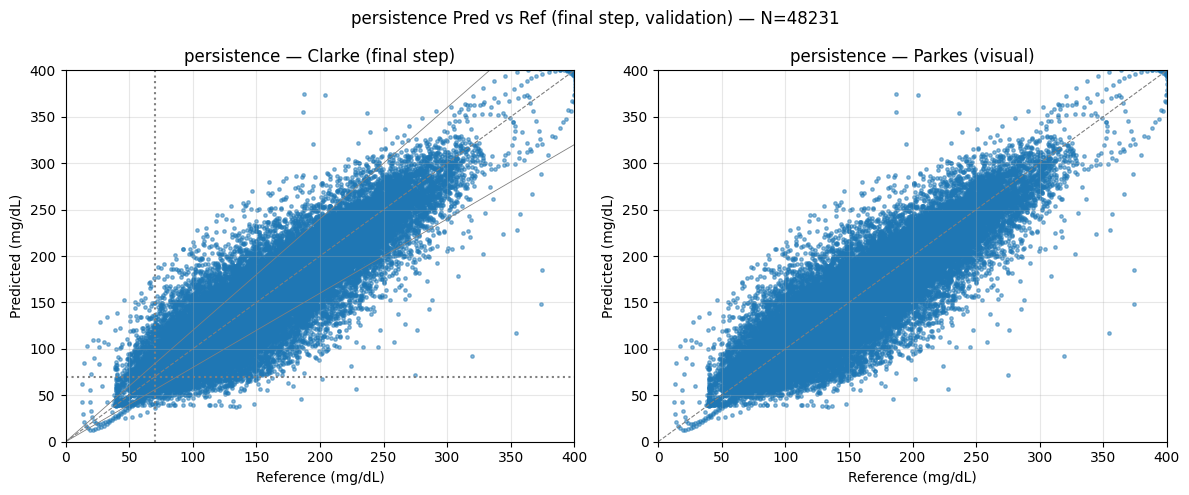


bergman Clarke zones:  {'A': (29084, 60.3), 'B': (19147, 39.7)}
bergman Parkes zones :  {'A': (29084, 60.3), 'B': (9664, 20.04), 'C': (5518, 11.44), 'E': (3965, 8.22)}


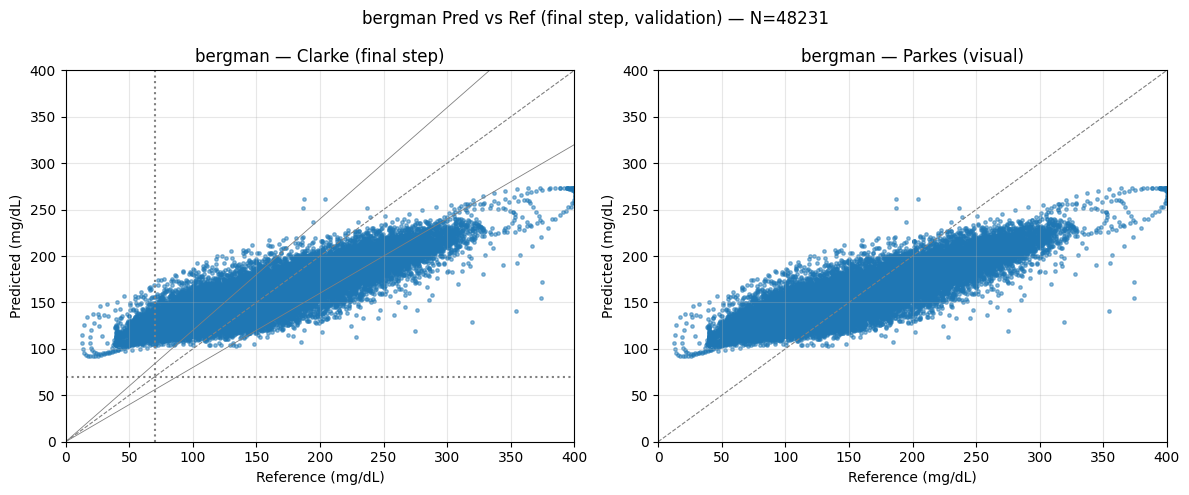


lstm Clarke zones:  {'A': (44740, 92.76), 'B': (3491, 7.24)}
lstm Parkes zones :  {'A': (44583, 92.44), 'C': (717, 1.49), 'B': (2805, 5.82), 'E': (126, 0.26)}


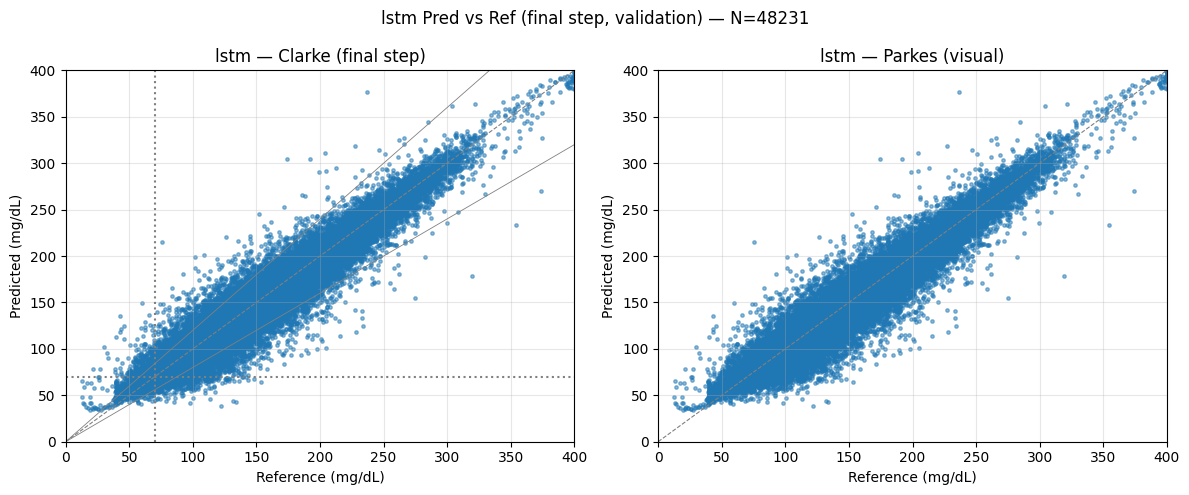


pinn Clarke zones:  {'A': (44945, 93.19), 'B': (3286, 6.81)}
pinn Parkes zones :  {'A': (44775, 92.83), 'C': (677, 1.4), 'E': (161, 0.33), 'B': (2618, 5.43)}


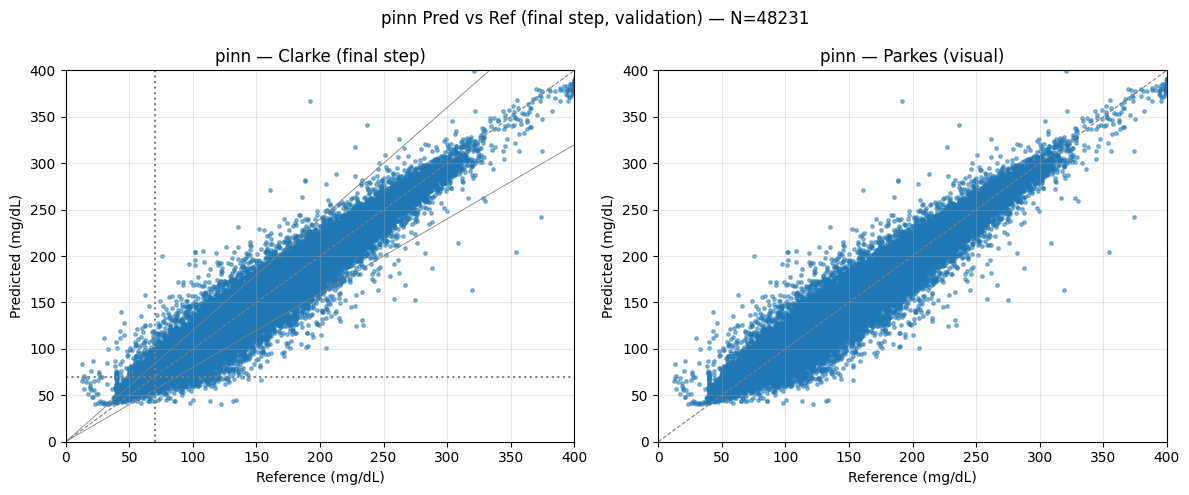


ml_corrector Clarke zones:  {'A': (28502, 59.09), 'B': (19724, 40.89), 'C': (4, 0.01), 'D': (1, 0.0)}
ml_corrector Parkes zones :  {'A': (28498, 59.09), 'B': (8890, 18.43), 'E': (4527, 9.39), 'C': (6311, 13.08), 'D': (5, 0.01)}


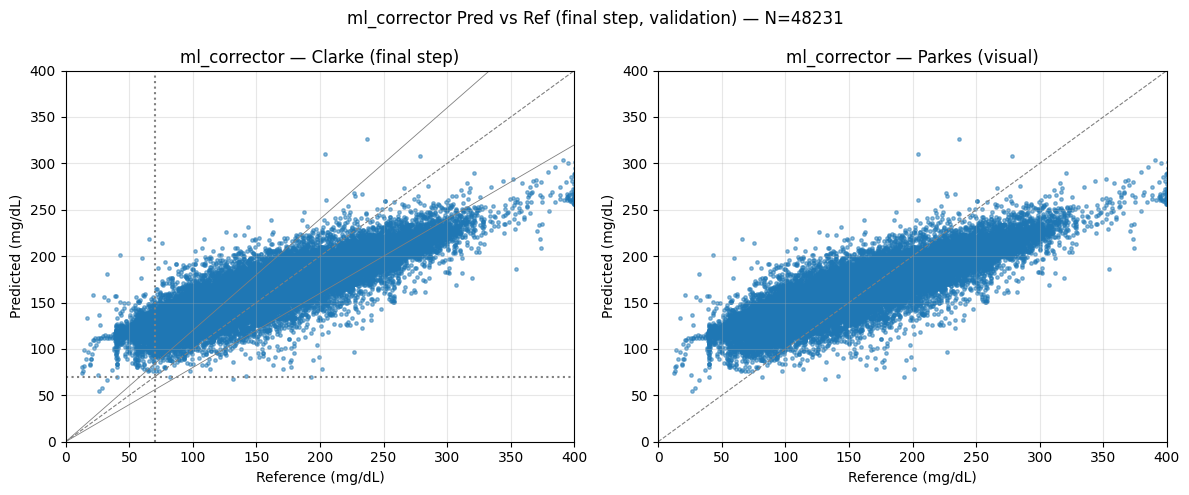


tuned_lstm Clarke zones:  {'A': (44663, 92.6), 'B': (3568, 7.4)}
tuned_lstm Parkes zones :  {'A': (44533, 92.33), 'C': (731, 1.52), 'E': (127, 0.26), 'B': (2840, 5.89)}


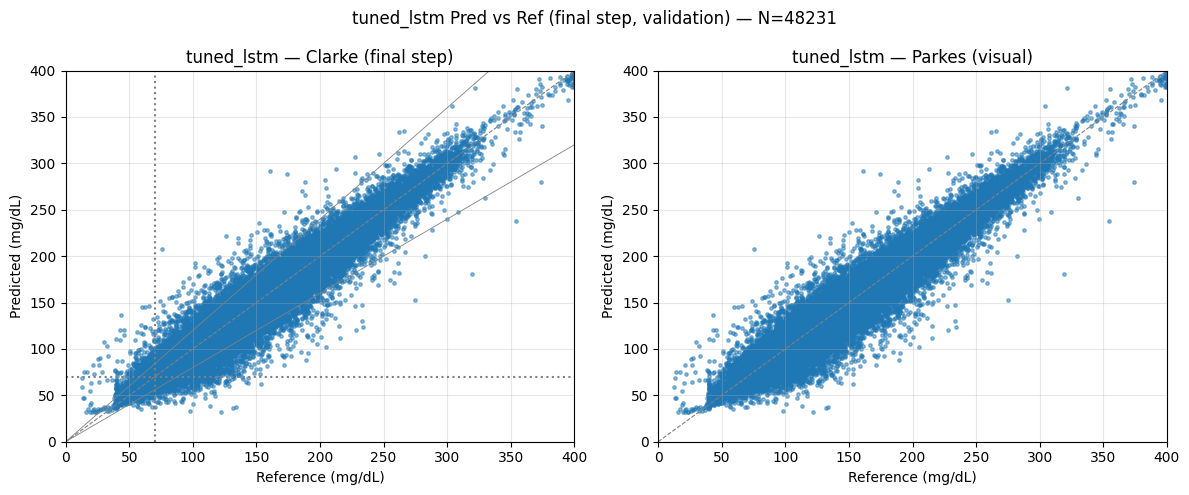


tuned_pinn Clarke zones:  {'A': (44945, 93.19), 'B': (3286, 6.81)}
tuned_pinn Parkes zones :  {'A': (44775, 92.83), 'C': (677, 1.4), 'E': (161, 0.33), 'B': (2618, 5.43)}


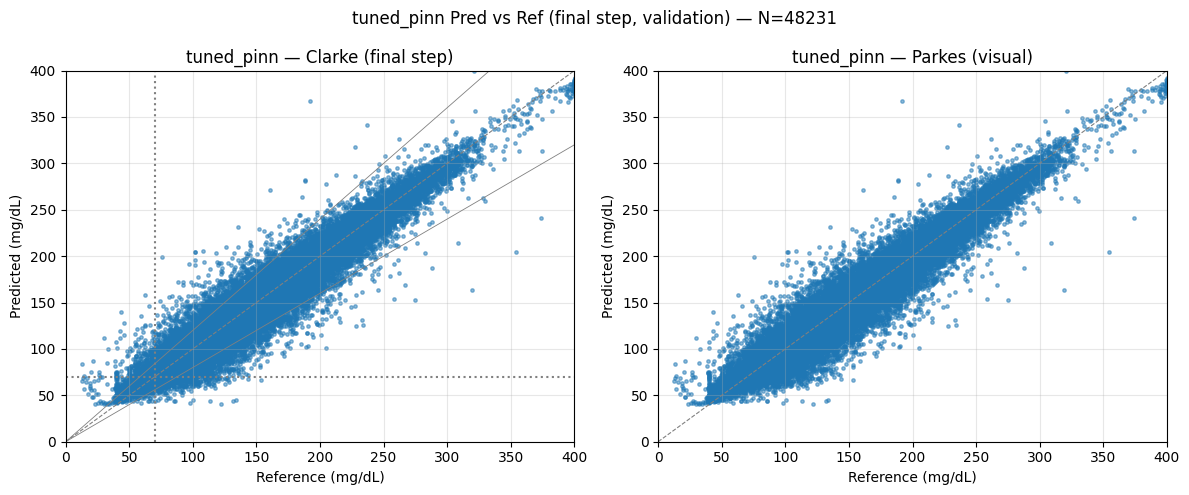


tuned_ml_corrector Clarke zones:  {'A': (31302, 64.9), 'B': (16927, 35.1), 'C': (2, 0.0)}
tuned_ml_corrector Parkes zones :  {'A': (31292, 64.88), 'C': (5460, 11.32), 'E': (3311, 6.86), 'B': (8166, 16.93), 'D': (2, 0.0)}


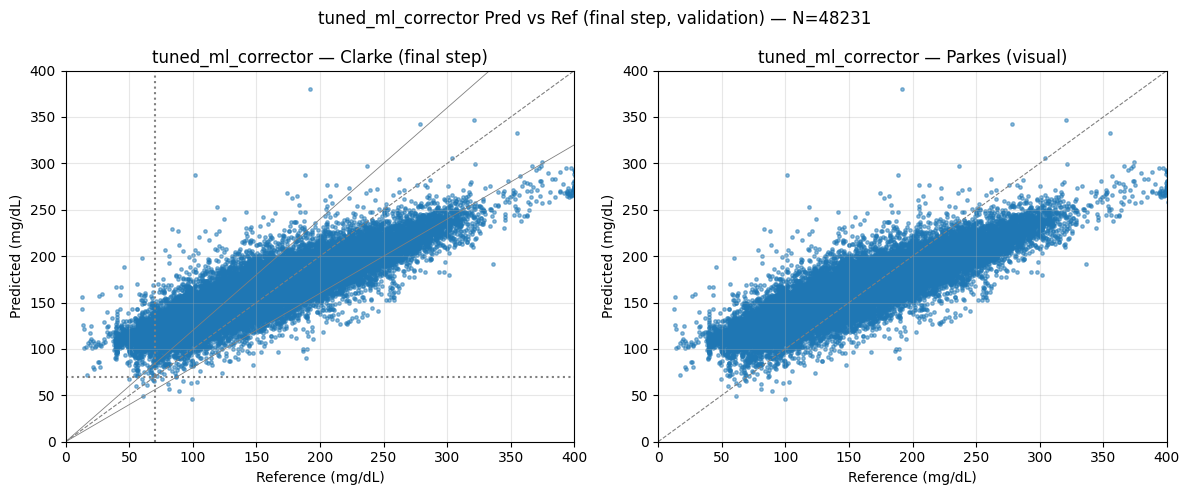


GLYCEMIA DETECTION CONFUSION MATRICES

Glycemia detection — persistence (final step):


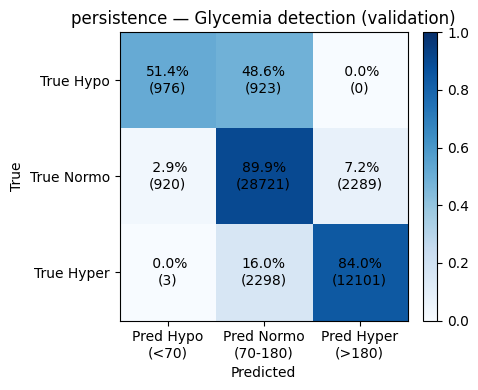


Glycemia detection — bergman (final step):


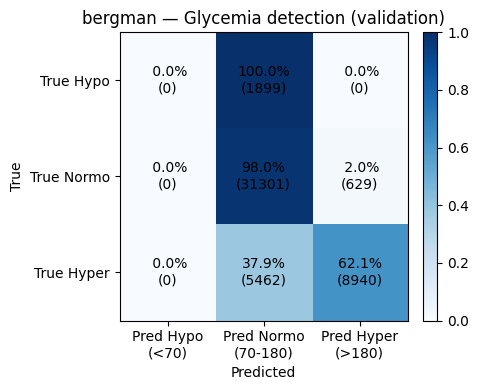


Glycemia detection — lstm (final step):


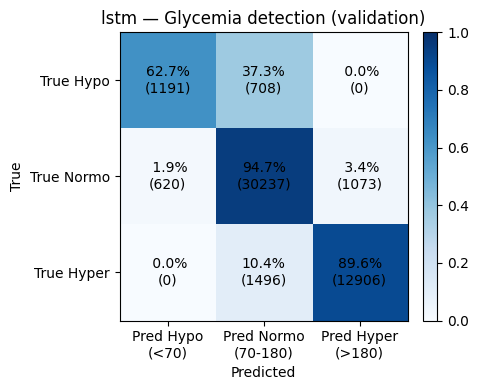


Glycemia detection — pinn (final step):


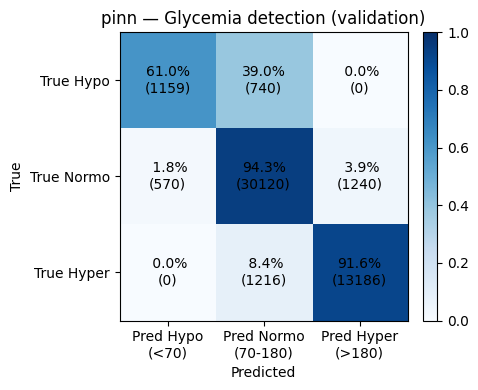


Glycemia detection — ml_corrector (final step):


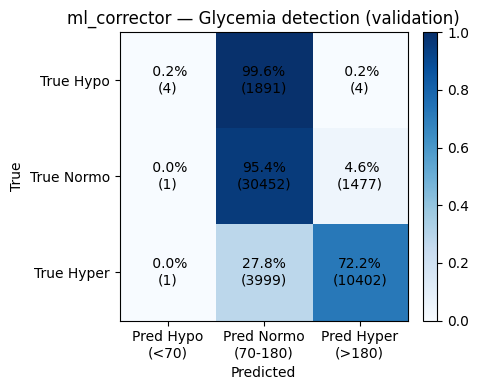


Glycemia detection — tuned_lstm (final step):


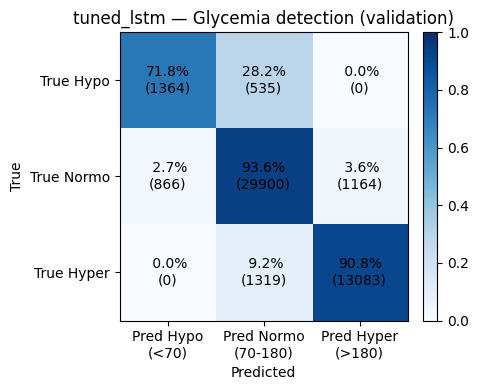


Glycemia detection — tuned_pinn (final step):


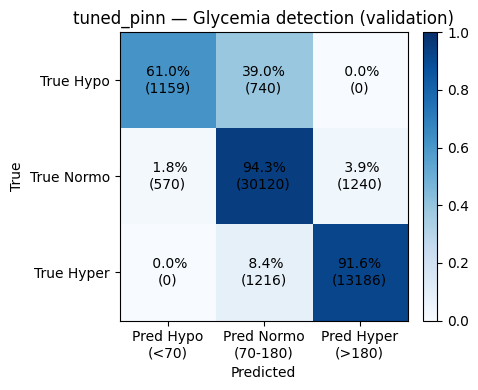


Glycemia detection — tuned_ml_corrector (final step):


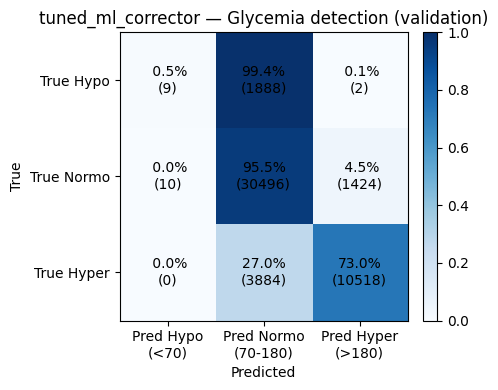


MULTI-STEP TRAJECTORY PLOTS (24 hour view)

COMBINED PER-HORIZON RMSE PLOT


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3276\3551051552.py:1096: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


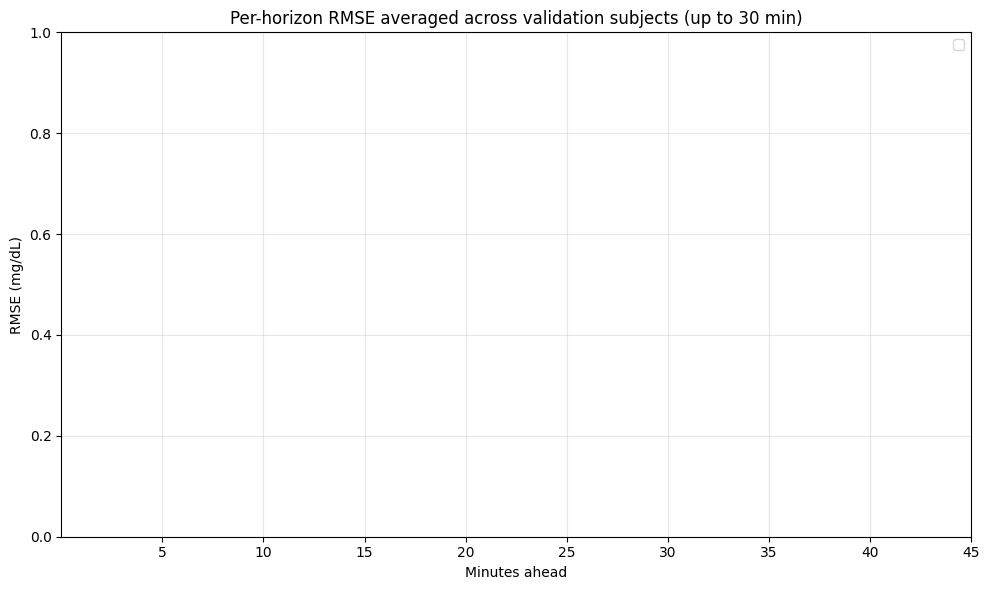


EVALUATION COMPLETE

Summary:
  ✓ Evaluated on validation data from OhioT1DM
  ✓ 3 validation subjects
  ✓ 48231 total validation windows
  ✓ Models evaluated: 8 (persistence, bergman, lstm, pinn, ml_corrector, tuned_lstm, tuned_pinn, tuned_ml_corrector)
  ✓ All metrics computed: RMSE, MAE, g-RMSE, g-MAE, TG, G-Mean
  ✓ Clarke & Parkes Error Grid analysis
  ✓ Glycemia detection confusion matrices
  ✓ Multi-step trajectory visualizations
  ✓ Per-horizon performance comparison



In [26]:
"""
Comprehensive Model Evaluation on Validation Data
Evaluates LSTM, Bergman, PINN, ML Corrector, and their tuned variants using validation subjects from OhioT1DM

REQUIRED VARIABLES FROM MODEL TRAINING CODES:

1. Data Processing Code ('Blood Glucose Forecasting Data Processing'):
   - train_subjects: Dict of processed subject DataFrames
   - val_subjects: Dict (or create from train_subjects using val_ids)
   - train_sequences: Dict with 'X' and 'y' for training subjects
   - val_sequences: Dict with 'X' and 'y' for validation subjects
   - train_ids: List of training subject IDs
   - val_ids: List of validation subject IDs
   - cgm_scaler: Fitted MinMaxScaler for CGM
   - N_IN: Input sequence length (default: 12)
   - N_OUT: Output prediction horizon (default: 6)
   - bergman_params: Tuple of Bergman model parameters (p1, p2, p3, k_i, Gb)

2. LSTM Baseline Model:
   - lstm_model: Trained baseline LSTM model

3. PINN Model (Nested CV):
   - best_model: Best PINN model from cross-validation (variable name from PINN CV code)

4. ML Corrector Model:
   - lstm_corrector: Trained ML corrector model

5. Tuned LSTM Model (from Optuna):
   - tuned_lstm_model: Final tuned LSTM model

6. Tuned PINN Model (from two-phase training):
   - tuned_pinn_model: Final tuned PINN model

7. Tuned ML Corrector Model:
   - tuned_hybrid_corrector_model: Final tuned hybrid corrector model
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate
import warnings

# ============================================================================
# SETUP: Create validation subjects dictionary
# ============================================================================

print("="*70)
print("PREPARING VALIDATION DATA")
print("="*70)

# ============================================================================
# VERIFY REQUIRED VARIABLES
# ============================================================================

print("\nVerifying required variables from model training codes...")

required_vars = {
    # Data processing variables
    'train_subjects': 'Processed training subject data',
    'train_sequences': 'Training sequences (X, y)',
    'val_sequences': 'Validation sequences (X, y)',
    'train_ids': 'Training subject IDs',
    'val_ids': 'Validation subject IDs',
    'cgm_scaler': 'Fitted CGM scaler',
    'N_IN': 'Input sequence length',
    'N_OUT': 'Output prediction horizon',
    'bergman_params': 'Bergman model parameters',
    
    # Model variables
    'lstm_model': 'Baseline LSTM model',
    'best_model': 'PINN model (from nested CV)',
    'lstm_corrector': 'ML Corrector model',
    'tuned_lstm_model': 'Tuned LSTM model',
    'tuned_pinn_model': 'Tuned PINN model',
    'tuned_hybrid_corrector_model': 'Tuned ML Corrector model'
}

missing_vars = []
available_models = []

for var_name, description in required_vars.items():
    if var_name not in globals():
        missing_vars.append(f"  - {var_name}: {description}")
    else:
        print(f"  ✓ {var_name}: {description}")
        if 'model' in var_name.lower():
            available_models.append(var_name)

if missing_vars:
    print("\n" + "="*70)
    print("WARNING: Some variables are missing")
    print("="*70)
    print("\nThe following variables were not found:")
    for msg in missing_vars:
        print(msg)
    print("\nEvaluation will proceed with available models only.")
    print("Models that will be skipped due to missing variables will be noted during execution.")

print(f"\n✓ Found {len(available_models)} model variables")
print(f"Available models: {', '.join([m.replace('_model', '').replace('best', 'pinn') for m in available_models])}")

# Create val_subjects dictionary from train_subjects using val_ids
val_subjects = {sid: train_subjects[sid] for sid in val_ids}
print(f"Validation subjects: {len(val_subjects)}")
print(f"Validation sequences: {X_val.shape[0]} windows")

# ============================================================================
# HELPER FUNCTIONS (from evaluation code)
# ============================================================================

def inv_cgm_with_scaler(y_scaled):
    """Convert scaled CGM values back to mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cgm_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0
HYPER = 180.0

def glycemia_class(x):
    """Classify glucose values: 0=hypo (<70), 1=normo (70-180), 2=hyper (>180)"""
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Constrained Cross-Correlation Temporal Gain (mirrors the pasted implementation).
    
    Measures temporal synchronization by finding optimal lag within constrained range.
    Only searches for negative lags (prediction leading) or zero lag.
    
    NOTE: This has the same limitation as the original - models with good temporal
    alignment will score high regardless of actual predictive value.
    
    Args:
        y_true: Ground truth glucose values (n_windows, n_steps) or (n_samples,)
        y_pred: Predicted glucose values (n_windows, n_steps) or (n_samples,)
        prediction_horizon: Total prediction window in minutes (e.g., 30 or 60)
    
    Returns:
        Temporal gain in minutes (median across windows)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Handle 1D vs 2D input
    if y_true.ndim == 1 and y_pred.ndim == 1:
        # Single sequence - compute once
        y_true_arr = y_true.reshape(1, -1)
        y_pred_arr = y_pred.reshape(1, -1)
    elif y_true.ndim == 2 and y_pred.ndim == 2:
        # Multiple windows
        y_true_arr = y_true
        y_pred_arr = y_pred
    else:
        return int(prediction_horizon)
    
    n_windows, n_steps = y_true_arr.shape
    dt_minutes = 5  # Assuming 5-minute timesteps
    
    tg_windows = []
    
    for i in range(n_windows):
        t = y_true_arr[i].astype(float)
        p = y_pred_arr[i].astype(float)
        
        # Skip invalid windows
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            continue
        
        # Remove mean for correlation (standardization)
        t_centered = t - np.nanmean(t)
        p_centered = p - np.nanmean(p)
        
        # Compute cross-correlation
        cross_corr = correlate(t_centered, p_centered, mode='full')
        
        # Define constrained lag range
        lag_min = -prediction_horizon // dt_minutes  # e.g., -12 for PH=60
        lag_max = 0  # Only look at prediction leading or synchronized
        
        # Calculate full range of lags
        full_lags = np.arange(-len(t) + 1, len(p))
        
        # Filter valid lags within the prediction horizon
        valid_mask = (full_lags >= lag_min) & (full_lags <= lag_max)
        valid_lags = full_lags[valid_mask]
        valid_cross_corr = cross_corr[valid_mask]
        
        if len(valid_cross_corr) == 0:
            tg_windows.append(0)
            continue
        
        # Find lag with maximum correlation
        max_corr_idx = np.argmax(np.abs(valid_cross_corr))
        optimal_lag_steps = valid_lags[max_corr_idx]
        
        # Convert to temporal gain in minutes
        # If lag = 0 (synchronized), TG = prediction_horizon
        # If lag = -12 (max delay), TG = 0
        tg_minutes = prediction_horizon + (optimal_lag_steps * dt_minutes)
        tg_minutes = max(0.0, min(float(prediction_horizon), float(tg_minutes)))
        
        tg_windows.append(tg_minutes)
    
    if len(tg_windows) == 0:
        return int(prediction_horizon)
    
    return int(round(np.median(tg_windows)))

def g_mean(y_true, y_pred):
    """Geometric mean of per-class recall"""
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true)
    p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

def _sigma_ge(x, a, eps):
    """Smooth step function (C2 continuous)"""
    x = np.asarray(x, dtype=float)
    a = np.asarray(a, dtype=float)
    out = np.zeros_like(x, dtype=float)
    
    if np.asarray(eps).size == 1 and eps <= 0:
        out = (x > a).astype(float)
        return out
    
    left = x <= a
    right = x >= (a + eps)
    mid = (~left) & (~right)
    
    out[right] = 1.0
    
    if np.any(mid):
        mid_vals = x[mid]
        a_arr = np.asarray(a)
        if a_arr.shape == ():
            a_mid = a_arr
        else:
            a_b = np.broadcast_to(a_arr, x.shape)
            a_mid = a_b[mid]
        
        xi = 2.0 * (mid_vals - a_mid) / eps - 1.0
        first_half = xi <= 0
        second_half = ~first_half
        
        val = np.empty_like(xi)
        if np.any(first_half):
            xi_f = xi[first_half]
            val[first_half] = (-0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
        if np.any(second_half):
            xi_s = xi[second_half]
            val[second_half] = (0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5
        
        out[mid] = val
    
    return out

def _sigma_le_bar(x, a, eps):
    """Smooth step function (mirror of _sigma_ge)"""
    x = np.asarray(x, dtype=float)
    a = np.asarray(a, dtype=float)
    out = np.zeros_like(x, dtype=float)
    
    if np.asarray(eps).size == 1 and eps <= 0:
        out = (x <= a).astype(float)
        return out
    
    left = x <= (a - eps)
    right = x >= a
    mid = (~left) & (~right)
    
    out[left] = 1.0
    
    if np.any(mid):
        mid_vals = x[mid]
        a_arr = np.asarray(a)
        if a_arr.shape == ():
            a_mid = a_arr
        else:
            a_b = np.broadcast_to(a_arr, x.shape)
            a_mid = a_b[mid]
        
        xi = 2.0 * (mid_vals - a_mid) / eps + 1.0
        first_half = xi <= 0
        second_half = ~first_half
        
        val = np.empty_like(xi)
        if np.any(first_half):
            xi_f = xi[first_half]
            val[first_half] = (0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
        if np.any(second_half):
            xi_s = xi[second_half]
            val[second_half] = (-0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5
        
        out[mid] = val
    
    return out

def pen_function(g, ghat, alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
                 betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """Penalty function for glucose-weighted metrics"""
    g = np.asarray(g, dtype=float)
    ghat = np.asarray(ghat, dtype=float)
    
    if g.shape == () and ghat.shape != ():
        g = np.full_like(ghat, float(g))
    elif ghat.shape == () and g.shape != ():
        ghat = np.full_like(g, float(ghat))
    else:
        bshape = np.broadcast_shapes(g.shape, ghat.shape)
        g = np.broadcast_to(g, bshape).astype(float)
        ghat = np.broadcast_to(ghat, bshape).astype(float)
    
    partL = _sigma_le_bar(g, TL, betaL) * _sigma_ge(ghat, g, gammaL)
    partH = _sigma_ge(g, TH, betaH) * _sigma_le_bar(ghat, g, gammaH)
    Pen = 1.0 + alphaL * partL + alphaH * partH
    return Pen

def glucose_weighted_rmse(y_true, y_pred, alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
                          betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """Glucose-weighted RMSE"""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    
    Pen = pen_function(y_true, y_pred, alphaL, alphaH, TL, TH, betaL, betaH, gammaL, gammaH)
    gse = (y_true - y_pred)**2 * Pen
    return math.sqrt(np.mean(gse))

def glucose_weighted_mae(y_true, y_pred, alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
                         betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """Glucose-weighted MAE"""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    
    Pen = pen_function(y_true, y_pred, alphaL, alphaH, TL, TH, betaL, betaH, gammaL, gammaH)
    gabs = np.abs(y_true - y_pred) * Pen
    return float(np.mean(gabs))

def clarke_zone_for_point(ref, pred):
    """Clarke Error Grid zone classification"""
    if np.isnan(ref) or np.isnan(pred):
        return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20):
        return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330):
        return 'E'
    if ref < 70 and pred >= 180:
        return 'C'
    if ref >= 180 and pred < 70:
        return 'D'
    return 'B'

def parkes_zone_for_point(ref, pred):
    """Parkes (Consensus) Error Grid zone classification"""
    if np.isnan(ref) or np.isnan(pred):
        return None
    err = pred - ref
    rel_err = abs(err) / max(ref, 1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2):
        return 'A'
    if rel_err <= 0.35:
        return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return 'D'
    if rel_err > 0.6:
        return 'E'
    return 'C'

def compute_glycemia_confusion(y_true, y_pred):
    """Compute confusion matrix for glycemia detection"""
    y_t = np.asarray(y_true).reshape(-1)
    y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]
    y_p = y_p[mask]
    
    counts = np.zeros((3, 3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    
    tcls = glycemia_class(y_t)
    pcls = glycemia_class(y_p)
    
    for t, p in zip(tcls, pcls):
        if 0 <= t <= 2 and 0 <= p <= 2:
            counts[t, p] += 1
    
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s > 0:
            pct[i, :] = counts[i, :] / float(s)
    
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    """Plot glycemia detection confusion matrix heatmap"""
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)', 'Pred Normo\n(70-180)', 'Pred Hyper\n(>180)']
    ax.set_xticklabels(labels)
    ax.set_yticklabels(['True Hypo', 'True Normo', 'True Hyper'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    
    for i in range(3):
        for j in range(3):
            c = counts[i, j]
            p = pct[i, j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# ============================================================================
# MODEL PREDICTION FUNCTIONS
# ============================================================================

def persistence_predict_on_val_subject(sid):
    """Persistence baseline: last observed value repeated"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    n_windows = X_subj.shape[0]
    
    # Last CGM value from input sequence (already scaled)
    last_cgm = X_subj[:, -1, 0]  # Shape: (n_windows,)
    
    # Repeat for all forecast steps
    preds_scaled = np.tile(last_cgm.reshape(-1, 1), (1, N_OUT))
    return preds_scaled.reshape(n_windows, N_OUT, 1)

def bergman_predict_on_val_subject(sid):
    """Bergman physiological model predictions"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    subj_df = val_subjects[sid]
    n_windows = X_subj.shape[0]
    
    # Initial glucose values (mg/dL) for each window
    G_inits = subj_df['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    
    # Extract insulin and carbs for forecast horizon
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat = np.zeros((n_windows, N_OUT))
    
    for w in range(n_windows):
        start_idx = N_IN + w
        bolus_mat[w, :] = subj_df['bolus'].values[start_idx:start_idx+N_OUT]
        carbs_mat[w, :] = subj_df['carbs'].values[start_idx:start_idx+N_OUT]
    
    # Bergman parameters (should be defined from bergman_params variable)
    p1, p2, p3, k_i, Gb = bergman_params
    dt_scale = 1.0  # 5min/5min scaling factor
    
    # Simulate forward
    preds_mg = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    
    for t in range(N_OUT):
        # Update insulin with decay and new dose
        I = I * np.exp(-k_i) + bolus_mat[:, t]
        
        # Meal effect
        meal_effect = p3 * carbs_mat[:, t]
        
        # Glucose dynamics
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_scale
        preds_mg[:, t] = G
    
    # Scale to [0, 1]
    preds_scaled = cgm_scaler.transform(preds_mg.reshape(-1, 1)).reshape(n_windows, N_OUT)
    return preds_scaled.reshape(n_windows, N_OUT, 1)

def lstm_predict_on_val_subject(sid):
    """LSTM model predictions"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    preds_scaled = lstm_model.predict(X_subj, batch_size=64, verbose=0)
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def pinn_predict_on_val_subject(sid):
    """Physics-Informed Neural Network predictions (non-tuned baseline)"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X'].astype(np.float32)
    # Use best_model from PINN nested CV (variable name from PINN training code)
    preds_scaled, _ = best_model(X_subj, training=False)
    preds_scaled = preds_scaled.numpy()
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def ml_corrector_predict_on_val_subject(sid):
    """Hybrid ML corrector: Bergman + learned residual"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    
    # Get residual predictions from corrector model
    resid_scaled = lstm_corrector.predict(X_subj, batch_size=128, verbose=0)
    
    # Get Bergman baseline predictions
    bergman_preds = bergman_predict_on_val_subject(sid)
    bergman_preds_scaled = bergman_preds.reshape(-1, N_OUT)
    
    # Correct Bergman with residual
    corrected_scaled = bergman_preds_scaled + resid_scaled
    return corrected_scaled.reshape(-1, N_OUT, 1)

# ============================================================================
# TUNED MODEL PREDICTION FUNCTIONS
# NOTE: These assume you have the following variables defined from your tuning:
#   - tuned_lstm_model (from Optuna tuning)
#   - tuned_pinn_model (from two-phase PINN training)
#   - tuned_hybrid_corrector_model (from hybrid corrector tuning)
# ============================================================================

def tuned_lstm_predict_on_val_subject(sid):
    """Tuned LSTM model predictions"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    preds_scaled = tuned_lstm_model.predict(X_subj, batch_size=64, verbose=0)
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def tuned_pinn_predict_on_val_subject(sid):
    """Tuned Physics-Informed Neural Network predictions"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X'].astype(np.float32)
    preds_scaled, _ = tuned_pinn_model(X_subj, training=False)
    preds_scaled = preds_scaled.numpy()
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def tuned_ml_corrector_predict_on_val_subject(sid):
    """Tuned Hybrid ML corrector: Bergman + learned residual"""
    info = val_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    
    # Get residual predictions from tuned corrector model
    resid_scaled = tuned_hybrid_corrector_model.predict(X_subj, batch_size=128, verbose=0)
    
    # Get Bergman baseline predictions
    bergman_preds = bergman_predict_on_val_subject(sid)
    bergman_preds_scaled = bergman_preds.reshape(-1, N_OUT)
    
    # Correct Bergman with residual
    corrected_scaled = bergman_preds_scaled + resid_scaled
    return corrected_scaled.reshape(-1, N_OUT, 1)

# ============================================================================
# COLLECT PREDICTIONS FROM ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING PREDICTIONS ON VALIDATION DATA")
print("="*70)

# Define all possible models
all_models = {
    'persistence': persistence_predict_on_val_subject,
    'bergman': bergman_predict_on_val_subject,
    'lstm': lstm_predict_on_val_subject,
    'pinn': pinn_predict_on_val_subject,
    'ml_corrector': ml_corrector_predict_on_val_subject,
    'tuned_lstm': tuned_lstm_predict_on_val_subject,
    'tuned_pinn': tuned_pinn_predict_on_val_subject,
    'tuned_ml_corrector': tuned_ml_corrector_predict_on_val_subject
}

# Check which models are actually available by testing if required variables exist
models = {}
skipped_models = []

# Persistence and Bergman always available (only need data)
models['persistence'] = persistence_predict_on_val_subject
models['bergman'] = bergman_predict_on_val_subject

# Check LSTM
if 'lstm_model' in globals():
    models['lstm'] = lstm_predict_on_val_subject
else:
    skipped_models.append('lstm')

# Check PINN (uses best_model from nested CV)
if 'best_model' in globals():
    models['pinn'] = pinn_predict_on_val_subject
else:
    skipped_models.append('pinn')

# Check ML Corrector
if 'lstm_corrector' in globals():
    models['ml_corrector'] = ml_corrector_predict_on_val_subject
else:
    skipped_models.append('ml_corrector')

# Check Tuned LSTM
if 'tuned_lstm_model' in globals():
    models['tuned_lstm'] = tuned_lstm_predict_on_val_subject
else:
    skipped_models.append('tuned_lstm')

# Check Tuned PINN
if 'tuned_pinn_model' in globals():
    models['tuned_pinn'] = tuned_pinn_predict_on_val_subject
else:
    skipped_models.append('tuned_pinn')

# Check Tuned ML Corrector
if 'tuned_hybrid_corrector_model' in globals():
    models['tuned_ml_corrector'] = tuned_ml_corrector_predict_on_val_subject
else:
    skipped_models.append('tuned_ml_corrector')

print(f"\nEvaluating {len(models)} models: {', '.join(models.keys())}")
if skipped_models:
    print(f"Skipping {len(skipped_models)} models (not found): {', '.join(skipped_models)}")

# Collect predictions for all validation subjects
all_results = {}
for mname, mpredict in models.items():
    print(f"\nModel: {mname}")
    Ys = []
    for sid in val_ids:
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        
        yhat_mg = inv_cgm_with_scaler(yhat_scaled)
        Ys.append(yhat_mg)
        print(f"  Subject {sid}: {yhat_mg.shape[0]} windows")
    
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))
    print(f"  Total: {all_results[mname].shape[0]} windows")

# Build ground truth (all validation windows)
y_true_all_windows = []
for sid in val_ids:
    info = val_sequences.get(sid)
    y_val_subj = info['y']
    if y_val_subj.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_scaler(y_val_subj.reshape(-1, N_OUT))
    y_true_all_windows.append(y_true_mg)

if len(y_true_all_windows) == 0:
    raise RuntimeError("No validation windows found.")

y_true_all = np.vstack(y_true_all_windows)
print(f"\nGround truth: {y_true_all.shape[0]} windows")

# ============================================================================
# EVALUATION METRICS
# ============================================================================

print("\n" + "="*70)
print("EVALUATION METRICS")
print("="*70)

# Per-horizon RMSE/MAE
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for each model ===")

per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"\nModel {mname}: no predictions")
        continue
    
    rmse_h = []
    mae_h = []
    
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v, 2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v, 2) for v in mae_h])

# Final-step aggregated metrics
print("\n=== Final-step aggregated metrics (30 min) ===")

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    
    ref = y_true_all[:, -1]
    pred = ypred_all[:, -1]
    
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae = glucose_weighted_mae(ref, pred)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    
    print(f"\nModel: {mname}")
    print(f"  Windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# ============================================================================
# CLARKE & PARKES ERROR GRIDS + SCATTER PLOTS
# ============================================================================

print("\n" + "="*70)
print("CLARKE & PARKES ERROR GRIDS")
print("="*70)

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    
    ref = y_true_all[:, -1]
    pred = ypred_all[:, -1]
    
    # Compute zones
    cz = [clarke_zone_for_point(r, p) for r, p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r, p) for r, p in zip(ref, pred)]
    
    c_counts = dict(Counter(cz))
    p_counts = dict(Counter(pz))
    total = len(ref)
    
    print(f"\n{mname} Clarke zones: ", {k: (c_counts[k], round(100*c_counts[k]/total, 2)) 
                                         for k in c_counts})
    print(f"{mname} Parkes zones : ", {k: (p_counts[k], round(100*p_counts[k]/total, 2)) 
                                        for k in p_counts})
    
    # Scatter plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Clarke grid
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0, 400], [0, 400], '--', linewidth=0.8, color='gray')
    xs = np.linspace(0, 400, 100)
    ax0.plot(xs, 1.2*xs, linewidth=0.6, color='gray')
    ax0.plot(xs, 0.8*xs, linewidth=0.6, color='gray')
    ax0.axvline(70, linestyle=':', color='gray')
    ax0.axhline(70, linestyle=':', color='gray')
    ax0.set_xlim(0, 400)
    ax0.set_ylim(0, 400)
    ax0.set_xlabel('Reference (mg/dL)')
    ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")
    ax0.grid(True, alpha=0.3)
    
    # Parkes grid
    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0, 400], [0, 400], '--', linewidth=0.8, color='gray')
    ax1.set_xlim(0, 400)
    ax1.set_ylim(0, 400)
    ax1.set_xlabel('Reference (mg/dL)')
    ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    ax1.grid(True, alpha=0.3)
    
    plt.suptitle(f"{mname} Pred vs Ref (final step, validation) — N={total}")
    plt.tight_layout()
    plt.show()

# ============================================================================
# GLYCEMIA DETECTION CONFUSION MATRICES
# ============================================================================

print("\n" + "="*70)
print("GLYCEMIA DETECTION CONFUSION MATRICES")
print("="*70)

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (validation)")

# ============================================================================
# MULTI-STEP TRAJECTORY PLOTS (Selected Subjects, 24h view)
# ============================================================================

print("\n" + "="*70)
print("MULTI-STEP TRAJECTORY PLOTS (24 hour view)")
print("="*70)

dt = 5  # minutes
prediction_horizon_min = 45  # minutes
ph_steps = int(prediction_horizon_min // dt)
total_minutes = 24 * 60
time_bins = np.arange(dt, total_minutes + dt, dt)
nbins = len(time_bins)

model_order = ['persistence', 'bergman', 'lstm', 'ml_corrector', 'pinn', 
               'tuned_lstm', 'tuned_ml_corrector', 'tuned_pinn']
color_map = {
    'persistence': 'tab:orange',
    'bergman': 'tab:green',
    'lstm': 'tab:blue',
    'ml_corrector': 'tab:red',
    'pinn': 'purple',
    'tuned_lstm': 'darkblue',
    'tuned_ml_corrector': 'darkred',
    'tuned_pinn': 'darkviolet'
}

selected_sids = val_ids[:min(3, len(val_ids))]  # First 3 validation subjects

for sid in selected_sids:
    info = val_sequences.get(sid)
    if info is None:
        continue
    
    y_val_subj = info['y']
    if y_val_subj.shape[0] == 0:
        continue
    
    y_test_arr = np.asarray(y_val_subj)
    if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
        y_test_flat = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
    else:
        y_test_flat = y_test_arr.copy()
    
    if y_test_flat.shape[1] < ph_steps:
        continue
    
    y_test_mg = inv_cgm_with_scaler(y_test_flat[:, :ph_steps])
    
    n_models = len(model_order)
    fig, axs = plt.subplots(2, n_models, figsize=(5*n_models, 9), sharex=True)
    if n_models == 1:
        axs = axs.reshape(2, 1)
    
    fig.suptitle(f"Subject {sid} — 30-min forecasts (validation, 24h view)", fontsize=14)
    
    for i_m, mname in enumerate(model_order):
        ax_top = axs[0, i_m]
        ax_bot = axs[1, i_m]
        
        if mname not in models:
            ax_top.text(0.5, 0.5, f"model '{mname}' not found", ha='center', va='center')
            ax_top.set_title(mname)
            ax_bot.set_visible(False)
            continue
        
        yhat_scaled_all = models[mname](sid)
        yhat_scaled_all = np.asarray(yhat_scaled_all)
        
        if yhat_scaled_all.size == 0:
            ax_top.text(0.5, 0.5, "no preds", ha='center', va='center')
            ax_top.set_title(mname)
            ax_bot.set_visible(False)
            continue
        
        if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
            yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], 
                                                       yhat_scaled_all.shape[1])
        
        if yhat_scaled_all.shape[1] < ph_steps:
            continue
        
        yhat_mg_all = inv_cgm_with_scaler(yhat_scaled_all[:, :ph_steps])
        n_windows = yhat_mg_all.shape[0]
        
        # Compute predicted times for each window
        win_idx = np.arange(n_windows).reshape(-1, 1)
        step_idx = np.arange(1, ph_steps+1).reshape(1, -1)
        pred_times = (win_idx * dt) + (step_idx * dt)
        
        pred_times_flat = pred_times.ravel().astype(int)
        preds_flat = yhat_mg_all.ravel()
        actuals_flat = y_test_mg.ravel()
        
        valid_mask = (pred_times_flat >= dt) & (pred_times_flat <= total_minutes)
        bin_idx = (pred_times_flat // dt) - 1
        
        agg_pred = np.full(nbins, np.nan)
        agg_actual = np.full(nbins, np.nan)
        agg_rmse = np.full(nbins, np.nan)
        agg_counts = np.zeros(nbins, dtype=int)
        
        for b in range(nbins):
            idxs = np.where((bin_idx == b) & valid_mask)[0]
            c = idxs.size
            agg_counts[b] = c
            if c > 0:
                vals_pred = preds_flat[idxs].astype(float)
                vals_act = actuals_flat[idxs].astype(float)
                agg_pred[b] = np.nanmean(vals_pred)
                agg_actual[b] = np.nanmean(vals_act)
                agg_rmse[b] = np.sqrt(np.nanmean((vals_pred - vals_act)**2))
        
        # Interpolate NaN gaps
        def interp_nan(arr):
            arr = arr.astype(float)
            mask = ~np.isnan(arr)
            if mask.sum() == 0:
                return arr
            first, last = np.where(mask)[0][0], np.where(mask)[0][-1]
            x = np.arange(first, last+1)
            y = arr[first:last+1]
            valid = ~np.isnan(y)
            if valid.sum() <= 1:
                return arr
            xi = np.arange(first, last+1)
            arr[first:last+1] = np.interp(xi, x[valid], y[valid])
            return arr
        
        agg_pred_f = interp_nan(agg_pred)
        agg_actual_f = interp_nan(agg_actual)
        
        t_minutes = time_bins
        t_hours = t_minutes / 60.0
        color = color_map.get(mname, 'gray')
        
        # TOP: Continuous trajectories
        if np.all(np.isnan(agg_actual_f)) and np.all(np.isnan(agg_pred_f)):
            ax_top.text(0.5, 0.5, "no data in 24h window", ha='center', va='center')
        else:
            ax_top.plot(t_hours, agg_actual_f, '-', color='black', linewidth=1.6, 
                       label='Actual (avg)')
            ax_top.plot(t_hours, agg_pred_f, '-', color=color, linewidth=2.0, 
                       label='Predicted (avg, 30-min PH)')
            
            # Overlay last window's short-term forecast
            last_pred = yhat_mg_all[-1, :ph_steps]
            last_times = (np.arange(1, ph_steps+1) * dt) / 60.0
            ax_top.plot(last_times, last_pred, '--', color=color, linewidth=1.4, 
                       label='Last-window 30-min')
        
        ax_top.set_title(mname)
        if i_m == 0:
            ax_top.set_ylabel('Blood Glucose (mg/dL)')
        
        ax_top.set_xlim(0, total_minutes/60.0)
        xticks = np.arange(0, (total_minutes/60.0) + 0.1, 2)
        ax_top.set_xticks(xticks)
        
        if HYPO is not None:
            ax_top.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
        
        all_vals = np.concatenate([
            agg_actual_f[~np.isnan(agg_actual_f)] if agg_actual_f is not None else np.array([]),
            agg_pred_f[~np.isnan(agg_pred_f)] if agg_pred_f is not None else np.array([])
        ])
        
        if all_vals.size > 0:
            lo, hi = np.nanpercentile(all_vals, [1, 99])
            pad = max(10, 0.05 * (hi - lo))
            ax_top.set_ylim(max(30, lo - pad), min(400, hi + pad))
        else:
            ax_top.set_ylim(40, 300)
        
        ax_top.grid(True, linestyle=':', alpha=0.3)
        ax_top.legend(fontsize=8)
        
        # BOTTOM: Just xlabel for consistency
        ax_bot.set_xlabel('Hours (since window start)')
        ax_bot.set_xlim(0, total_minutes/60.0)
        ax_bot.set_xticks(xticks)
        ax_bot.set_visible(False)  # Hide bottom panel for cleaner display
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ============================================================================
# COMBINED PER-HORIZON RMSE PLOT
# ============================================================================

print("\n" + "="*70)
print("COMBINED PER-HORIZON RMSE PLOT")
print("="*70)

model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}

for sid in val_ids:
    info = val_sequences.get(sid)
    if info is None:
        continue
    
    y_val_subj = info['y']
    if y_val_subj.shape[0] == 0:
        continue
    
    y_true_mg_full = inv_cgm_with_scaler(y_val_subj.reshape(-1, N_OUT))
    
    if y_true_mg_full.shape[1] < ph_steps:
        continue
    
    y_true_mg = y_true_mg_full[:, :ph_steps]
    
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        
        if yhat_scaled.shape[1] < ph_steps:
            continue
        
        yhat_mg = inv_cgm_with_scaler(yhat_scaled)[:, :ph_steps]
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:, h], yhat_mg[:, h])) 
                      for h in range(ph_steps)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(10, 6))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m]) > 0 else np.zeros((0, ph_steps))
    if subj_rmses.size == 0:
        continue
    
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(np.arange(1, ph_steps+1)*5, mean_rmse, '-o', label=m, linewidth=2)

plt.xticks(np.arange(1, ph_steps+1)*5)
plt.xlabel('Minutes ahead')
plt.ylabel('RMSE (mg/dL)')
plt.title('Per-horizon RMSE averaged across validation subjects (up to 30 min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)
print(f"""
Summary:
  ✓ Evaluated on validation data from OhioT1DM
  ✓ {len(val_ids)} validation subjects
  ✓ {y_true_all.shape[0]} total validation windows
  ✓ Models evaluated: {len(models)} ({', '.join(models.keys())})
  ✓ All metrics computed: RMSE, MAE, g-RMSE, g-MAE, TG, G-Mean
  ✓ Clarke & Parkes Error Grid analysis
  ✓ Glycemia detection confusion matrices
  ✓ Multi-step trajectory visualizations
  ✓ Per-horizon performance comparison
""")

## Evaluation - Testing - BrisT1D Dataset:

PREPARING TEST DATA (BrisT1D)

Verifying required variables from model training codes...
  ✓ test_subjects: Processed test subject data (BrisT1D)
  ✓ test_sequences: Test sequences (X, y)
  ✓ cgm_scaler: Fitted CGM scaler
  ✓ N_IN: Input sequence length
  ✓ N_OUT: Output prediction horizon
  ✓ bergman_params: Bergman model parameters
  ✓ lstm_model: Baseline LSTM model
  ✓ best_model: PINN model (from nested CV)
  ✓ lstm_corrector: ML Corrector model
  ✓ tuned_lstm_model: Tuned LSTM model
  ✓ tuned_pinn_model: Tuned PINN model
  ✓ tuned_hybrid_corrector_model: Tuned ML Corrector model

✓ Found 5 model variables
Available models: lstm, pinn, tuned_lstm, tuned_pinn, tuned_hybrid_corrector

Test subjects: 4
Test sequences: 209715 windows

GENERATING PREDICTIONS ON TEST DATA (BrisT1D)

Evaluating 8 models: persistence, bergman, lstm, pinn, ml_corrector, tuned_lstm, tuned_pinn, tuned_ml_corrector

Model: persistence
  Subject P01: 58345 windows
  Subject P02: 60288 windows
  Subject P03: 28

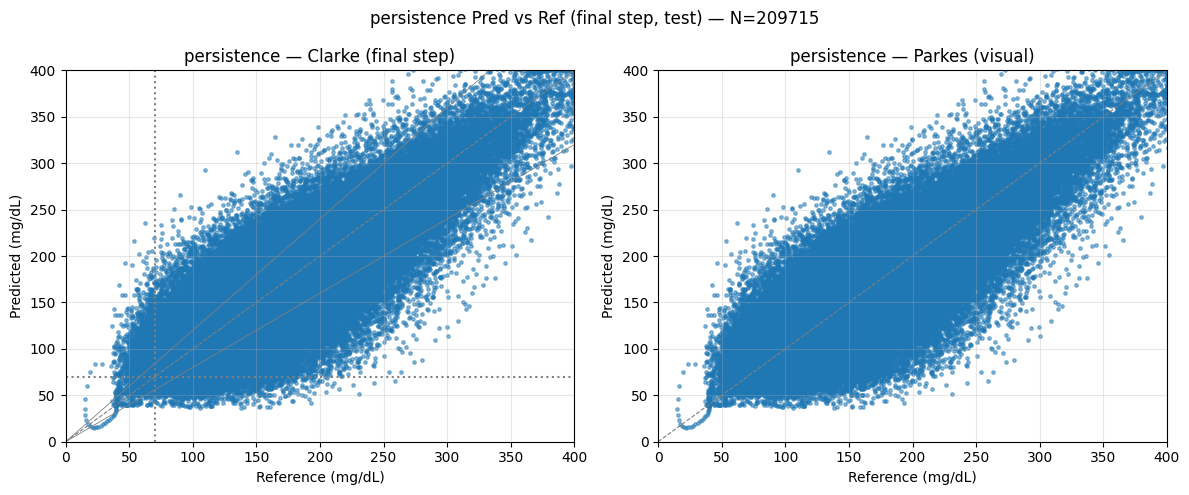


bergman Clarke zones:  {'A': (123241, 58.77), 'B': (86468, 41.23), 'C': (6, 0.0)}
bergman Parkes zones :  {'A': (123241, 58.77), 'B': (51018, 24.33), 'C': (22206, 10.59), 'E': (13244, 6.32), 'D': (6, 0.0)}


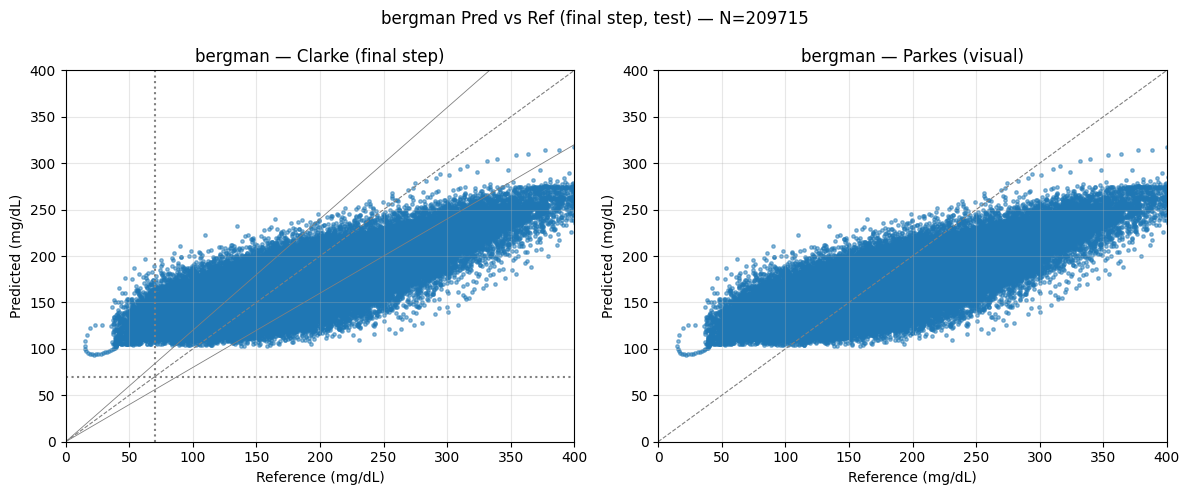


lstm Clarke zones:  {'A': (181024, 86.32), 'B': (28686, 13.68), 'D': (4, 0.0), 'C': (1, 0.0)}
lstm Parkes zones :  {'A': (180432, 86.04), 'B': (21509, 10.26), 'C': (7015, 3.35), 'E': (754, 0.36), 'D': (5, 0.0)}


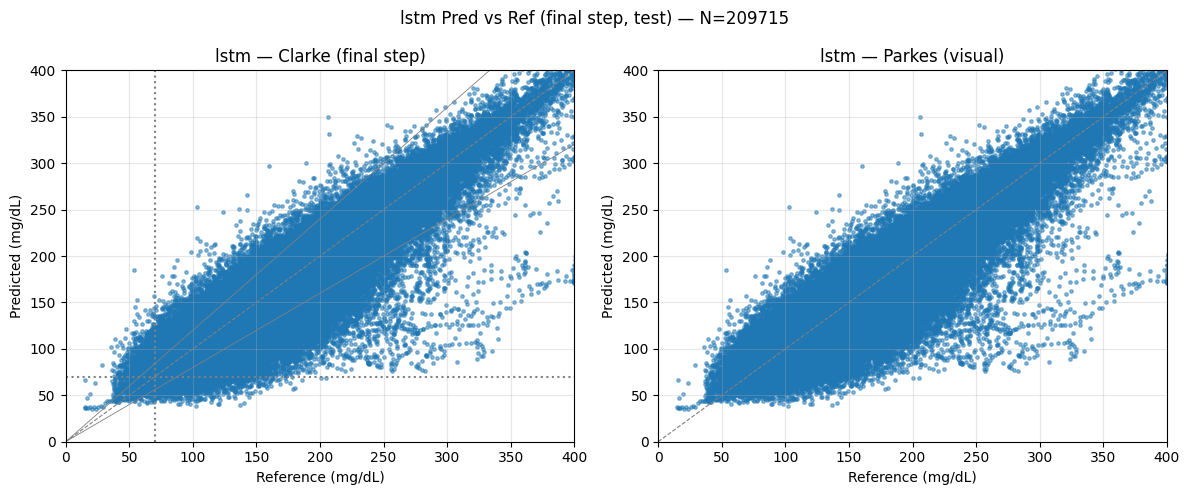


pinn Clarke zones:  {'A': (180555, 86.1), 'B': (29157, 13.9), 'D': (3, 0.0)}
pinn Parkes zones :  {'A': (179834, 85.75), 'B': (21909, 10.45), 'C': (7003, 3.34), 'E': (966, 0.46), 'D': (3, 0.0)}


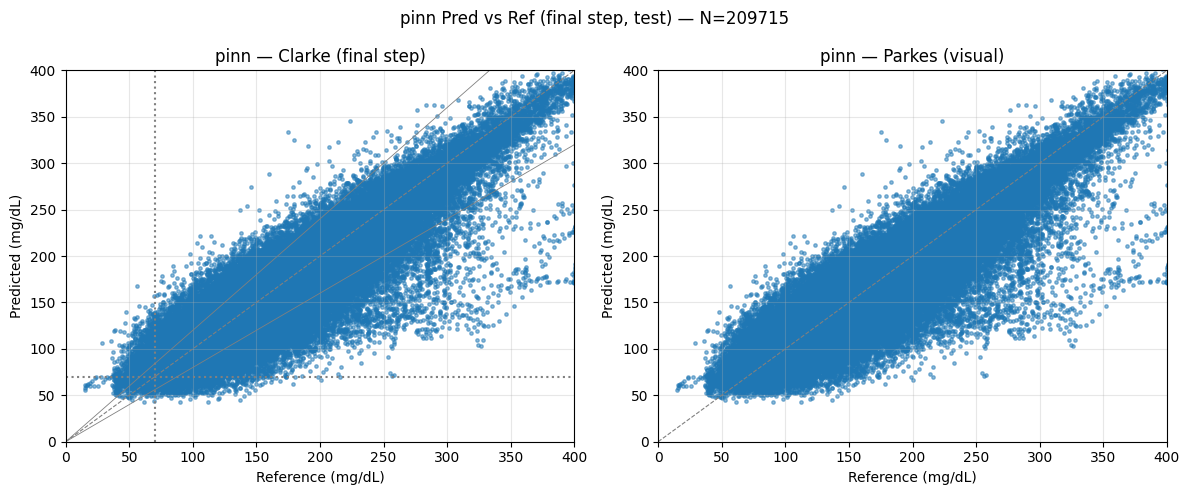


ml_corrector Clarke zones:  {'A': (115084, 54.88), 'B': (94181, 44.91), 'D': (432, 0.21), 'C': (18, 0.01)}
ml_corrector Parkes zones :  {'A': (114820, 54.75), 'B': (54390, 25.94), 'C': (30920, 14.74), 'E': (9135, 4.36), 'D': (450, 0.21)}


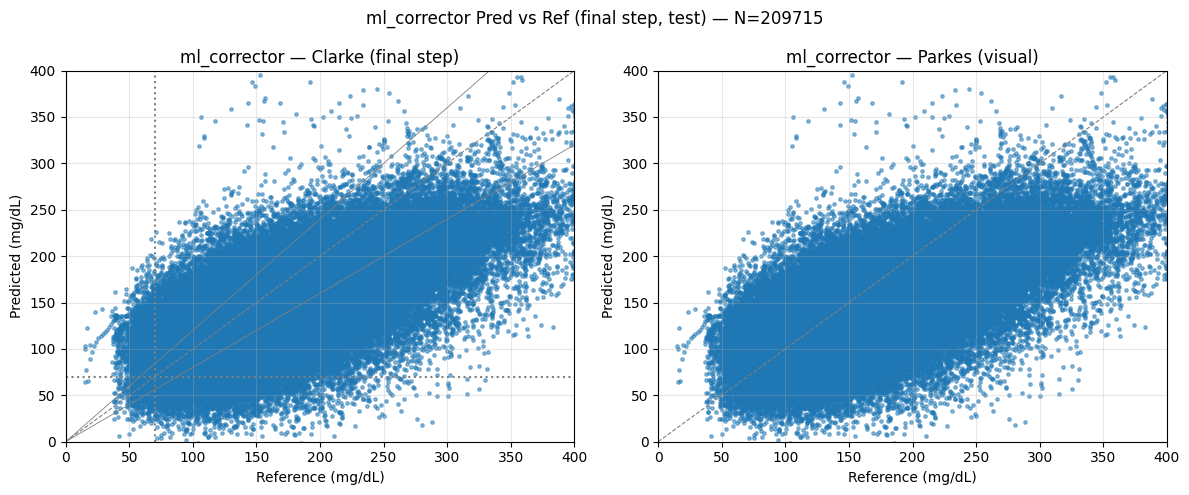


tuned_lstm Clarke zones:  {'A': (182447, 87.0), 'B': (27261, 13.0), 'D': (6, 0.0), 'C': (1, 0.0)}
tuned_lstm Parkes zones :  {'A': (181911, 86.74), 'B': (20289, 9.67), 'C': (6666, 3.18), 'E': (842, 0.4), 'D': (7, 0.0)}


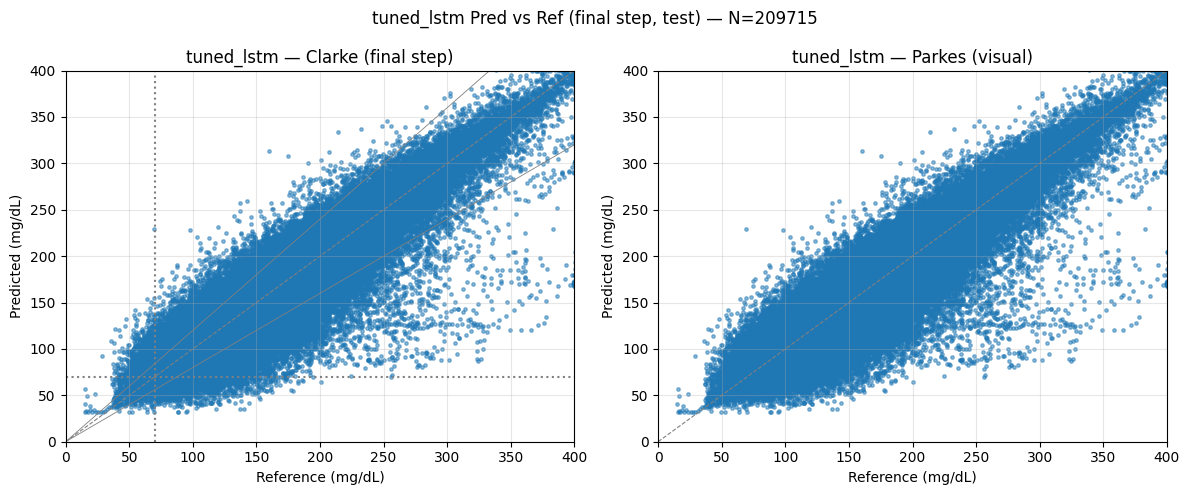


tuned_pinn Clarke zones:  {'A': (180555, 86.1), 'B': (29157, 13.9), 'D': (3, 0.0)}
tuned_pinn Parkes zones :  {'A': (179834, 85.75), 'B': (21909, 10.45), 'C': (7003, 3.34), 'E': (966, 0.46), 'D': (3, 0.0)}


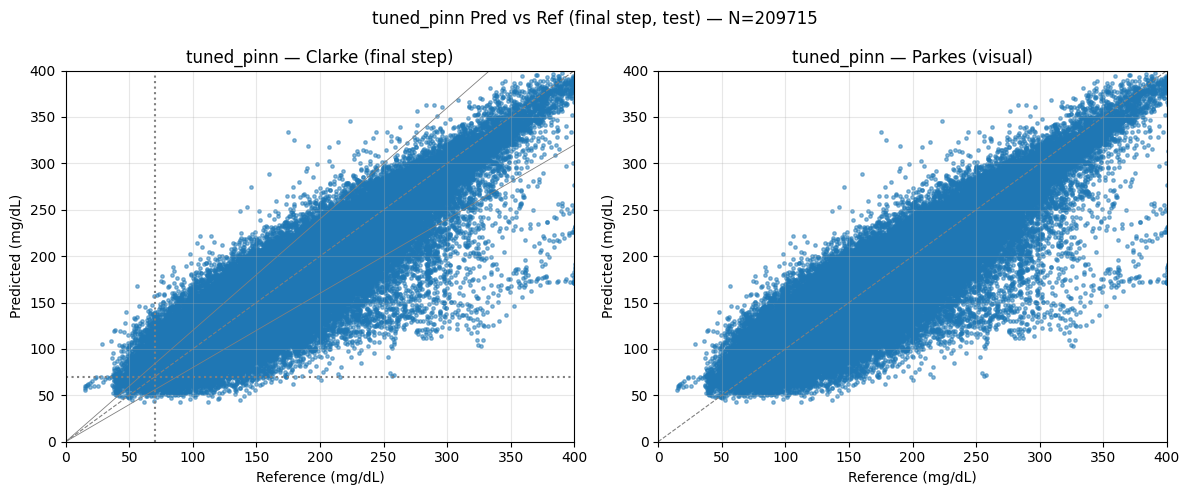


tuned_ml_corrector Clarke zones:  {'A': (130711, 62.33), 'B': (78991, 37.67), 'C': (7, 0.0), 'D': (6, 0.0)}
tuned_ml_corrector Parkes zones :  {'A': (130497, 62.23), 'B': (50843, 24.24), 'C': (20325, 9.69), 'E': (8037, 3.83), 'D': (13, 0.01)}


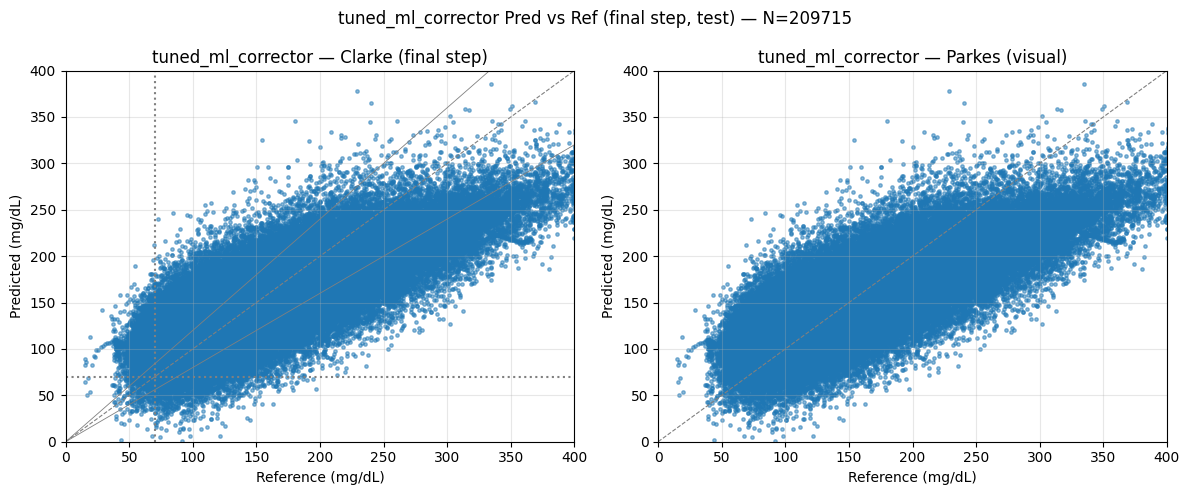


GLYCEMIA DETECTION CONFUSION MATRICES

Glycemia detection — persistence (final step):


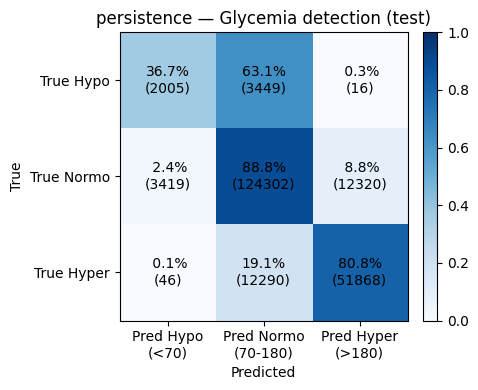


Glycemia detection — bergman (final step):


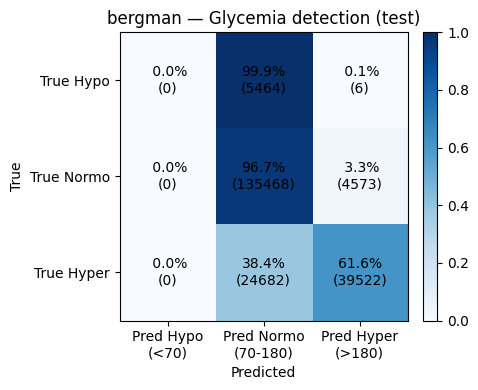


Glycemia detection — lstm (final step):


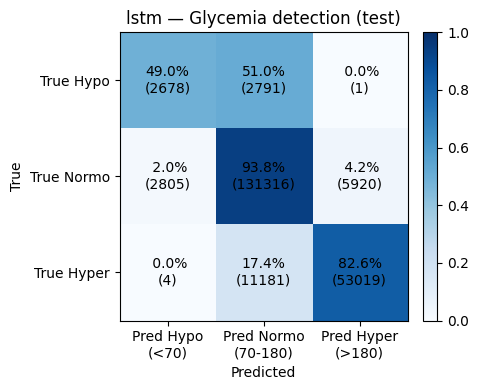


Glycemia detection — pinn (final step):


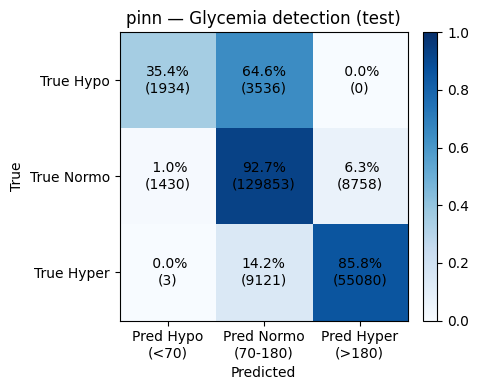


Glycemia detection — ml_corrector (final step):


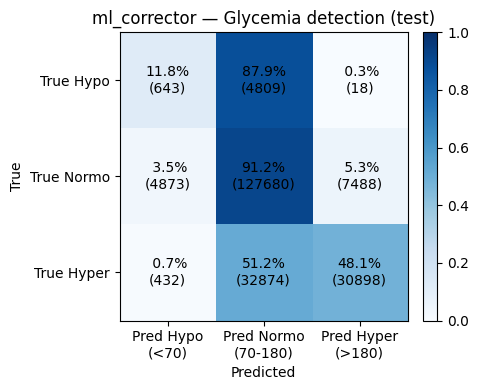


Glycemia detection — tuned_lstm (final step):


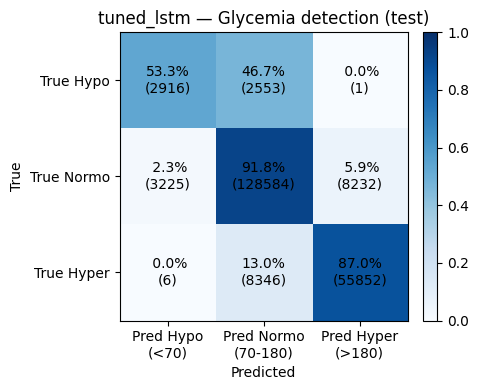


Glycemia detection — tuned_pinn (final step):


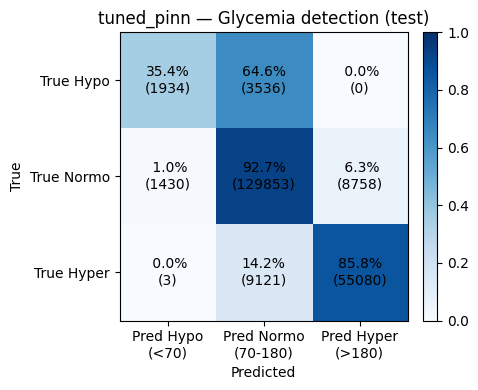


Glycemia detection — tuned_ml_corrector (final step):


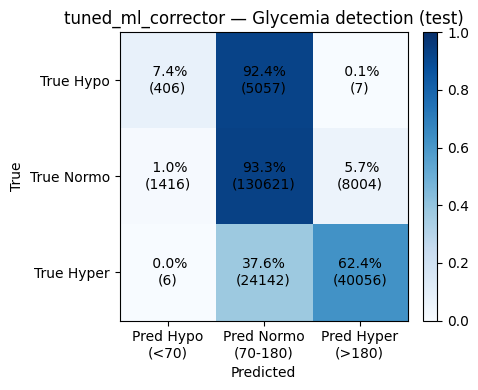


MULTI-STEP TRAJECTORY PLOTS (24 hour view)


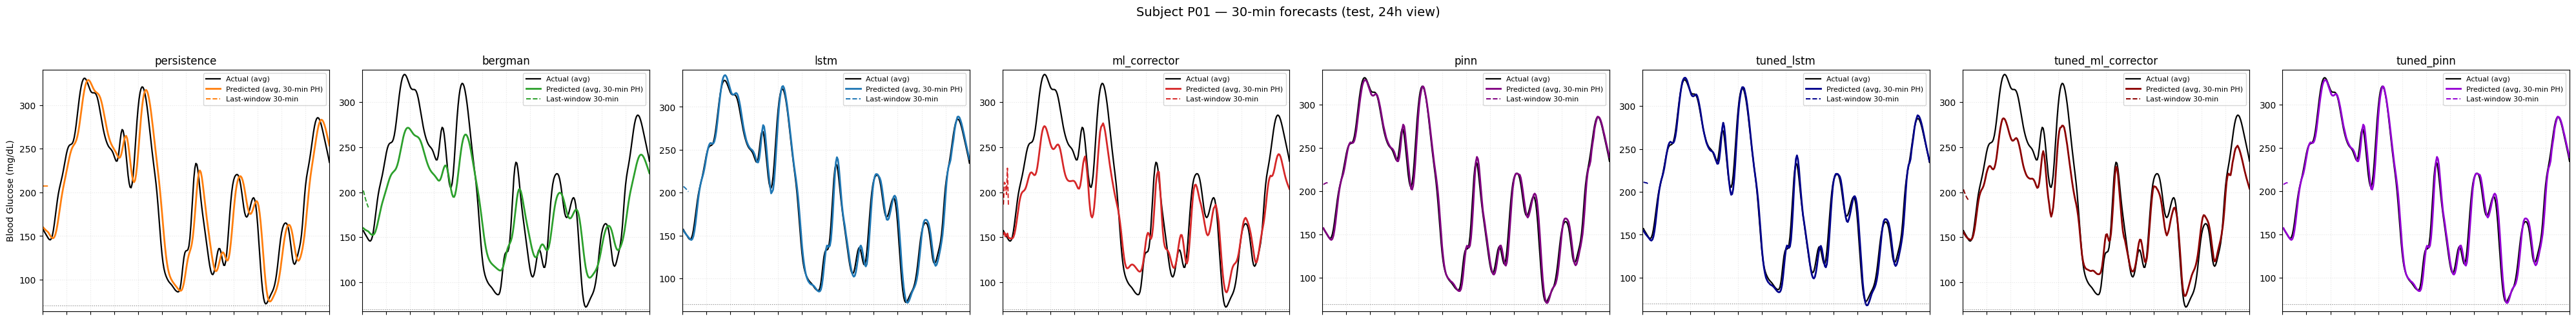

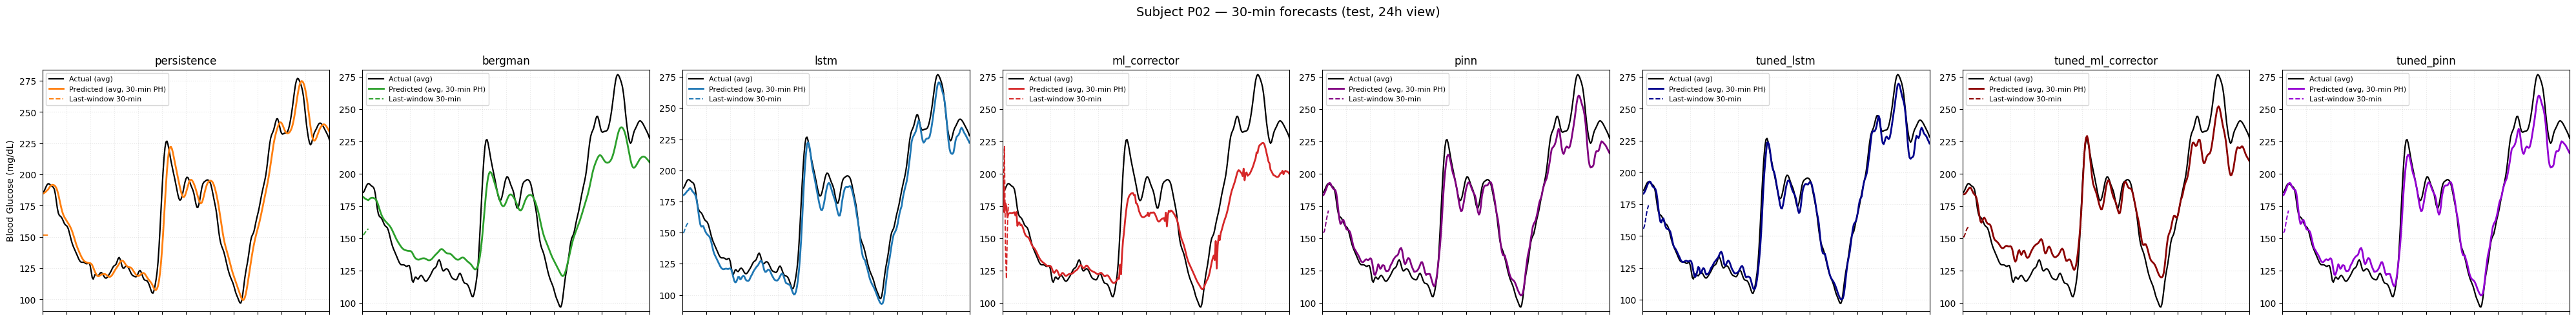

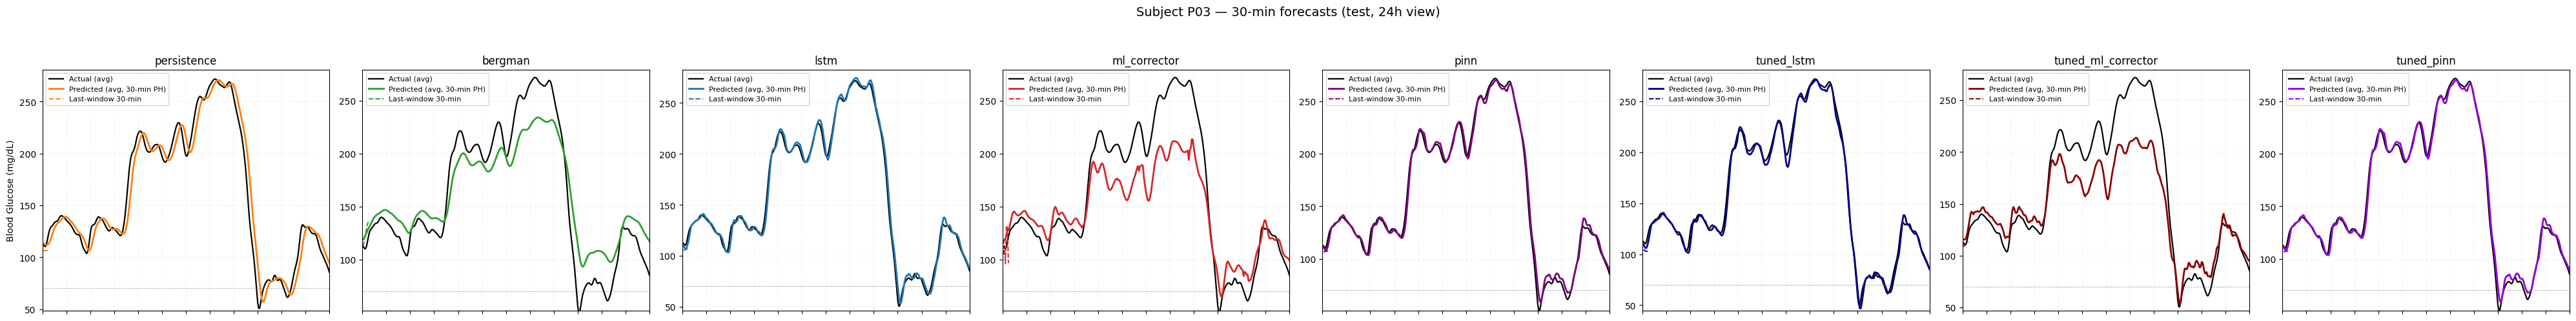


COMBINED PER-HORIZON RMSE PLOT


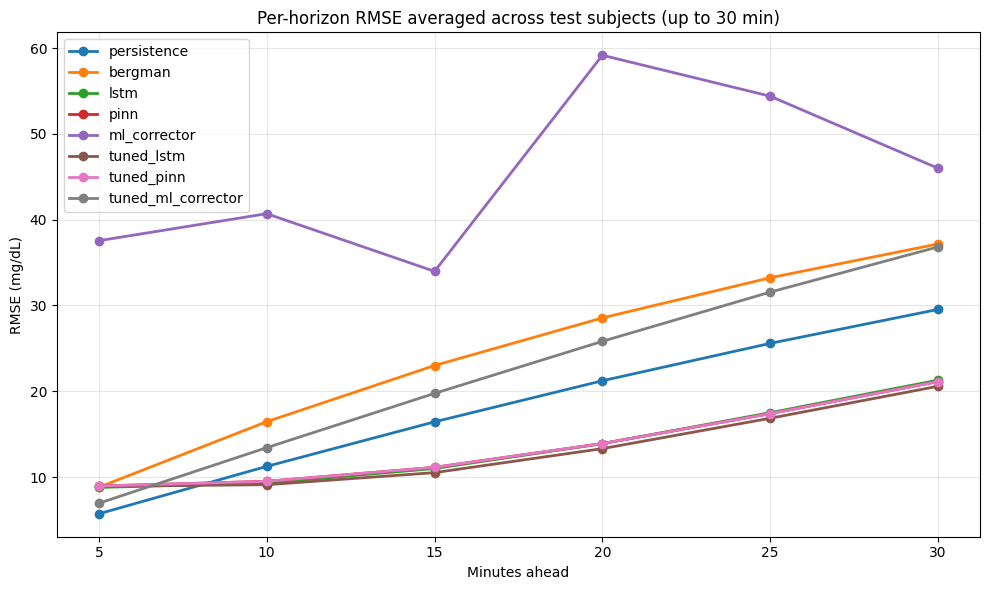


EVALUATION COMPLETE (TEST DATA)

Summary:
  ✓ Evaluated on test data from BrisT1D
  ✓ 4 test subjects
  ✓ 209715 total test windows
  ✓ Models evaluated: 8 (persistence, bergman, lstm, pinn, ml_corrector, tuned_lstm, tuned_pinn, tuned_ml_corrector)
  ✓ Prediction horizon: 30 minutes (6 steps)
  ✓ All metrics computed: RMSE, MAE, g-RMSE, g-MAE, TG, G-Mean
  ✓ Clarke & Parkes Error Grid analysis
  ✓ Glycemia detection confusion matrices
  ✓ Multi-step trajectory visualizations
  ✓ Per-horizon performance comparison

Note: Models trained on OhioT1DM, evaluated on BrisT1D (cross-dataset generalization)



In [29]:
"""
Comprehensive Model Evaluation on Test Data
Evaluates all models including tuned variants using test subjects from BrisT1D

REQUIRED VARIABLES FROM MODEL TRAINING CODES:

1. Data Processing Code ('Blood Glucose Forecasting Data Processing'):
   - test_subjects: Dict of processed test subject DataFrames (BrisT1D)
   - test_sequences: Dict with 'X' and 'y' for test subjects
   - cgm_scaler: Fitted MinMaxScaler for CGM
   - N_IN: Input sequence length (default: 12)
   - N_OUT: Output prediction horizon (default: 6)
   - bergman_params: Tuple of Bergman model parameters (p1, p2, p3, k_i, Gb)

2. LSTM Baseline Model:
   - lstm_model: Trained baseline LSTM model

3. PINN Model (Nested CV):
   - best_model: Best PINN model from cross-validation (variable name from PINN CV code)

4. ML Corrector Model:
   - lstm_corrector: Trained ML corrector model

5. Tuned LSTM Model (from Optuna):
   - tuned_lstm_model: Final tuned LSTM model

6. Tuned PINN Model (from two-phase training):
   - tuned_pinn_model: Final tuned PINN model

7. Tuned ML Corrector Model:
   - tuned_hybrid_corrector_model: Final tuned hybrid corrector model
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate
import warnings

# ============================================================================
# SETUP: Prepare test data
# ============================================================================

print("="*70)
print("PREPARING TEST DATA (BrisT1D)")
print("="*70)

# ============================================================================
# VERIFY REQUIRED VARIABLES
# ============================================================================

print("\nVerifying required variables from model training codes...")

required_vars = {
    # Data processing variables
    'test_subjects': 'Processed test subject data (BrisT1D)',
    'test_sequences': 'Test sequences (X, y)',
    'cgm_scaler': 'Fitted CGM scaler',
    'N_IN': 'Input sequence length',
    'N_OUT': 'Output prediction horizon',
    'bergman_params': 'Bergman model parameters',
    
    # Model variables
    'lstm_model': 'Baseline LSTM model',
    'best_model': 'PINN model (from nested CV)',
    'lstm_corrector': 'ML Corrector model',
    'tuned_lstm_model': 'Tuned LSTM model',
    'tuned_pinn_model': 'Tuned PINN model',
    'tuned_hybrid_corrector_model': 'Tuned ML Corrector model'
}

missing_vars = []
available_models = []

for var_name, description in required_vars.items():
    if var_name not in globals():
        missing_vars.append(f"  - {var_name}: {description}")
    else:
        print(f"  ✓ {var_name}: {description}")
        if 'model' in var_name.lower():
            available_models.append(var_name)

if missing_vars:
    print("\n" + "="*70)
    print("WARNING: Some variables are missing")
    print("="*70)
    print("\nThe following variables were not found:")
    for msg in missing_vars:
        print(msg)
    print("\nEvaluation will proceed with available models only.")
    print("Models that will be skipped due to missing variables will be noted during execution.")

print(f"\n✓ Found {len(available_models)} model variables")
print(f"Available models: {', '.join([m.replace('_model', '').replace('best', 'pinn') for m in available_models])}")

# Test subjects and sequences from BrisT1D dataset
test_subject_ids = sorted(test_subjects.keys())
print(f"\nTest subjects: {len(test_subject_ids)}")
print(f"Test sequences: {X_test.shape[0]} windows")

# ============================================================================
# HELPER FUNCTIONS (from evaluation code)
# ============================================================================

def inv_cgm_with_scaler(y_scaled):
    """Convert scaled CGM values back to mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cgm_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0
HYPER = 180.0

def glycemia_class(x):
    """Classify glucose values: 0=hypo (<70), 1=normo (70-180), 2=hyper (>180)"""
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Constrained Cross-Correlation Temporal Gain (mirrors the pasted implementation).
    
    Measures temporal synchronization by finding optimal lag within constrained range.
    Only searches for negative lags (prediction leading) or zero lag.
    
    NOTE: This has the same limitation as the original - models with good temporal
    alignment will score high regardless of actual predictive value.
    
    Args:
        y_true: Ground truth glucose values (n_windows, n_steps) or (n_samples,)
        y_pred: Predicted glucose values (n_windows, n_steps) or (n_samples,)
        prediction_horizon: Total prediction window in minutes (e.g., 30 or 60)
    
    Returns:
        Temporal gain in minutes (median across windows)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Handle 1D vs 2D input
    if y_true.ndim == 1 and y_pred.ndim == 1:
        # Single sequence - compute once
        y_true_arr = y_true.reshape(1, -1)
        y_pred_arr = y_pred.reshape(1, -1)
    elif y_true.ndim == 2 and y_pred.ndim == 2:
        # Multiple windows
        y_true_arr = y_true
        y_pred_arr = y_pred
    else:
        return int(prediction_horizon)
    
    n_windows, n_steps = y_true_arr.shape
    dt_minutes = 5  # Assuming 5-minute timesteps
    
    tg_windows = []
    
    for i in range(n_windows):
        t = y_true_arr[i].astype(float)
        p = y_pred_arr[i].astype(float)
        
        # Skip invalid windows
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            continue
        
        # Remove mean for correlation (standardization)
        t_centered = t - np.nanmean(t)
        p_centered = p - np.nanmean(p)
        
        # Compute cross-correlation
        cross_corr = correlate(t_centered, p_centered, mode='full')
        
        # Define constrained lag range
        lag_min = -prediction_horizon // dt_minutes  # e.g., -6 for PH=30
        lag_max = 0  # Only look at prediction leading or synchronized
        
        # Calculate full range of lags
        full_lags = np.arange(-len(t) + 1, len(p))
        
        # Filter valid lags within the prediction horizon
        valid_mask = (full_lags >= lag_min) & (full_lags <= lag_max)
        valid_lags = full_lags[valid_mask]
        valid_cross_corr = cross_corr[valid_mask]
        
        if len(valid_cross_corr) == 0:
            tg_windows.append(0)
            continue
        
        # Find lag with maximum correlation
        max_corr_idx = np.argmax(np.abs(valid_cross_corr))
        optimal_lag_steps = valid_lags[max_corr_idx]
        
        # Convert to temporal gain in minutes
        # If lag = 0 (synchronized), TG = prediction_horizon
        # If lag = -6 (max delay), TG = 0
        tg_minutes = prediction_horizon + (optimal_lag_steps * dt_minutes)
        tg_minutes = max(0.0, min(float(prediction_horizon), float(tg_minutes)))
        
        tg_windows.append(tg_minutes)
    
    if len(tg_windows) == 0:
        return int(prediction_horizon)
    
    return int(round(np.median(tg_windows)))

def g_mean(y_true, y_pred):
    """Geometric mean of per-class recall"""
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true)
    p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

def _sigma_ge(x, a, eps):
    """Smooth step function (C2 continuous)"""
    x = np.asarray(x, dtype=float)
    a = np.asarray(a, dtype=float)
    out = np.zeros_like(x, dtype=float)
    
    if np.asarray(eps).size == 1 and eps <= 0:
        out = (x > a).astype(float)
        return out
    
    left = x <= a
    right = x >= (a + eps)
    mid = (~left) & (~right)
    
    out[right] = 1.0
    
    if np.any(mid):
        mid_vals = x[mid]
        a_arr = np.asarray(a)
        if a_arr.shape == ():
            a_mid = a_arr
        else:
            a_b = np.broadcast_to(a_arr, x.shape)
            a_mid = a_b[mid]
        
        xi = 2.0 * (mid_vals - a_mid) / eps - 1.0
        first_half = xi <= 0
        second_half = ~first_half
        
        val = np.empty_like(xi)
        if np.any(first_half):
            xi_f = xi[first_half]
            val[first_half] = (-0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
        if np.any(second_half):
            xi_s = xi[second_half]
            val[second_half] = (0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5
        
        out[mid] = val
    
    return out

def _sigma_le_bar(x, a, eps):
    """Smooth step function (mirror of _sigma_ge)"""
    x = np.asarray(x, dtype=float)
    a = np.asarray(a, dtype=float)
    out = np.zeros_like(x, dtype=float)
    
    if np.asarray(eps).size == 1 and eps <= 0:
        out = (x <= a).astype(float)
        return out
    
    left = x <= (a - eps)
    right = x >= a
    mid = (~left) & (~right)
    
    out[left] = 1.0
    
    if np.any(mid):
        mid_vals = x[mid]
        a_arr = np.asarray(a)
        if a_arr.shape == ():
            a_mid = a_arr
        else:
            a_b = np.broadcast_to(a_arr, x.shape)
            a_mid = a_b[mid]
        
        xi = 2.0 * (mid_vals - a_mid) / eps + 1.0
        first_half = xi <= 0
        second_half = ~first_half
        
        val = np.empty_like(xi)
        if np.any(first_half):
            xi_f = xi[first_half]
            val[first_half] = (0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
        if np.any(second_half):
            xi_s = xi[second_half]
            val[second_half] = (-0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5
        
        out[mid] = val
    
    return out

def pen_function(g, ghat, alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
                 betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """Penalty function for glucose-weighted metrics"""
    g = np.asarray(g, dtype=float)
    ghat = np.asarray(ghat, dtype=float)
    
    if g.shape == () and ghat.shape != ():
        g = np.full_like(ghat, float(g))
    elif ghat.shape == () and g.shape != ():
        ghat = np.full_like(g, float(ghat))
    else:
        bshape = np.broadcast_shapes(g.shape, ghat.shape)
        g = np.broadcast_to(g, bshape).astype(float)
        ghat = np.broadcast_to(ghat, bshape).astype(float)
    
    partL = _sigma_le_bar(g, TL, betaL) * _sigma_ge(ghat, g, gammaL)
    partH = _sigma_ge(g, TH, betaH) * _sigma_le_bar(ghat, g, gammaH)
    Pen = 1.0 + alphaL * partL + alphaH * partH
    return Pen

def glucose_weighted_rmse(y_true, y_pred, alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
                          betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """Glucose-weighted RMSE"""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    
    Pen = pen_function(y_true, y_pred, alphaL, alphaH, TL, TH, betaL, betaH, gammaL, gammaH)
    gse = (y_true - y_pred)**2 * Pen
    return math.sqrt(np.mean(gse))

def glucose_weighted_mae(y_true, y_pred, alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
                         betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """Glucose-weighted MAE"""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    
    Pen = pen_function(y_true, y_pred, alphaL, alphaH, TL, TH, betaL, betaH, gammaL, gammaH)
    gabs = np.abs(y_true - y_pred) * Pen
    return float(np.mean(gabs))

def clarke_zone_for_point(ref, pred):
    """Clarke Error Grid zone classification"""
    if np.isnan(ref) or np.isnan(pred):
        return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20):
        return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330):
        return 'E'
    if ref < 70 and pred >= 180:
        return 'C'
    if ref >= 180 and pred < 70:
        return 'D'
    return 'B'

def parkes_zone_for_point(ref, pred):
    """Parkes (Consensus) Error Grid zone classification"""
    if np.isnan(ref) or np.isnan(pred):
        return None
    err = pred - ref
    rel_err = abs(err) / max(ref, 1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2):
        return 'A'
    if rel_err <= 0.35:
        return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return 'D'
    if rel_err > 0.6:
        return 'E'
    return 'C'

def compute_glycemia_confusion(y_true, y_pred):
    """Compute confusion matrix for glycemia detection"""
    y_t = np.asarray(y_true).reshape(-1)
    y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]
    y_p = y_p[mask]
    
    counts = np.zeros((3, 3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    
    tcls = glycemia_class(y_t)
    pcls = glycemia_class(y_p)
    
    for t, p in zip(tcls, pcls):
        if 0 <= t <= 2 and 0 <= p <= 2:
            counts[t, p] += 1
    
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s > 0:
            pct[i, :] = counts[i, :] / float(s)
    
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    """Plot glycemia detection confusion matrix heatmap"""
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)', 'Pred Normo\n(70-180)', 'Pred Hyper\n(>180)']
    ax.set_xticklabels(labels)
    ax.set_yticklabels(['True Hypo', 'True Normo', 'True Hyper'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    
    for i in range(3):
        for j in range(3):
            c = counts[i, j]
            p = pct[i, j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# ============================================================================
# MODEL PREDICTION FUNCTIONS FOR TEST DATA
# ============================================================================

def persistence_predict_on_test_subject(sid):
    """Persistence baseline: last observed value repeated"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    n_windows = X_subj.shape[0]
    
    # Last CGM value from input sequence (already scaled)
    last_cgm = X_subj[:, -1, 0]  # Shape: (n_windows,)
    
    # Repeat for all forecast steps
    preds_scaled = np.tile(last_cgm.reshape(-1, 1), (1, N_OUT))
    return preds_scaled.reshape(n_windows, N_OUT, 1)

def bergman_predict_on_test_subject(sid):
    """Bergman physiological model predictions"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    subj_df = test_subjects[sid]
    n_windows = X_subj.shape[0]
    
    # Initial glucose values (mg/dL) for each window
    G_inits = subj_df['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    
    # Extract insulin and carbs for forecast horizon
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat = np.zeros((n_windows, N_OUT))
    
    for w in range(n_windows):
        start_idx = N_IN + w
        bolus_mat[w, :] = subj_df['bolus'].values[start_idx:start_idx+N_OUT]
        carbs_mat[w, :] = subj_df['carbs'].values[start_idx:start_idx+N_OUT]
    
    # Bergman parameters (should be defined from bergman_params variable)
    p1, p2, p3, k_i, Gb = bergman_params
    dt_scale = 1.0  # 5min/5min scaling factor
    
    # Simulate forward
    preds_mg = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    
    for t in range(N_OUT):
        # Update insulin with decay and new dose
        I = I * np.exp(-k_i) + bolus_mat[:, t]
        
        # Meal effect
        meal_effect = p3 * carbs_mat[:, t]
        
        # Glucose dynamics
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_scale
        preds_mg[:, t] = G
    
    # Scale to [0, 1]
    preds_scaled = cgm_scaler.transform(preds_mg.reshape(-1, 1)).reshape(n_windows, N_OUT)
    return preds_scaled.reshape(n_windows, N_OUT, 1)

def lstm_predict_on_test_subject(sid):
    """LSTM model predictions"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    preds_scaled = lstm_model.predict(X_subj, batch_size=64, verbose=0)
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def pinn_predict_on_test_subject(sid):
    """Physics-Informed Neural Network predictions (non-tuned baseline)"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X'].astype(np.float32)
    # Use best_model from PINN nested CV (variable name from PINN training code)
    preds_scaled, _ = best_model(X_subj, training=False)
    preds_scaled = preds_scaled.numpy()
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def ml_corrector_predict_on_test_subject(sid):
    """Hybrid ML corrector: Bergman + learned residual"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    
    # Get residual predictions from corrector model
    resid_scaled = lstm_corrector.predict(X_subj, batch_size=128, verbose=0)
    
    # Get Bergman baseline predictions
    bergman_preds = bergman_predict_on_test_subject(sid)
    bergman_preds_scaled = bergman_preds.reshape(-1, N_OUT)
    
    # Correct Bergman with residual
    corrected_scaled = bergman_preds_scaled + resid_scaled
    return corrected_scaled.reshape(-1, N_OUT, 1)

def tuned_lstm_predict_on_test_subject(sid):
    """Tuned LSTM model predictions"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    preds_scaled = tuned_lstm_model.predict(X_subj, batch_size=64, verbose=0)
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def tuned_pinn_predict_on_test_subject(sid):
    """Tuned Physics-Informed Neural Network predictions"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X'].astype(np.float32)
    preds_scaled, _ = tuned_pinn_model(X_subj, training=False)
    preds_scaled = preds_scaled.numpy()
    
    if preds_scaled.ndim == 2:
        preds_scaled = preds_scaled.reshape(-1, N_OUT, 1)
    
    return preds_scaled

def tuned_ml_corrector_predict_on_test_subject(sid):
    """Tuned hybrid ML corrector: Bergman + learned residual"""
    info = test_sequences.get(sid)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    
    X_subj = info['X']
    
    # Get residual predictions from tuned corrector model
    resid_scaled = tuned_hybrid_corrector_model.predict(X_subj, batch_size=128, verbose=0)
    
    # Get Bergman baseline predictions
    bergman_preds = bergman_predict_on_test_subject(sid)
    bergman_preds_scaled = bergman_preds.reshape(-1, N_OUT)
    
    # Correct Bergman with residual
    corrected_scaled = bergman_preds_scaled + resid_scaled
    return corrected_scaled.reshape(-1, N_OUT, 1)

# ============================================================================
# COLLECT PREDICTIONS FROM ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING PREDICTIONS ON TEST DATA (BrisT1D)")
print("="*70)

# Define all possible models
all_models = {
    'persistence': persistence_predict_on_test_subject,
    'bergman': bergman_predict_on_test_subject,
    'lstm': lstm_predict_on_test_subject,
    'pinn': pinn_predict_on_test_subject,
    'ml_corrector': ml_corrector_predict_on_test_subject,
    'tuned_lstm': tuned_lstm_predict_on_test_subject,
    'tuned_pinn': tuned_pinn_predict_on_test_subject,
    'tuned_ml_corrector': tuned_ml_corrector_predict_on_test_subject
}

# Check which models are actually available by testing if required variables exist
models = {}
skipped_models = []

# Persistence and Bergman always available (only need data)
models['persistence'] = persistence_predict_on_test_subject
models['bergman'] = bergman_predict_on_test_subject

# Check LSTM
if 'lstm_model' in globals():
    models['lstm'] = lstm_predict_on_test_subject
else:
    skipped_models.append('lstm')

# Check PINN (uses best_model from nested CV)
if 'best_model' in globals():
    models['pinn'] = pinn_predict_on_test_subject
else:
    skipped_models.append('pinn')

# Check ML Corrector
if 'lstm_corrector' in globals():
    models['ml_corrector'] = ml_corrector_predict_on_test_subject
else:
    skipped_models.append('ml_corrector')

# Check Tuned LSTM
if 'tuned_lstm_model' in globals():
    models['tuned_lstm'] = tuned_lstm_predict_on_test_subject
else:
    skipped_models.append('tuned_lstm')

# Check Tuned PINN
if 'tuned_pinn_model' in globals():
    models['tuned_pinn'] = tuned_pinn_predict_on_test_subject
else:
    skipped_models.append('tuned_pinn')

# Check Tuned ML Corrector
if 'tuned_hybrid_corrector_model' in globals():
    models['tuned_ml_corrector'] = tuned_ml_corrector_predict_on_test_subject
else:
    skipped_models.append('tuned_ml_corrector')

print(f"\nEvaluating {len(models)} models: {', '.join(models.keys())}")
if skipped_models:
    print(f"Skipping {len(skipped_models)} models (not found): {', '.join(skipped_models)}")

# Collect predictions for all test subjects
all_results = {}
for mname, mpredict in models.items():
    print(f"\nModel: {mname}")
    Ys = []
    for sid in test_subject_ids:
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        
        yhat_mg = inv_cgm_with_scaler(yhat_scaled)
        Ys.append(yhat_mg)
        print(f"  Subject {sid}: {yhat_mg.shape[0]} windows")
    
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))
    print(f"  Total: {all_results[mname].shape[0]} windows")

# Build ground truth (all test windows)
y_true_all_windows = []
for sid in test_subject_ids:
    info = test_sequences.get(sid)
    y_test_subj = info['y']
    if y_test_subj.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_scaler(y_test_subj.reshape(-1, N_OUT))
    y_true_all_windows.append(y_true_mg)

if len(y_true_all_windows) == 0:
    raise RuntimeError("No test windows found.")

y_true_all = np.vstack(y_true_all_windows)
print(f"\nGround truth: {y_true_all.shape[0]} windows")

# ============================================================================
# EVALUATION METRICS
# ============================================================================

print("\n" + "="*70)
print("EVALUATION METRICS (TEST DATA)")
print("="*70)

# Per-horizon RMSE/MAE
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for each model ===")

per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"\nModel {mname}: no predictions")
        continue
    
    rmse_h = []
    mae_h = []
    
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v, 2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v, 2) for v in mae_h])

# Final-step aggregated metrics
print("\n=== Final-step aggregated metrics (30 min) ===")

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    
    ref = y_true_all[:, -1]
    pred = ypred_all[:, -1]
    
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae = glucose_weighted_mae(ref, pred)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    
    print(f"\nModel: {mname}")
    print(f"  Windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# ============================================================================
# CLARKE & PARKES ERROR GRIDS + SCATTER PLOTS
# ============================================================================

print("\n" + "="*70)
print("CLARKE & PARKES ERROR GRIDS")
print("="*70)

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    
    ref = y_true_all[:, -1]
    pred = ypred_all[:, -1]
    
    # Compute zones
    cz = [clarke_zone_for_point(r, p) for r, p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r, p) for r, p in zip(ref, pred)]
    
    c_counts = dict(Counter(cz))
    p_counts = dict(Counter(pz))
    total = len(ref)
    
    print(f"\n{mname} Clarke zones: ", {k: (c_counts[k], round(100*c_counts[k]/total, 2)) 
                                         for k in c_counts})
    print(f"{mname} Parkes zones : ", {k: (p_counts[k], round(100*p_counts[k]/total, 2)) 
                                        for k in p_counts})
    
    # Scatter plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Clarke grid
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0, 400], [0, 400], '--', linewidth=0.8, color='gray')
    xs = np.linspace(0, 400, 100)
    ax0.plot(xs, 1.2*xs, linewidth=0.6, color='gray')
    ax0.plot(xs, 0.8*xs, linewidth=0.6, color='gray')
    ax0.axvline(70, linestyle=':', color='gray')
    ax0.axhline(70, linestyle=':', color='gray')
    ax0.set_xlim(0, 400)
    ax0.set_ylim(0, 400)
    ax0.set_xlabel('Reference (mg/dL)')
    ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")
    ax0.grid(True, alpha=0.3)
    
    # Parkes grid
    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0, 400], [0, 400], '--', linewidth=0.8, color='gray')
    ax1.set_xlim(0, 400)
    ax1.set_ylim(0, 400)
    ax1.set_xlabel('Reference (mg/dL)')
    ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    ax1.grid(True, alpha=0.3)
    
    plt.suptitle(f"{mname} Pred vs Ref (final step, test) — N={total}")
    plt.tight_layout()
    plt.show()

# ============================================================================
# GLYCEMIA DETECTION CONFUSION MATRICES
# ============================================================================

print("\n" + "="*70)
print("GLYCEMIA DETECTION CONFUSION MATRICES")
print("="*70)

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (test)")

# ============================================================================
# MULTI-STEP TRAJECTORY PLOTS (Selected Subjects, 24h view)
# ============================================================================

print("\n" + "="*70)
print("MULTI-STEP TRAJECTORY PLOTS (24 hour view)")
print("="*70)

dt = 5  # minutes
prediction_horizon_min = 30  # minutes (matches validation: N_OUT * 5 = 6 * 5 = 30)
ph_steps = int(prediction_horizon_min // dt)
total_minutes = 24 * 60
time_bins = np.arange(dt, total_minutes + dt, dt)
nbins = len(time_bins)

model_order = ['persistence', 'bergman', 'lstm', 'ml_corrector', 'pinn', 
               'tuned_lstm', 'tuned_ml_corrector', 'tuned_pinn']
color_map = {
    'persistence': 'tab:orange',
    'bergman': 'tab:green',
    'lstm': 'tab:blue',
    'ml_corrector': 'tab:red',
    'pinn': 'purple',
    'tuned_lstm': 'darkblue',
    'tuned_ml_corrector': 'darkred',
    'tuned_pinn': 'darkviolet'
}

selected_sids = test_subject_ids[:min(3, len(test_subject_ids))]  # First 3 test subjects

for sid in selected_sids:
    info = test_sequences.get(sid)
    if info is None:
        continue
    
    y_test_subj = info['y']
    if y_test_subj.shape[0] == 0:
        continue
    
    y_test_arr = np.asarray(y_test_subj)
    if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
        y_test_flat = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
    else:
        y_test_flat = y_test_arr.copy()
    
    if y_test_flat.shape[1] < ph_steps:
        continue
    
    y_test_mg = inv_cgm_with_scaler(y_test_flat[:, :ph_steps])
    
    n_models = len(model_order)
    fig, axs = plt.subplots(2, n_models, figsize=(5*n_models, 9), sharex=True)
    if n_models == 1:
        axs = axs.reshape(2, 1)
    
    fig.suptitle(f"Subject {sid} — {prediction_horizon_min}-min forecasts (test, 24h view)", fontsize=14)
    
    for i_m, mname in enumerate(model_order):
        ax_top = axs[0, i_m]
        ax_bot = axs[1, i_m]
        
        if mname not in models:
            ax_top.text(0.5, 0.5, f"model '{mname}' not found", ha='center', va='center')
            ax_top.set_title(mname)
            ax_bot.set_visible(False)
            continue
        
        yhat_scaled_all = models[mname](sid)
        yhat_scaled_all = np.asarray(yhat_scaled_all)
        
        if yhat_scaled_all.size == 0:
            ax_top.text(0.5, 0.5, "no preds", ha='center', va='center')
            ax_top.set_title(mname)
            ax_bot.set_visible(False)
            continue
        
        if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
            yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], 
                                                       yhat_scaled_all.shape[1])
        
        if yhat_scaled_all.shape[1] < ph_steps:
            continue
        
        yhat_mg_all = inv_cgm_with_scaler(yhat_scaled_all[:, :ph_steps])
        n_windows = yhat_mg_all.shape[0]
        
        # Compute predicted times for each window
        win_idx = np.arange(n_windows).reshape(-1, 1)
        step_idx = np.arange(1, ph_steps+1).reshape(1, -1)
        pred_times = (win_idx * dt) + (step_idx * dt)
        
        pred_times_flat = pred_times.ravel().astype(int)
        preds_flat = yhat_mg_all.ravel()
        actuals_flat = y_test_mg.ravel()
        
        valid_mask = (pred_times_flat >= dt) & (pred_times_flat <= total_minutes)
        bin_idx = (pred_times_flat // dt) - 1
        
        agg_pred = np.full(nbins, np.nan)
        agg_actual = np.full(nbins, np.nan)
        agg_rmse = np.full(nbins, np.nan)
        agg_counts = np.zeros(nbins, dtype=int)
        
        for b in range(nbins):
            idxs = np.where((bin_idx == b) & valid_mask)[0]
            c = idxs.size
            agg_counts[b] = c
            if c > 0:
                vals_pred = preds_flat[idxs].astype(float)
                vals_act = actuals_flat[idxs].astype(float)
                agg_pred[b] = np.nanmean(vals_pred)
                agg_actual[b] = np.nanmean(vals_act)
                agg_rmse[b] = np.sqrt(np.nanmean((vals_pred - vals_act)**2))
        
        # Interpolate NaN gaps
        def interp_nan(arr):
            arr = arr.astype(float)
            mask = ~np.isnan(arr)
            if mask.sum() == 0:
                return arr
            first, last = np.where(mask)[0][0], np.where(mask)[0][-1]
            x = np.arange(first, last+1)
            y = arr[first:last+1]
            valid = ~np.isnan(y)
            if valid.sum() <= 1:
                return arr
            xi = np.arange(first, last+1)
            arr[first:last+1] = np.interp(xi, x[valid], y[valid])
            return arr
        
        agg_pred_f = interp_nan(agg_pred)
        agg_actual_f = interp_nan(agg_actual)
        
        t_minutes = time_bins
        t_hours = t_minutes / 60.0
        color = color_map.get(mname, 'gray')
        
        # TOP: Continuous trajectories
        if np.all(np.isnan(agg_actual_f)) and np.all(np.isnan(agg_pred_f)):
            ax_top.text(0.5, 0.5, "no data in 24h window", ha='center', va='center')
        else:
            ax_top.plot(t_hours, agg_actual_f, '-', color='black', linewidth=1.6, 
                       label='Actual (avg)')
            ax_top.plot(t_hours, agg_pred_f, '-', color=color, linewidth=2.0, 
                       label=f'Predicted (avg, {prediction_horizon_min}-min PH)')
            
            # Overlay last window's short-term forecast
            last_pred = yhat_mg_all[-1, :ph_steps]
            last_times = (np.arange(1, ph_steps+1) * dt) / 60.0
            ax_top.plot(last_times, last_pred, '--', color=color, linewidth=1.4, 
                       label=f'Last-window {prediction_horizon_min}-min')
        
        ax_top.set_title(mname)
        if i_m == 0:
            ax_top.set_ylabel('Blood Glucose (mg/dL)')
        
        ax_top.set_xlim(0, total_minutes/60.0)
        xticks = np.arange(0, (total_minutes/60.0) + 0.1, 2)
        ax_top.set_xticks(xticks)
        
        if HYPO is not None:
            ax_top.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
        
        all_vals = np.concatenate([
            agg_actual_f[~np.isnan(agg_actual_f)] if agg_actual_f is not None else np.array([]),
            agg_pred_f[~np.isnan(agg_pred_f)] if agg_pred_f is not None else np.array([])
        ])
        
        if all_vals.size > 0:
            lo, hi = np.nanpercentile(all_vals, [1, 99])
            pad = max(10, 0.05 * (hi - lo))
            ax_top.set_ylim(max(30, lo - pad), min(400, hi + pad))
        else:
            ax_top.set_ylim(40, 300)
        
        ax_top.grid(True, linestyle=':', alpha=0.3)
        ax_top.legend(fontsize=8)
        
        # BOTTOM: Just xlabel for consistency
        ax_bot.set_xlabel('Hours (since window start)')
        ax_bot.set_xlim(0, total_minutes/60.0)
        ax_bot.set_xticks(xticks)
        ax_bot.set_visible(False)  # Hide bottom panel for cleaner display
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ============================================================================
# COMBINED PER-HORIZON RMSE PLOT
# ============================================================================

print("\n" + "="*70)
print("COMBINED PER-HORIZON RMSE PLOT")
print("="*70)

model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}

for sid in test_subject_ids:
    info = test_sequences.get(sid)
    if info is None:
        continue
    
    y_test_subj = info['y']
    if y_test_subj.shape[0] == 0:
        continue
    
    y_true_mg_full = inv_cgm_with_scaler(y_test_subj.reshape(-1, N_OUT))
    
    if y_true_mg_full.shape[1] < ph_steps:
        continue
    
    y_true_mg = y_true_mg_full[:, :ph_steps]
    
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        
        if yhat_scaled.shape[1] < ph_steps:
            continue
        
        yhat_mg = inv_cgm_with_scaler(yhat_scaled)[:, :ph_steps]
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:, h], yhat_mg[:, h])) 
                      for h in range(ph_steps)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(10, 6))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m]) > 0 else np.zeros((0, ph_steps))
    if subj_rmses.size == 0:
        continue
    
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(np.arange(1, ph_steps+1)*5, mean_rmse, '-o', label=m, linewidth=2)

plt.xticks(np.arange(1, ph_steps+1)*5)
plt.xlabel('Minutes ahead')
plt.ylabel('RMSE (mg/dL)')
plt.title(f'Per-horizon RMSE averaged across test subjects (up to {prediction_horizon_min} min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("EVALUATION COMPLETE (TEST DATA)")
print("="*70)
print(f"""
Summary:
  ✓ Evaluated on test data from BrisT1D
  ✓ {len(test_subject_ids)} test subjects
  ✓ {y_true_all.shape[0]} total test windows
  ✓ Models evaluated: {len(models)} ({', '.join(models.keys())})
  ✓ Prediction horizon: {prediction_horizon_min} minutes ({ph_steps} steps)
  ✓ All metrics computed: RMSE, MAE, g-RMSE, g-MAE, TG, G-Mean
  ✓ Clarke & Parkes Error Grid analysis
  ✓ Glycemia detection confusion matrices
  ✓ Multi-step trajectory visualizations
  ✓ Per-horizon performance comparison
  
Note: Models trained on OhioT1DM, evaluated on BrisT1D (cross-dataset generalization)
""")

## Compound Score:


COMPOUND SCORE CALCULATION

Prediction horizon: 30 minutes
Number of output steps (N_OUT): 6

Computing compound score metrics for 8 models...
  ✓ persistence: RMSE=29.89, TG=5min, G-Mean=0.6406
  ✓ bergman: RMSE=37.62, TG=30min, G-Mean=0.0004
  ✓ lstm: RMSE=22.29, TG=30min, G-Mean=0.7237
  ✓ pinn: RMSE=22.09, TG=30min, G-Mean=0.6552
  ✓ ml_corrector: RMSE=45.41, TG=30min, G-Mean=0.3722
  ✓ tuned_lstm: RMSE=21.39, TG=30min, G-Mean=0.7523
  ✓ tuned_pinn: RMSE=22.09, TG=30min, G-Mean=0.6552
  ✓ tuned_ml_corrector: RMSE=36.21, TG=30min, G-Mean=0.3509

COMPUTING COMPOUND SCORES

Component scaling summary:
  RMSE range: [21.39, 45.41] mg/dL
  Scaled RMSE range: [0.471, 1.000]
  TG range: [5, 30] minutes
  Scaled TG penalty range: [0.000, 0.833]
  G-Mean range: [0.0004, 0.7523]
  Scaled G-Mean penalty range: [0.248, 1.000]

MODEL PERFORMANCE SUMMARY

Final-step metrics (prediction horizon: 30 minutes):

Model                         RMSE  TG(min)   G-Mean       ME   Compound
---------------

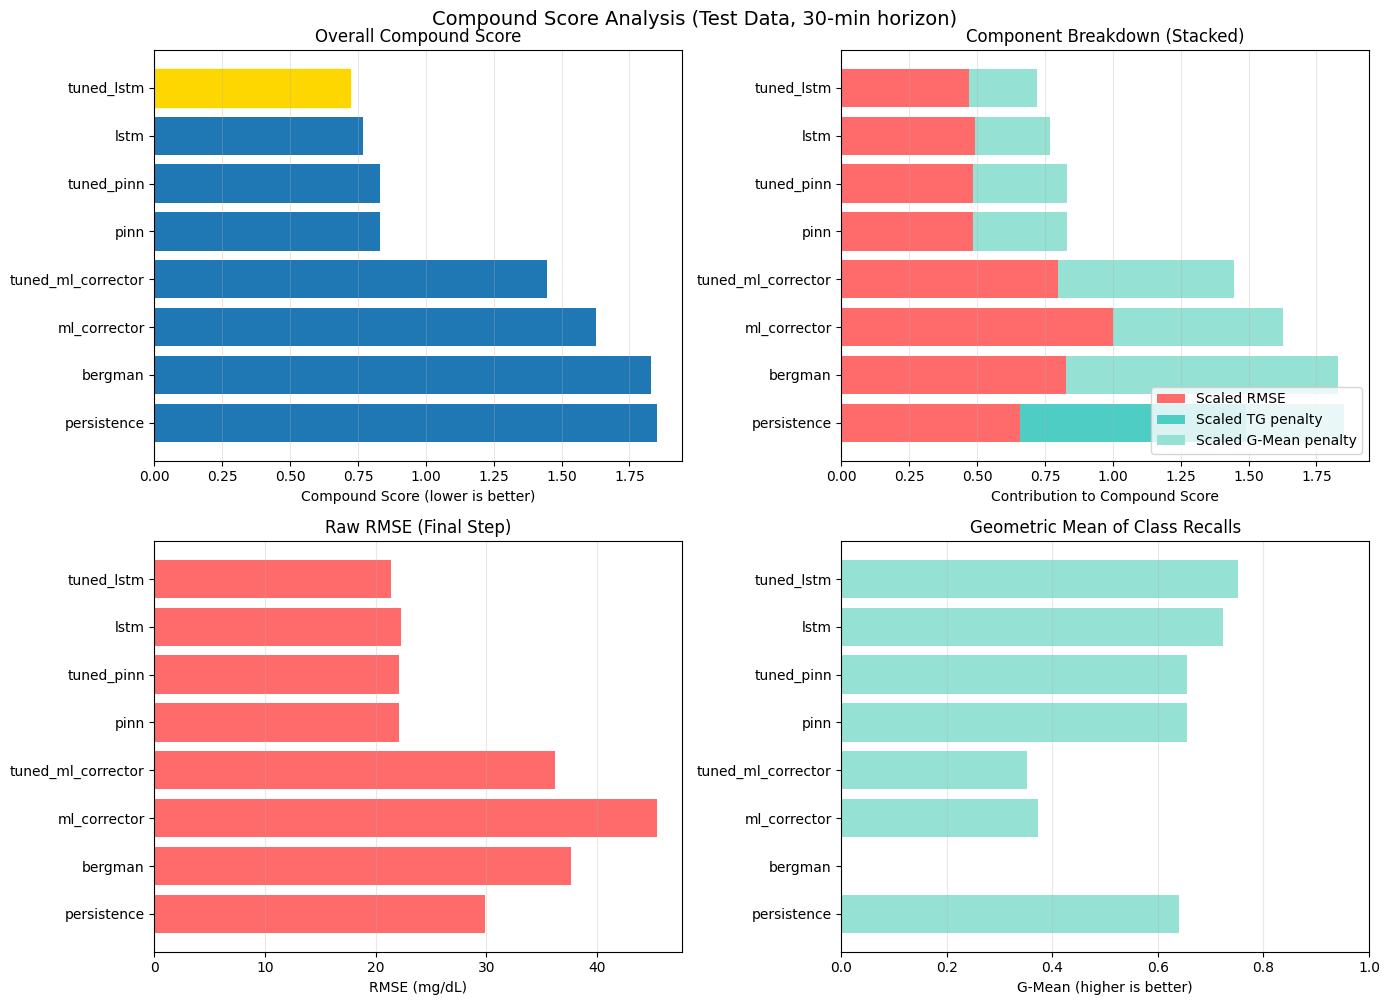


SUMMARY STATISTICS

Best performing model: tuned_lstm
  - Compound Score: 0.7188
  - RMSE: 21.39 mg/dL
  - Temporal Gain: 30 minutes
  - G-Mean: 0.7523
  - Mean Error: -0.78 mg/dL

Worst performing model: persistence
  - Compound Score: 1.8511

Score range: [0.7188, 1.8511]
Score spread: 1.1324

Interpretation:
  - Compound score combines three key aspects:
    1. Prediction accuracy (RMSE)
    2. Temporal synchronization (Temporal Gain)
    3. Glycemic zone classification (G-Mean)
  - Lower compound scores indicate better overall performance
  - Equal weighting of all three components


COMPOUND SCORE CALCULATION COMPLETE


In [30]:
# ============================================================================
# COMPOUND SCORE CALCULATION AND MODEL RANKING
# Run this cell after the comprehensive evaluation code
# ============================================================================

print("\n" + "="*70)
print("COMPOUND SCORE CALCULATION")
print("="*70)

# Use prediction horizon from evaluation code (should be 45 minutes from N_OUT * 5)
if 'prediction_horizon_min' in locals() or 'prediction_horizon_min' in globals():
    prediction_horizon = prediction_horizon_min
else:
    prediction_horizon = N_OUT * 5  # fallback to 30 minutes

print(f"\nPrediction horizon: {prediction_horizon} minutes")
print(f"Number of output steps (N_OUT): {N_OUT}")

# ============================================================================
# HELPER FUNCTION: Scale error for normalization
# ============================================================================

def scale_error(metric_results, use_mg_dl=False):
    """
    Normalize metric values to [0, 1] range based on maximum absolute value.
    
    Args:
        metric_results: Array of metric values to scale
        use_mg_dl: If True, use 18 mg/dL as lower bound, else use 1
    
    Returns:
        Scaled array where values are normalized by max absolute value
    """
    metric_results = np.asarray(metric_results)
    lower_bound = 18 if use_mg_dl else 1
    max_abs = max(np.max(np.abs(metric_results)), lower_bound)
    return np.array([np.abs(val) / max_abs for val in metric_results])

# ============================================================================
# COMPUTE METRICS FOR COMPOUND SCORE
# ============================================================================

models_list = list(all_results.keys())
n_models = len(models_list)

print(f"\nComputing compound score metrics for {n_models} models...")

# Initialize metric lists
rmse_list = []
tg_list = []
gmean_list = []
me_list = []  # mean error (bias)

for model_name in models_list:
    ypred = np.asarray(all_results[model_name])  # Shape: (n_windows, N_OUT)
    
    if ypred.size == 0:
        print(f"  ⚠ {model_name}: No predictions, using worst-case values")
        rmse_list.append(np.nan)
        tg_list.append(prediction_horizon)  # worst-case lag
        gmean_list.append(0.0)  # worst-case g-mean
        me_list.append(np.nan)
        continue
    
    # 1. Final-step RMSE
    final_rmse = np.sqrt(mean_squared_error(y_true_all[:, -1], ypred[:, -1]))
    rmse_list.append(final_rmse)
    
    # 2. Temporal gain measured across multi-step windows
    tg_val = temporal_gain(y_true_all, ypred, prediction_horizon=prediction_horizon)
    tg_list.append(tg_val)
    
    # 3. G-mean computed on final step
    gm = g_mean(y_true_all[:, -1], ypred[:, -1])
    gmean_list.append(gm)
    
    # 4. Mean error (bias) on final step
    me = np.nanmean(ypred[:, -1] - y_true_all[:, -1])
    me_list.append(me)
    
    print(f"  ✓ {model_name}: RMSE={final_rmse:.2f}, TG={tg_val}min, G-Mean={gm:.4f}")

# ============================================================================
# COMPUTE COMPOUND SCORES
# ============================================================================

print("\n" + "="*70)
print("COMPUTING COMPOUND SCORES")
print("="*70)

# Convert to numpy arrays
rmse_array = np.array(rmse_list)
tg_array = np.array(tg_list)
gmean_array = np.array(gmean_list)

# Scale each component
# 1. Scaled RMSE: normalize by maximum RMSE
scaled_rmse = scale_error(rmse_array, use_mg_dl=False)

# 2. Scaled temporal gain: convert to penalty (0 = worst, 1 = best)
#    TG ranges from 0 (max lag) to prediction_horizon (perfect sync)
#    Penalty = (prediction_horizon - TG) / prediction_horizon
#    So: TG=0 -> penalty=1 (worst), TG=PH -> penalty=0 (best)
scaled_tg = np.array([(prediction_horizon - val) / float(prediction_horizon) 
                      for val in tg_array])

# 3. Scaled g-mean: convert to penalty (0 = best, 1 = worst)
#    G-mean ranges from 0 (worst) to 1 (perfect)
#    Penalty = 1 - g_mean
scaled_gmean = np.array([1.0 - float(val) for val in gmean_array])

# Compute compound score (lower is better)
# Compound = scaled_RMSE + scaled_TG_penalty + scaled_gmean_penalty
compound_scores = scaled_rmse + scaled_tg + scaled_gmean

print("\nComponent scaling summary:")
print(f"  RMSE range: [{np.nanmin(rmse_array):.2f}, {np.nanmax(rmse_array):.2f}] mg/dL")
print(f"  Scaled RMSE range: [{np.nanmin(scaled_rmse):.3f}, {np.nanmax(scaled_rmse):.3f}]")
print(f"  TG range: [{np.nanmin(tg_array):.0f}, {np.nanmax(tg_array):.0f}] minutes")
print(f"  Scaled TG penalty range: [{np.nanmin(scaled_tg):.3f}, {np.nanmax(scaled_tg):.3f}]")
print(f"  G-Mean range: [{np.nanmin(gmean_array):.4f}, {np.nanmax(gmean_array):.4f}]")
print(f"  Scaled G-Mean penalty range: [{np.nanmin(scaled_gmean):.3f}, {np.nanmax(scaled_gmean):.3f}]")

# ============================================================================
# DISPLAY RESULTS
# ============================================================================

print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)

print(f"\nFinal-step metrics (prediction horizon: {prediction_horizon} minutes):\n")
print(f"{'Model':<25} {'RMSE':>8} {'TG(min)':>8} {'G-Mean':>8} {'ME':>8} {'Compound':>10}")
print("-" * 80)

for i, model_name in enumerate(models_list):
    print(f"{model_name:<25} {rmse_list[i]:>8.2f} {tg_list[i]:>8.0f} "
          f"{gmean_list[i]:>8.4f} {me_list[i]:>8.2f} {compound_scores[i]:>10.4f}")

# ============================================================================
# RANK MODELS BY COMPOUND SCORE
# ============================================================================

print("\n" + "="*70)
print("MODEL RANKING BY COMPOUND SCORE")
print("="*70)
print("(Lower compound score is better)\n")

# Sort by compound score (ascending - lower is better)
rank_indices = np.argsort(compound_scores)

print(f"{'Rank':<6} {'Model':<25} {'Compound Score':>15} {'Components':>40}")
print("-" * 90)

for rank, idx in enumerate(rank_indices, 1):
    model_name = models_list[idx]
    score = compound_scores[idx]
    components = f"RMSE:{scaled_rmse[idx]:.3f} + TG:{scaled_tg[idx]:.3f} + GM:{scaled_gmean[idx]:.3f}"
    
    # Add medal emoji for top 3
    medal = ""
    if rank == 1:
        medal = "🥇 "
    elif rank == 2:
        medal = "🥈 "
    elif rank == 3:
        medal = "🥉 "
    
    print(f"{medal}{rank:<4} {model_name:<25} {score:>15.4f} {components:>40}")

# ============================================================================
# VISUALIZATION: COMPONENT BREAKDOWN
# ============================================================================

print("\n" + "="*70)
print("GENERATING COMPONENT BREAKDOWN VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sort models by compound score for consistent ordering
sorted_models = [models_list[i] for i in rank_indices]
sorted_compound = compound_scores[rank_indices]
sorted_rmse_scaled = scaled_rmse[rank_indices]
sorted_tg_scaled = scaled_tg[rank_indices]
sorted_gmean_scaled = scaled_gmean[rank_indices]

# 1. Compound scores
ax1 = axes[0, 0]
bars = ax1.barh(sorted_models, sorted_compound)
bars[0].set_color('gold')  # Highlight best model
ax1.set_xlabel('Compound Score (lower is better)')
ax1.set_title('Overall Compound Score')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Stacked component breakdown
ax2 = axes[0, 1]
width = 0.8
ax2.barh(sorted_models, sorted_rmse_scaled, width, label='Scaled RMSE', color='#ff6b6b')
ax2.barh(sorted_models, sorted_tg_scaled, width, left=sorted_rmse_scaled, 
         label='Scaled TG penalty', color='#4ecdc4')
ax2.barh(sorted_models, sorted_gmean_scaled, width, 
         left=sorted_rmse_scaled + sorted_tg_scaled, 
         label='Scaled G-Mean penalty', color='#95e1d3')
ax2.set_xlabel('Contribution to Compound Score')
ax2.set_title('Component Breakdown (Stacked)')
ax2.invert_yaxis()
ax2.legend(loc='lower right')
ax2.grid(axis='x', alpha=0.3)

# 3. Raw RMSE comparison
ax3 = axes[1, 0]
sorted_rmse_raw = [rmse_list[i] for i in rank_indices]
ax3.barh(sorted_models, sorted_rmse_raw, color='#ff6b6b')
ax3.set_xlabel('RMSE (mg/dL)')
ax3.set_title('Raw RMSE (Final Step)')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. G-Mean comparison
ax4 = axes[1, 1]
sorted_gmean_raw = [gmean_list[i] for i in rank_indices]
ax4.barh(sorted_models, sorted_gmean_raw, color='#95e1d3')
ax4.set_xlabel('G-Mean (higher is better)')
ax4.set_title('Geometric Mean of Class Recalls')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)
ax4.set_xlim(0, 1)

plt.tight_layout()
plt.suptitle(f'Compound Score Analysis (Test Data, {prediction_horizon}-min horizon)', 
             fontsize=14, y=1.00)
plt.subplots_adjust(top=0.96)
plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

best_idx = rank_indices[0]
best_model = models_list[best_idx]

print(f"""
Best performing model: {best_model}
  - Compound Score: {compound_scores[best_idx]:.4f}
  - RMSE: {rmse_list[best_idx]:.2f} mg/dL
  - Temporal Gain: {tg_list[best_idx]:.0f} minutes
  - G-Mean: {gmean_list[best_idx]:.4f}
  - Mean Error: {me_list[best_idx]:.2f} mg/dL

Worst performing model: {models_list[rank_indices[-1]]}
  - Compound Score: {compound_scores[rank_indices[-1]]:.4f}

Score range: [{np.nanmin(compound_scores):.4f}, {np.nanmax(compound_scores):.4f}]
Score spread: {np.nanmax(compound_scores) - np.nanmin(compound_scores):.4f}

Interpretation:
  - Compound score combines three key aspects:
    1. Prediction accuracy (RMSE)
    2. Temporal synchronization (Temporal Gain)
    3. Glycemic zone classification (G-Mean)
  - Lower compound scores indicate better overall performance
  - Equal weighting of all three components
""")

print("\n" + "="*70)
print("COMPOUND SCORE CALCULATION COMPLETE")
print("="*70)

## Feature Importance - SHAP Analysis (Only For machine learning based models):

SHAP ANALYSIS - MODIFIED FOR BERGMAN_PARAMS

STEP 1: CHECKING AVAILABILITY
✓ lstm_model found
✓ best_model (PINN) found
✓ lstm_corrector found
✓ bergman_params found (will simulate inline)
✓ tuned_lstm_model found
✓ tuned_pinn_model found
✓ tuned_hybrid_corrector_model found
✓ bergman_params found (will simulate inline)

Checking data variables:
✓ X_train found
✓ X_val found
✓ cgm_scaler found
✓ N_OUT found
✓ N_IN found

✓ Will analyze 6 model(s): lstm, pinn, ml_corrector, tuned_lstm, tuned_pinn, tuned_ml_corrector

STEP 2: PREPARING DATA
Background data shape: (3, 12, 6)
Explain data shape: (5, 12, 6)
Timesteps: 12, Features: 6

STEP 3: CREATING SAFE COPIES
⚠ LSTM could not be cloned (using original): Could not locate class 'Function'. Make sure custo
⚠ PINN could not be cloned (using original): 
Object PINNModel was created by passing
non-seria
⚠ ML Corrector (LSTM) could not be cloned (using original): Could not locate class 'Function'. Make sure custo
✓ ML Corrector prepared (will 

  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=1.915e-02, with an active set of 1 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=8.545e-03, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping

SHAP values shape: (5, 12, 6)
✓ SHAP analysis complete for Vanilla LSTM

Analyzing PINN
Initializing KernelExplainer...
Computing SHAP values...


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.629e-02, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=7.292e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping

SHAP values shape: (5, 12, 6)
✓ SHAP analysis complete for PINN

Analyzing ML Corrector (Hybrid)
Initializing KernelExplainer...
Computing SHAP values...


...

SHAP values shape: (5, 12, 6)
✓ SHAP analysis complete for Tuned LSTM

Analyzing Tuned PINN
Initializing KernelExplainer...
Computing SHAP values...


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.163e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.163e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 5.162e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping

SHAP values shape: (5, 12, 6)
✓ SHAP analysis complete for Tuned PINN

Analyzing Tuned ML Corrector
Initializing KernelExplainer...
Computing SHAP values...


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=5.989e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=5.989e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 7.300e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping

SHAP values shape: (5, 12, 6)
✓ SHAP analysis complete for Tuned ML Corrector

✓ SUCCESSFULLY ANALYZED 6 MODEL(S)


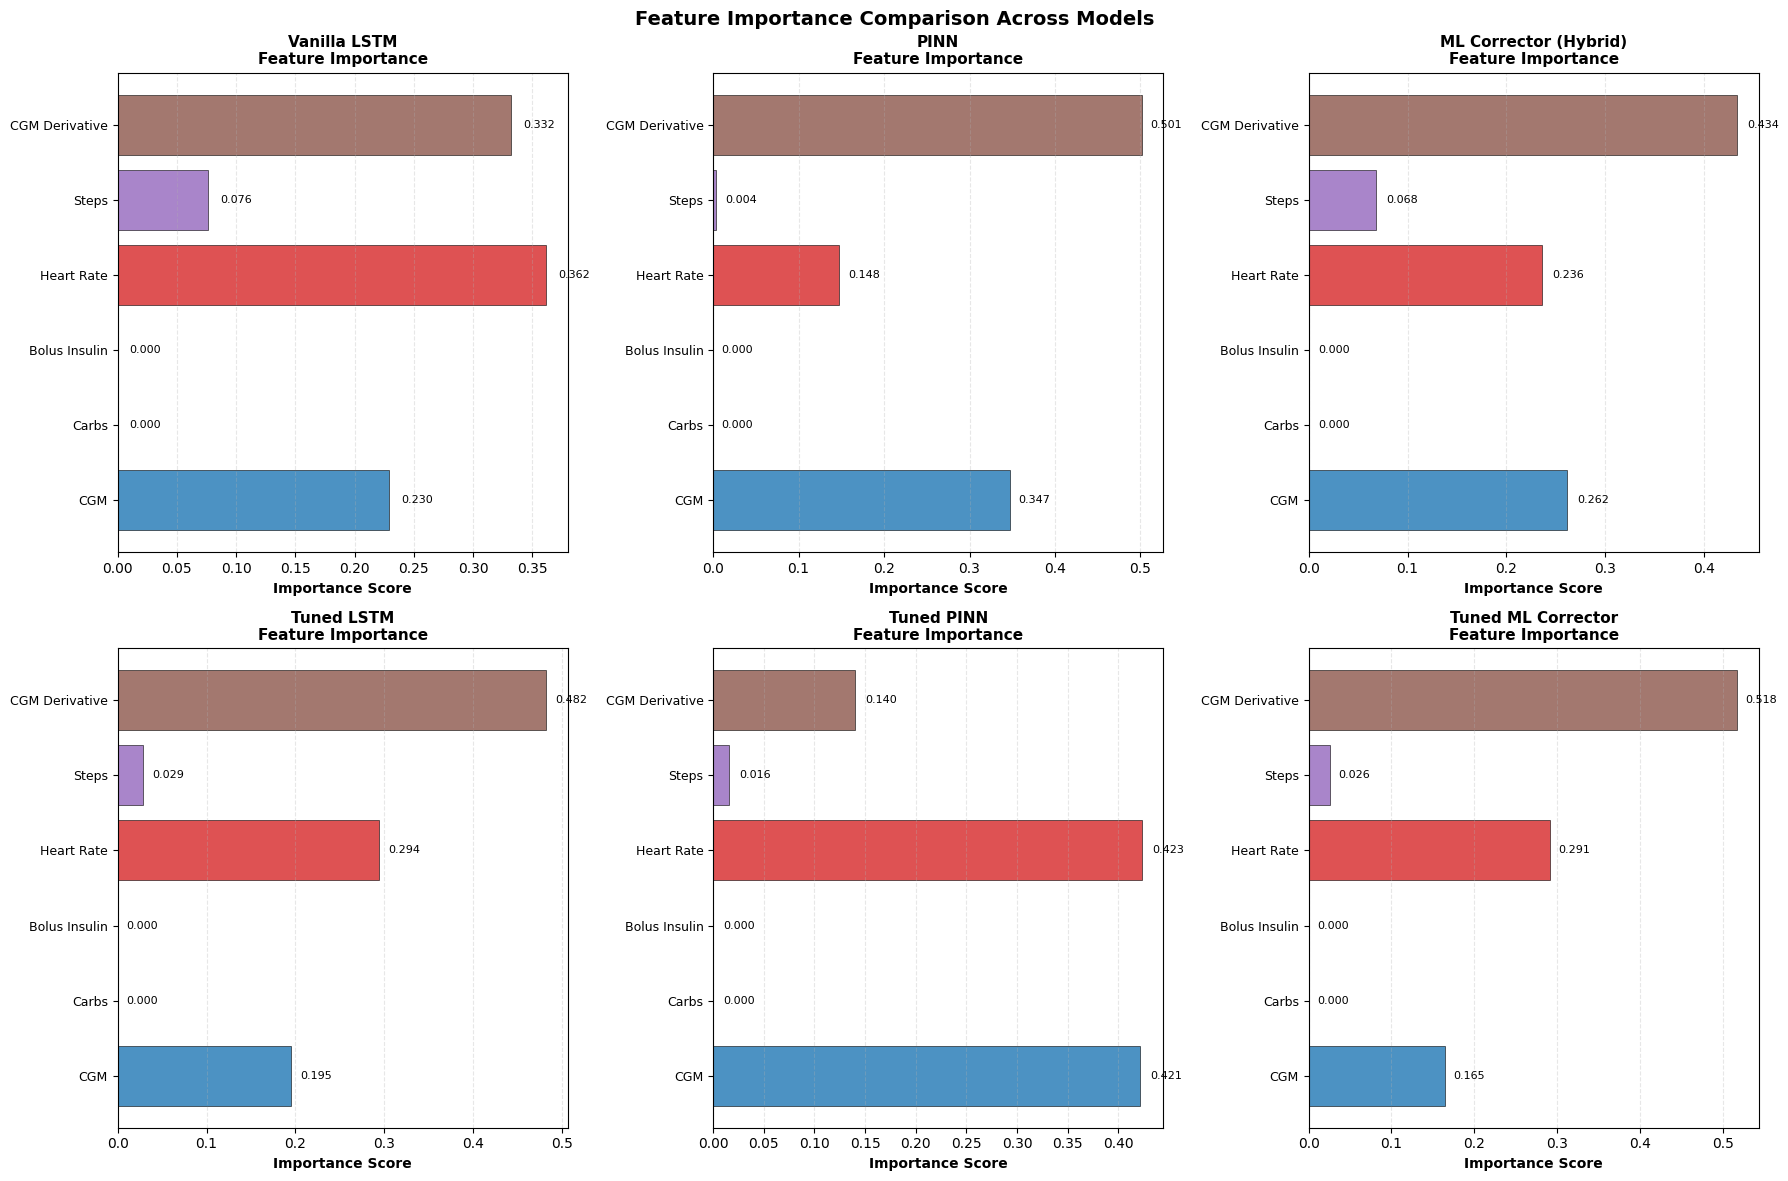

✓ Saved: shap_all_models_comparison.png


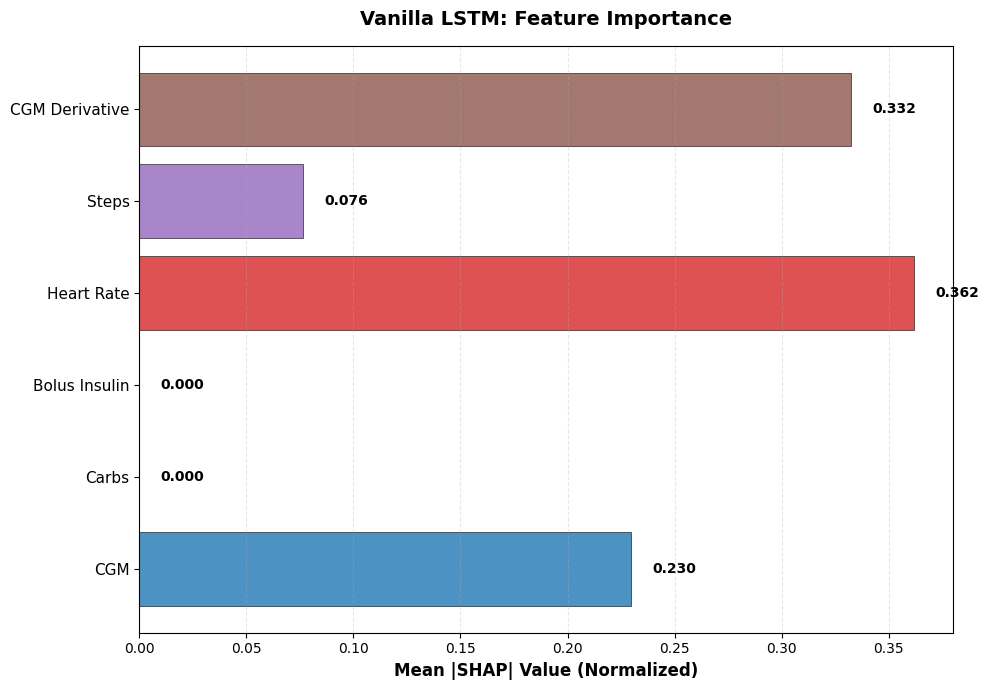

✓ Saved: shap_vanilla_lstm_importance.png


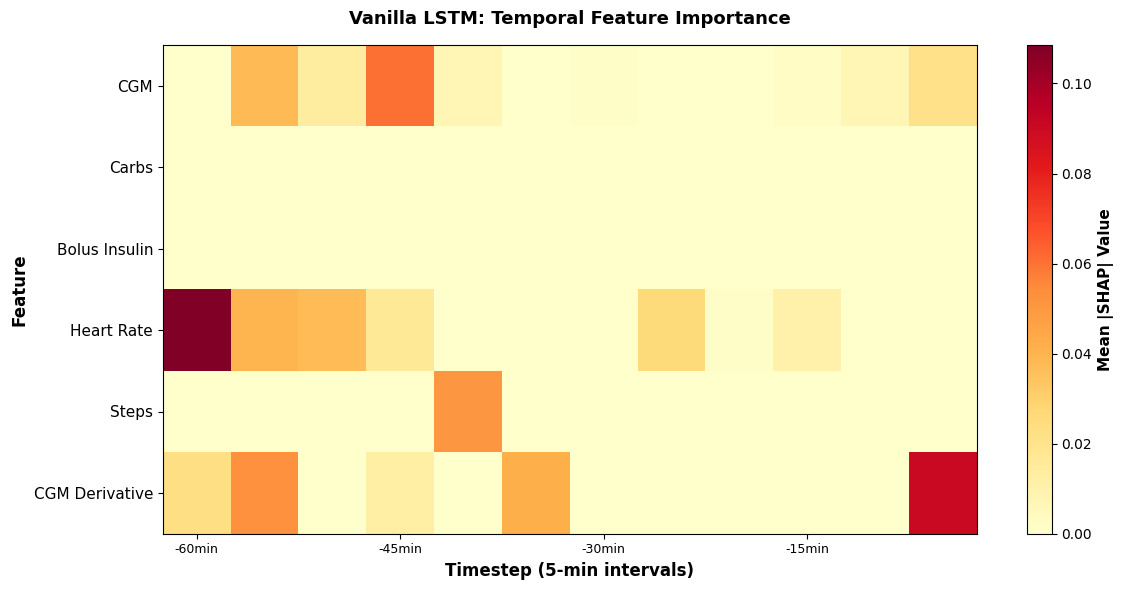

✓ Saved: shap_vanilla_lstm_temporal.png


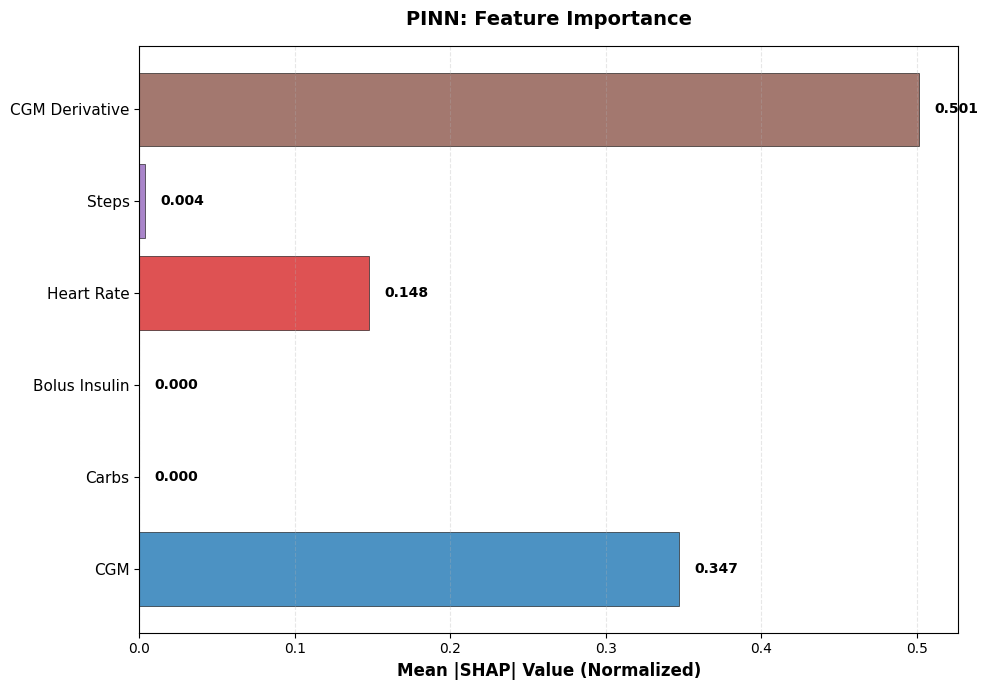

✓ Saved: shap_pinn_importance.png


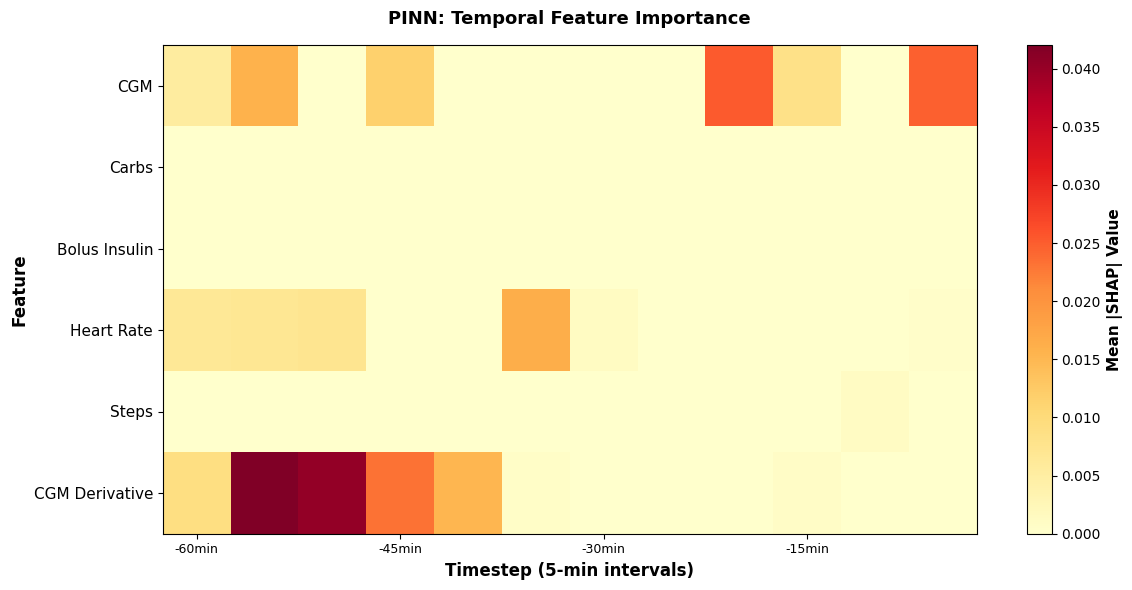

✓ Saved: shap_pinn_temporal.png


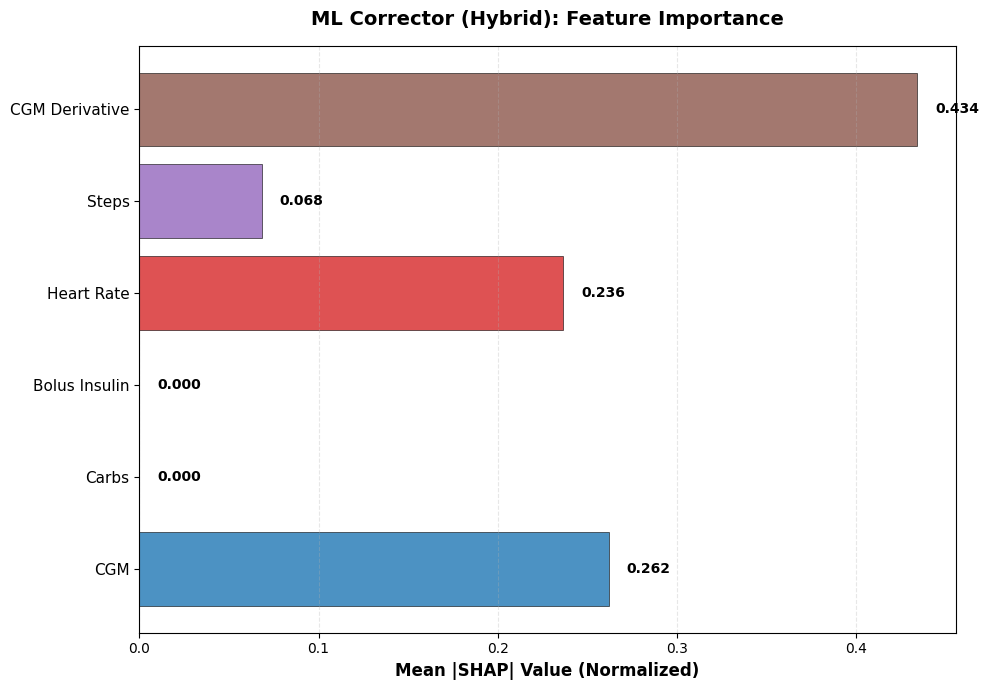

✓ Saved: shap_ml_corrector_hybrid_importance.png


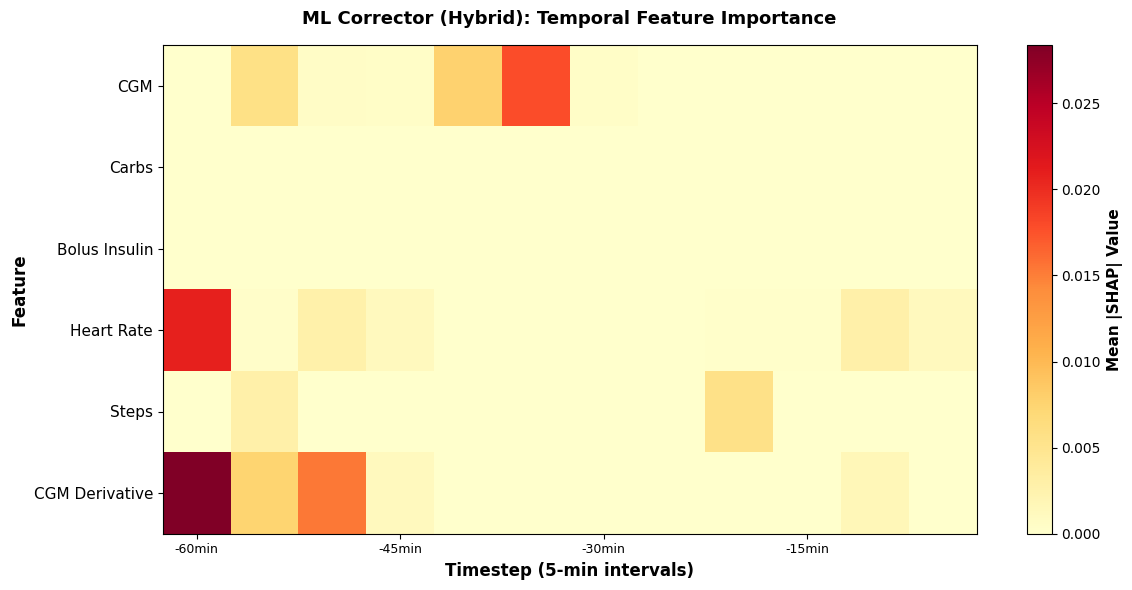

✓ Saved: shap_ml_corrector_hybrid_temporal.png


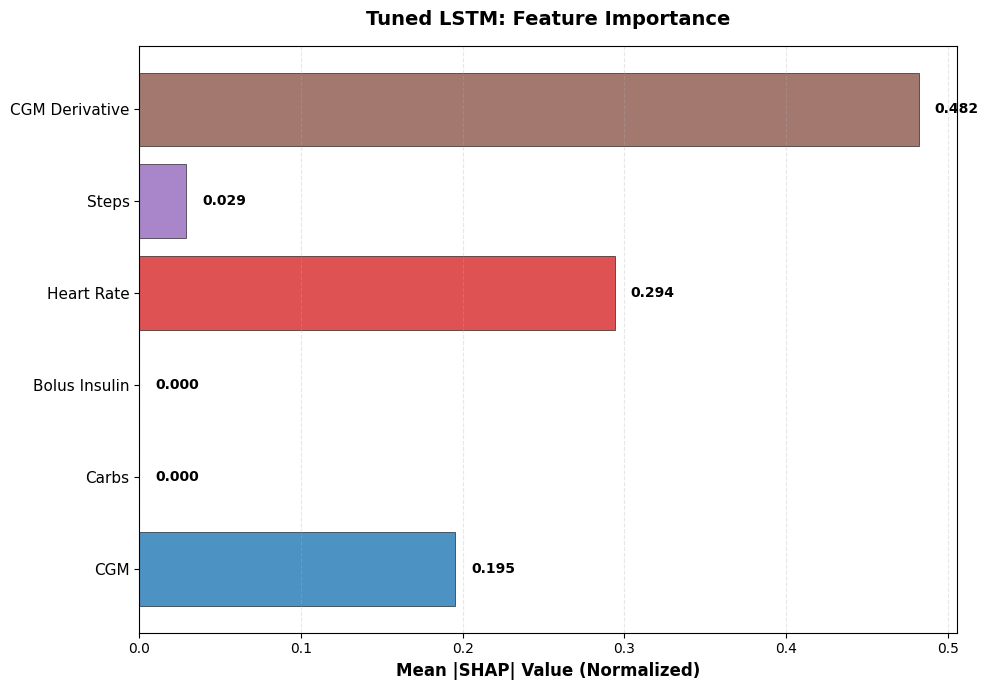

✓ Saved: shap_tuned_lstm_importance.png


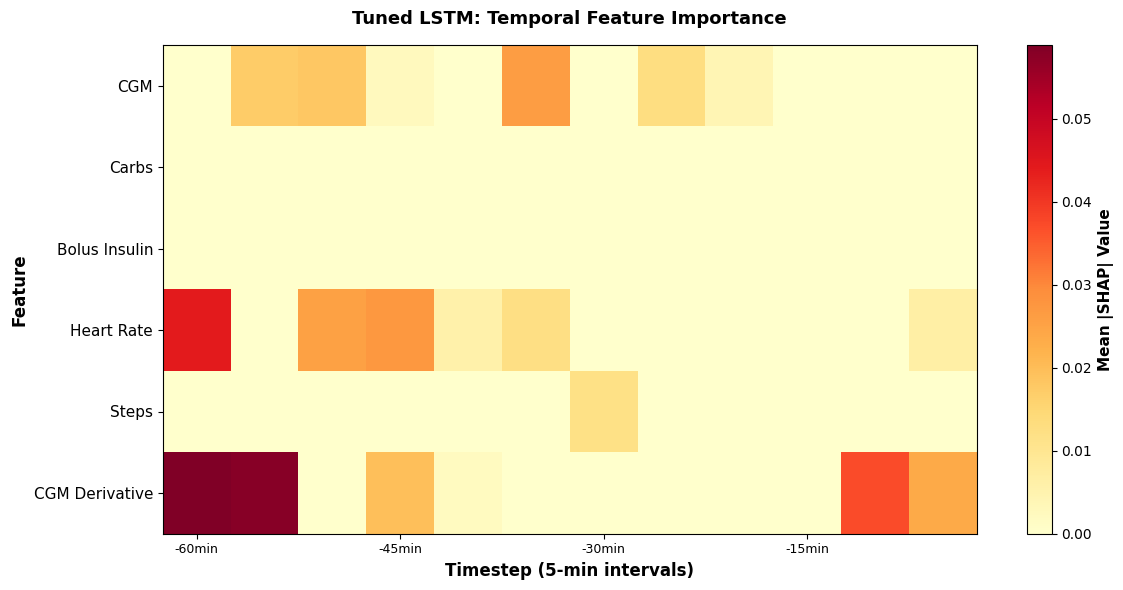

✓ Saved: shap_tuned_lstm_temporal.png


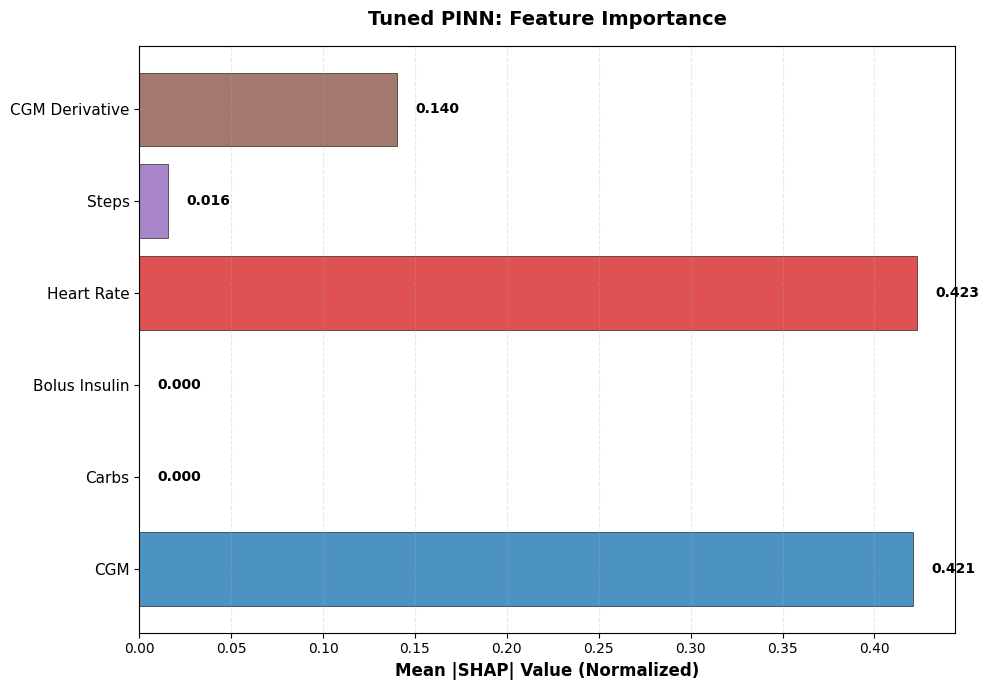

✓ Saved: shap_tuned_pinn_importance.png


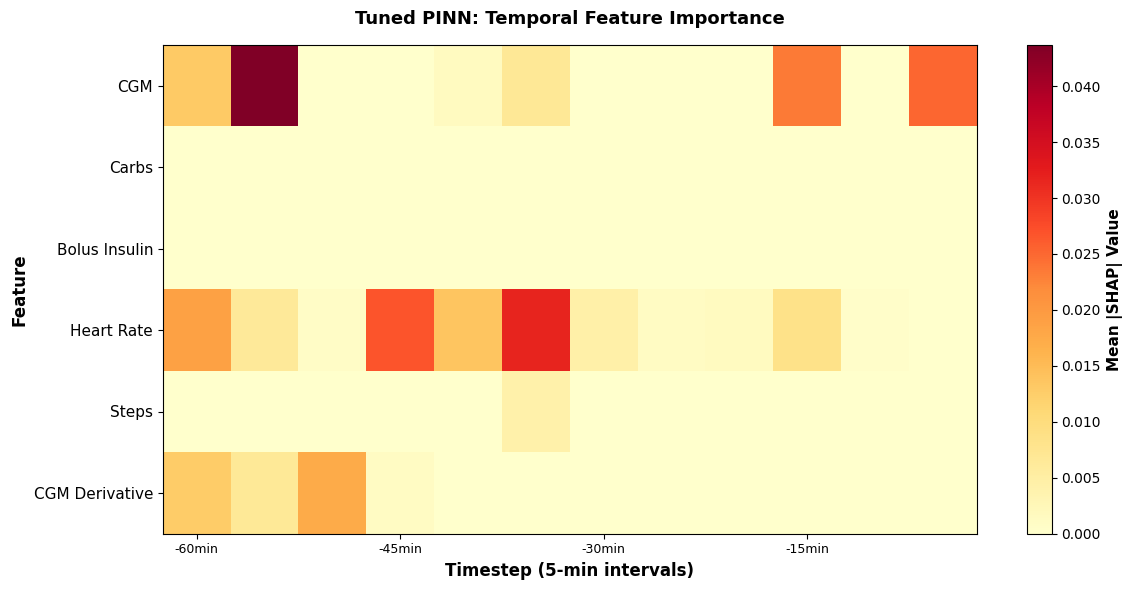

✓ Saved: shap_tuned_pinn_temporal.png


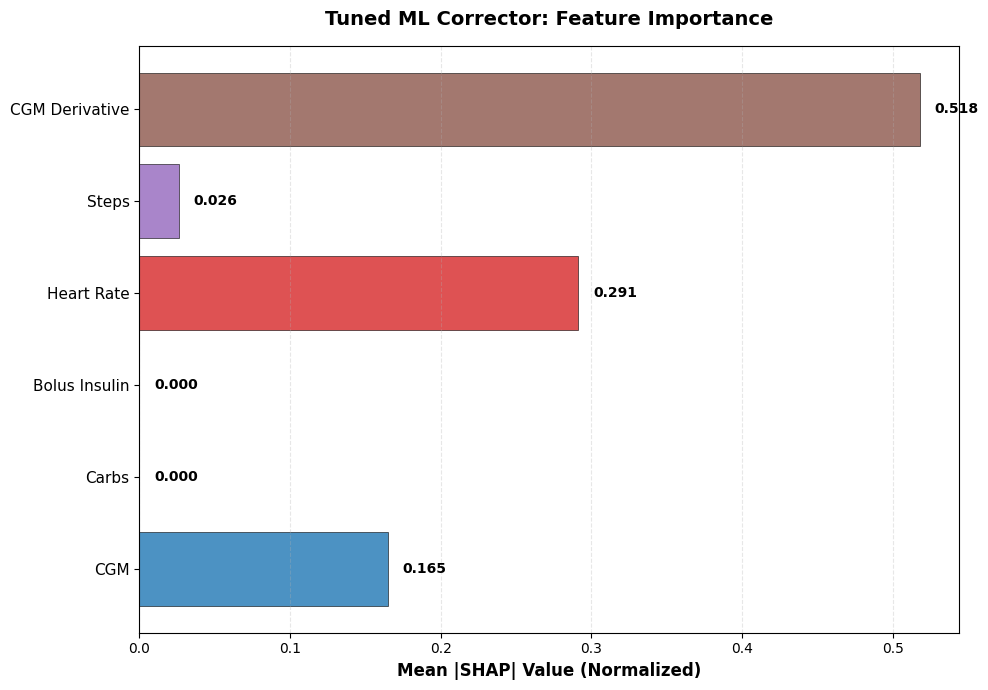

✓ Saved: shap_tuned_ml_corrector_importance.png


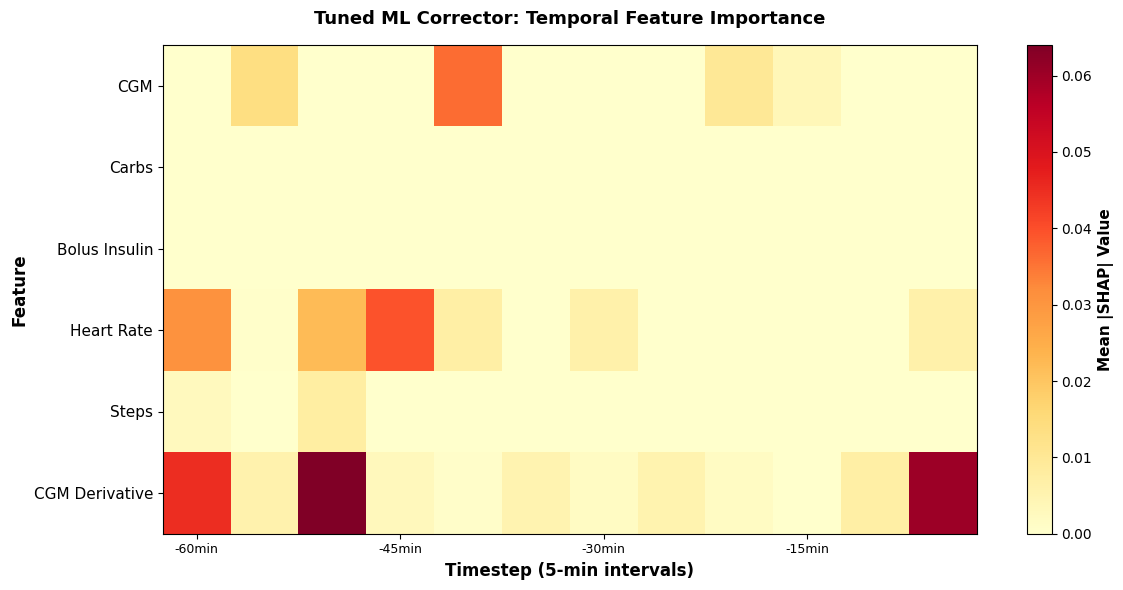

✓ Saved: shap_tuned_ml_corrector_temporal.png

FEATURE IMPORTANCE RANKINGS

Vanilla LSTM:
----------------------------------------------------------------------
  1. Heart Rate           0.3618 (36.18%)
  2. CGM Derivative       0.3323 (33.23%)
  3. CGM                  0.2295 (22.95%)
  4. Steps                0.0764 (7.64%)
  5. Bolus Insulin        0.0000 (0.00%)
  6. Carbs                0.0000 (0.00%)

PINN:
----------------------------------------------------------------------
  1. CGM Derivative       0.5015 (50.15%)
  2. CGM                  0.3469 (34.69%)
  3. Heart Rate           0.1478 (14.78%)
  4. Steps                0.0038 (0.38%)
  5. Bolus Insulin        0.0000 (0.00%)
  6. Carbs                0.0000 (0.00%)

ML Corrector (Hybrid):
----------------------------------------------------------------------
  1. CGM Derivative       0.4337 (43.37%)
  2. CGM                  0.2617 (26.17%)
  3. Heart Rate           0.2363 (23.63%)
  4. Steps                0.0682 (6.82%)
 

In [28]:
"""
Modified SHAP Analysis - Works with bergman_params instead of bergman object
Skips standalone Bergman model (physiological baseline)
Analyzes ML Corrector models using bergman_params for simulation
"""

import numpy as np
import matplotlib.pyplot as plt
import shap
import tensorflow as tf

# ============================================================================
# CONFIGURATION
# ============================================================================

feature_names = [
    'CGM', 'Carbs', 'Bolus Insulin', 'Heart Rate', 'Steps',
    'CGM Derivative']

BACKGROUND_SIZE = 3
EXPLAIN_SIZE = 5
NSAMPLES = 10

print("="*70)
print("SHAP ANALYSIS - MODIFIED FOR BERGMAN_PARAMS")
print("="*70)

# ============================================================================
# STEP 1: CHECK AVAILABILITY
# ============================================================================

print("\n" + "="*70)
print("STEP 1: CHECKING AVAILABILITY")
print("="*70)

# Check models
available_models = {}
missing = []

# Check LSTM
if 'lstm_model' in globals():
    available_models['lstm'] = True
    print("✓ lstm_model found")
else:
    missing.append('lstm_model')
    print("✗ lstm_model NOT FOUND")

# Check PINN
if 'best_model' in globals():
    available_models['pinn'] = True
    print("✓ best_model (PINN) found")
else:
    missing.append('best_model')
    print("✗ best_model (PINN) NOT FOUND")

# Check ML Corrector - now checks for bergman_params instead of bergman
if 'lstm_corrector' in globals():
    if 'bergman_params' in globals():
        available_models['ml_corrector'] = True
        print("✓ lstm_corrector found")
        print("✓ bergman_params found (will simulate inline)")
    else:
        missing.append('bergman_params')
        print("✓ lstm_corrector found")
        print("✗ bergman_params NOT FOUND (needed for ML Corrector)")
else:
    missing.append('lstm_corrector')
    print("✗ lstm_corrector NOT FOUND")

# Check tuned models
if 'tuned_lstm_model' in globals():
    available_models['tuned_lstm'] = True
    print("✓ tuned_lstm_model found")
else:
    missing.append('tuned_lstm_model')
    print("✗ tuned_lstm_model NOT FOUND")

if 'tuned_pinn_model' in globals():
    available_models['tuned_pinn'] = True
    print("✓ tuned_pinn_model found")
else:
    missing.append('tuned_pinn_model')
    print("✗ tuned_pinn_model NOT FOUND")

if 'tuned_hybrid_corrector_model' in globals():
    if 'bergman_params' in globals():
        available_models['tuned_ml_corrector'] = True
        print("✓ tuned_hybrid_corrector_model found")
        print("✓ bergman_params found (will simulate inline)")
    else:
        missing.append('bergman_params for tuned')
        print("✓ tuned_hybrid_corrector_model found")
        print("✗ bergman_params NOT FOUND (needed for Tuned ML Corrector)")
else:
    missing.append('tuned_hybrid_corrector_model')
    print("✗ tuned_hybrid_corrector_model NOT FOUND")

# Check required data
print("\nChecking data variables:")
required_data = ['X_train', 'X_val', 'cgm_scaler', 'N_OUT', 'N_IN']
for var in required_data:
    if var in globals():
        print(f"✓ {var} found")
    else:
        missing.append(var)
        print(f"✗ {var} NOT FOUND")

models_to_analyze = list(available_models.keys())

print(f"\n{'='*70}")
if models_to_analyze:
    print(f"✓ Will analyze {len(models_to_analyze)} model(s): {', '.join(models_to_analyze)}")
else:
    print("✗ NO MODELS AVAILABLE!")
    print("\nMissing variables:")
    for m in missing:
        print(f"  - {m}")
    raise RuntimeError("No models available for SHAP analysis!")

if missing:
    print(f"\nNote: {len(missing)} variable(s) missing (those models will be skipped)")

# ============================================================================
# STEP 2: PREPARE DATA
# ============================================================================

print(f"\n{'='*70}")
print("STEP 2: PREPARING DATA")
print("="*70)

background_indices = np.random.choice(X_train.shape[0], BACKGROUND_SIZE, replace=False)
background_data = X_train[background_indices]

explain_indices = np.random.choice(X_val.shape[0], EXPLAIN_SIZE, replace=False)
explain_data = X_val[explain_indices]

n_timesteps = explain_data.shape[1]
n_features = explain_data.shape[2]

print(f"Background data shape: {background_data.shape}")
print(f"Explain data shape: {explain_data.shape}")
print(f"Timesteps: {n_timesteps}, Features: {n_features}")

# ============================================================================
# STEP 3: CREATE SAFE COPIES
# ============================================================================

print(f"\n{'='*70}")
print("STEP 3: CREATING SAFE COPIES")
print("="*70)

safe_models = {}

def safe_clone(model, name):
    """Clone a Keras model safely"""
    try:
        cloned = tf.keras.models.clone_model(model)
        cloned.set_weights(model.get_weights())
        print(f"✓ {name} cloned successfully")
        return cloned
    except Exception as e:
        print(f"⚠ {name} could not be cloned (using original): {str(e)[:50]}")
        return model

# Clone available models
if 'lstm' in models_to_analyze:
    safe_models['lstm'] = safe_clone(lstm_model, "LSTM")

if 'pinn' in models_to_analyze:
    safe_models['pinn'] = safe_clone(best_model, "PINN")

if 'ml_corrector' in models_to_analyze:
    # For ML Corrector, clone the LSTM part and store bergman_params
    safe_models['ml_corrector'] = {
        'corrector': safe_clone(lstm_corrector, "ML Corrector (LSTM)"),
        'bergman_params': bergman_params  # Store parameters, not object
    }
    print(f"✓ ML Corrector prepared (will use bergman_params for simulation)")

if 'tuned_lstm' in models_to_analyze:
    safe_models['tuned_lstm'] = safe_clone(tuned_lstm_model, "Tuned LSTM")

if 'tuned_pinn' in models_to_analyze:
    safe_models['tuned_pinn'] = safe_clone(tuned_pinn_model, "Tuned PINN")

if 'tuned_ml_corrector' in models_to_analyze:
    safe_models['tuned_ml_corrector'] = {
        'corrector': safe_clone(tuned_hybrid_corrector_model, "Tuned ML Corrector (LSTM)"),
        'bergman_params': bergman_params
    }
    print(f"✓ Tuned ML Corrector prepared (will use bergman_params for simulation)")

# ============================================================================
# PREDICTION FUNCTIONS
# ============================================================================

def create_lstm_predict_fn(model):
    """LSTM prediction function"""
    def predict_fn(X):
        if len(X.shape) == 2:
            n_samples = X.shape[0]
            X = X.reshape(n_samples, n_timesteps, n_features)
        preds = model.predict(X, verbose=0, batch_size=32)
        return np.mean(preds, axis=1, keepdims=True)
    return predict_fn


def create_pinn_predict_fn(pinn_model):
    """PINN prediction function"""
    def predict_fn(X):
        if len(X.shape) == 2:
            n_samples = X.shape[0]
            X = X.reshape(n_samples, n_timesteps, n_features)
        
        X_tf = X.astype(np.float32)
        preds_scaled, _ = pinn_model(X_tf, training=False) 
        preds_scaled = preds_scaled.numpy()
        return np.mean(preds_scaled, axis=1, keepdims=True)
    
    return predict_fn


def create_ml_corrector_predict_fn(lstm_corrector, params):
    """
    ML Corrector prediction using bergman_params (not bergman object)
    
    This implements Bergman simulation inline, matching your evaluation code
    """
    p1, p2, p3, k_i, Gb = params
    dt_scale = 1.0  # 5min/5min
    
    def predict_fn(X):
        if len(X.shape) == 2:
            n_samples = X.shape[0]
            X = X.reshape(n_samples, n_timesteps, n_features)
        
        predictions = []
        
        for i in range(X.shape[0]):
            x_input = X[i:i+1]
            
            # Get LSTM residual correction
            residual_pred = lstm_corrector.predict(x_input, verbose=0)[0]
            
            # Simulate Bergman model inline (like evaluation code does)
            # Extract features: CGM is feature 0, Carbs is 1, Bolus is 2
            cgm_last = x_input[0, -1, 0]  # Last CGM value (scaled)
            
            # Convert to mg/dL
            cgm_last_mg = cgm_scaler.inverse_transform([[cgm_last]])[0, 0]
            
            # Extract future insulin and carbs (simplified - use last values)
            bolus_future = np.full(N_OUT, x_input[0, -1, 2])
            carbs_future = np.full(N_OUT, x_input[0, -1, 1])
            
            # Approximate scaling back to original units
            # Note: This is simplified - in real scenario you'd have proper scalers
            bolus_mg = bolus_future * 20  # Approximate
            carbs_mg = carbs_future * 100  # Approximate
            
            # Bergman simulation (matching evaluation code logic)
            G = cgm_last_mg
            I = 0.0
            berg_pred_mg = np.zeros(N_OUT)
            
            for t in range(N_OUT):
                # Update insulin
                I = I * np.exp(-k_i) + bolus_mg[t]
                
                # Meal effect
                meal_effect = p3 * carbs_mg[t]
                
                # Glucose dynamics
                dG = -p1 * (G - Gb) - p2 * I + meal_effect
                G = G + dG * dt_scale
                berg_pred_mg[t] = G
            
            # Scale Bergman predictions
            berg_pred_scaled = cgm_scaler.transform(berg_pred_mg.reshape(-1, 1)).flatten()
            
            # Combine with residual correction
            y_hybrid = berg_pred_scaled + residual_pred
            predictions.append(np.mean(y_hybrid))
        
        return np.array(predictions).reshape(-1, 1)
    
    return predict_fn


# ============================================================================
# SHAP ANALYSIS FUNCTION
# ============================================================================

def compute_shap_analysis(predict_fn, model_name):
    """Compute SHAP analysis"""
    print(f"\n{'='*70}")
    print(f"Analyzing {model_name}")
    print(f"{'='*70}")
    
    background_flat = background_data.reshape(BACKGROUND_SIZE, -1)
    explain_flat = explain_data.reshape(EXPLAIN_SIZE, -1)
    
    print("Initializing KernelExplainer...")
    explainer = shap.KernelExplainer(predict_fn, background_flat)
    
    print("Computing SHAP values...")
    shap_values_flat = explainer.shap_values(explain_flat, nsamples=NSAMPLES, silent=False)
    
    if isinstance(shap_values_flat, list):
        shap_values_flat = shap_values_flat[0]
        
    shap_values = shap_values_flat.reshape(EXPLAIN_SIZE, n_timesteps, n_features)
    print(f"SHAP values shape: {shap_values.shape}")
    
    # Aggregate
    mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 1))
    mean_abs_shap_norm = mean_abs_shap / np.sum(mean_abs_shap)
    
    # Temporal
    temporal_importance = np.mean(np.abs(shap_values), axis=0)
    
    # Time windows
    segment_size = n_timesteps // 3
    recent_importance = np.mean(temporal_importance[-segment_size:], axis=0)
    middle_importance = np.mean(temporal_importance[segment_size:-segment_size], axis=0)
    distant_importance = np.mean(temporal_importance[:segment_size], axis=0)
    
    recent_norm = recent_importance / np.sum(recent_importance)
    middle_norm = middle_importance / np.sum(middle_importance)
    distant_norm = distant_importance / np.sum(distant_importance)
    
    print(f"✓ SHAP analysis complete for {model_name}")
    
    return {
        'shap_values': shap_values,
        'mean_abs_shap': mean_abs_shap_norm,
        'temporal_importance': temporal_importance,
        'temporal_windows': {
            'distant': distant_norm,
            'middle': middle_norm,
            'recent': recent_norm
        }
    }

# ============================================================================
# RUN SHAP ANALYSIS
# ============================================================================

model_display_names = {
    'lstm': 'Vanilla LSTM',
    'pinn': 'PINN',
    'ml_corrector': 'ML Corrector (Hybrid)',
    'tuned_lstm': 'Tuned LSTM',
    'tuned_pinn': 'Tuned PINN',
    'tuned_ml_corrector': 'Tuned ML Corrector'
}

results = {}

for model_name in models_to_analyze:
    display_name = model_display_names.get(model_name, model_name.upper())
    
    try:
        # Create prediction function based on model type
        if model_name in ['lstm', 'tuned_lstm']:
            predict_fn = create_lstm_predict_fn(safe_models[model_name])
        
        elif model_name in ['pinn', 'tuned_pinn']:
            predict_fn = create_pinn_predict_fn(safe_models[model_name])
        
        elif model_name in ['ml_corrector', 'tuned_ml_corrector']:
            # Use bergman_params instead of bergman object
            model_components = safe_models[model_name]
            predict_fn = create_ml_corrector_predict_fn(
                model_components['corrector'],
                model_components['bergman_params']
            )
        
        else:
            print(f"⚠ Unknown model type: {model_name}, skipping...")
            continue
        
        # Run SHAP analysis
        results[display_name] = compute_shap_analysis(predict_fn, display_name)
        
    except Exception as e:
        print(f"✗ Error analyzing {model_name}: {e}")
        import traceback
        traceback.print_exc()

# ============================================================================
# VISUALIZATIONS
# ============================================================================

if len(results) == 0:
    print("\n✗ No successful SHAP analyses!")
    raise RuntimeError("SHAP analysis failed for all models")

print(f"\n{'='*70}")
print(f"✓ SUCCESSFULLY ANALYZED {len(results)} MODEL(S)")
print(f"{'='*70}")

# 1. Comparison across models
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
y_pos = np.arange(len(feature_names))

for idx, (model_name, data) in enumerate(results.items()):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    bars = ax.barh(y_pos, data['mean_abs_shap'], color=colors, 
                   alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.set_xlabel('Importance Score', fontsize=10, fontweight='bold')
    ax.set_title(f'{model_name}\nFeature Importance', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
               f'{data["mean_abs_shap"][i]:.3f}',
               ha='left', va='center', fontsize=8)

for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Importance Comparison Across Models', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('shap_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_all_models_comparison.png")

# 2. Individual model plots
for model_name, data in results.items():
    # Bar plot
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(y_pos, data['mean_abs_shap'], color=colors, 
                   alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=11)
    ax.set_xlabel('Mean |SHAP| Value (Normalized)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name}: Feature Importance', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
               f'{data["mean_abs_shap"][i]:.3f}',
               ha='left', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    filename = f'shap_{model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}_importance.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {filename}")
    
    # Temporal heatmap
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(data['temporal_importance'].T, aspect='auto', 
                   cmap='YlOrRd', interpolation='nearest')
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=11)
    ax.set_xlabel('Timestep (5-min intervals)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name}: Temporal Feature Importance', 
                 fontsize=13, fontweight='bold', pad=15)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean |SHAP| Value', fontsize=11, fontweight='bold')
    
    tick_positions = range(0, n_timesteps, 3)
    tick_labels = [f'-{(n_timesteps-i)*5}min' for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=9)
    
    plt.tight_layout()
    filename = f'shap_{model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}_temporal.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {filename}")

# 3. Feature rankings
print(f"\n{'='*70}")
print("FEATURE IMPORTANCE RANKINGS")
print(f"{'='*70}")

for model_name, data in results.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    
    indices = np.argsort(data['mean_abs_shap'])[::-1]
    for rank, idx in enumerate(indices, 1):
        print(f"  {rank}. {feature_names[idx]:20s} {data['mean_abs_shap'][idx]:.4f} "
              f"({data['mean_abs_shap'][idx]*100:.2f}%)")

print(f"\n{'='*70}")
print("SHAP ANALYSIS COMPLETE!")
print(f"{'='*70}")
print(f"""
✓ Analyzed {len(results)} models
✓ Excluded: Persistence (baseline), Bergman (physics-only)
✓ ML Corrector models analyzed using bergman_params (inline simulation)

Generated visualizations:
  - shap_all_models_comparison.png
  - shap_[model]_importance.png (individual plots)
  - shap_[model]_temporal.png (temporal heatmaps)

Key: This version works with bergman_params instead of bergman object,
     matching your evaluation code implementation.
""")